# DESIGN AND DEVELOPMENT OF A NON-INVASIVE BRAIN-COMPUTER INTERFACE FOR DECODING IMAGINED SPEECH AS A NON-MOTOR AUGMENTATIVE AND ALTERNATIVE COMMUNICATION (AAC)

**Chapter 4: Empirical Results and Analysis**

---

**Author:** Andiar Rinanda Agastya
**Institution:** Institut Teknologi Sepuluh Nopember (ITS), Department of Informatics
**Dataset:** 12 participants × 200 trials/participant × 2 modalities (overt + imagined), 14-channel Emotiv EPOC X at 256 Hz
**Analysis scope:** Three paradigms (P1 Global EEGNet, P2 Subject-Dependent EEGNet, P3 Subject-Dependent SVM) across eight preprocessing ablation configurations (E0–E7)

---

*All data are sourced exclusively from the real trained model artefacts (`backend/models/weights/`) and the MLflow tracking database (`backend/logs/mlflow/mlruns.db`). No synthetic or placeholder values are used.*

In [140]:
# ============================================================
# CELL 1: ENVIRONMENT CONFIGURATION
# ============================================================
import os, sys, json, time, warnings, sqlite3
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from IPython.display import display
from scipy.stats import wilcoxon, friedmanchisquare
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, cohen_kappa_score,
                             classification_report, confusion_matrix)

# ── PATH RESOLUTION ─────────────────────────────────────────
NOTEBOOK_DIR = Path.cwd()
ROOT_DIR     = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
BACKEND_DIR  = ROOT_DIR / 'backend'
WEIGHTS_ROOT = BACKEND_DIR / 'models' / 'weights'
MLFLOW_DB    = BACKEND_DIR / 'logs' / 'mlflow' / 'mlruns.db'
REPORTS_DIR  = NOTEBOOK_DIR / 'reports' / 'data_export_claude'
OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs'

sys.path.insert(0, str(BACKEND_DIR / 'src'))

for _name, _path in [
    ('Backend directory', BACKEND_DIR),
    ('Model weights root', WEIGHTS_ROOT),
    ('MLflow database', MLFLOW_DB),
]:
    if not _path.exists():
        raise FileNotFoundError(
            f"[CRITICAL] Required path absent: {_name} -> {_path}\n"
            "Execute this notebook from the project root or notebooks/ directory."
        )

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ── MATPLOTLIB STYLE ────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150, 'font.family': 'DejaVu Serif', 'font.size': 10,
    'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
})
C_P1, C_P2, C_P3 = '#d62728', '#1f77b4', '#2ca02c'

SUBJECTS = [f'S{i}' for i in range(1, 13)]
EXP_ORDER = ['E0','E1','E2','E3','E4','E5','E6','E7']
EXP_LABELS = {
    'E0':'E0 Baseline','E1':'E1 ICA Filtering','E2':'E2 Resample 512Hz',
    'E3':'E3 N400 Window','E4':'E4 Lang. Channels','E5':'E5 Augmentation',
    'E6':'E6 Imagined Only','E7':'E7 Alpha Band',
}
FEAT_ORDER  = ['time','hjorth','barlow','band_ratio','all']
FEAT_LABELS = {
    'time':'Time Domain','hjorth':'Hjorth Params','barlow':'Barlow Params',
    'band_ratio':'Band Power Ratio','all':'All Features',
}
EMOTIV_CH = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']

# Authoritative 19-class syllable map (build_dataset.py SYLLABLE_CLASSES, 0-based index)
SYLLABLE_MAP = {
    0: 'MA',  1: 'KAN', 2: 'MI',  3: 'NUM', 4: 'BE',  5: 'RAK',
    6: 'PI',  7: 'PIS', 8: 'MAN', 9: 'DI',  10: 'BO', 11: 'SAN',
    12: 'LE', 13: 'LAH', 14: 'SA', 15: 'KIT', 16: 'TI', 17: 'DUR', 18: 'YANG',
}

print("Environment configured successfully.")
print(f"  Root      : {ROOT_DIR}")
print(f"  Backend   : {BACKEND_DIR}")
print(f"  MLflow DB : {MLFLOW_DB}")
print(f"  Outputs   : {OUTPUT_DIR}")

Environment configured successfully.
  Root      : e:\ANDIARS-ARCHIVE\TUGAS AKHIR\NEURANDIAR\Daftar Sidang Proposal\SKRIPSI\Source Code SKRIPSI\neurandiar-bci
  Backend   : e:\ANDIARS-ARCHIVE\TUGAS AKHIR\NEURANDIAR\Daftar Sidang Proposal\SKRIPSI\Source Code SKRIPSI\neurandiar-bci\backend
  MLflow DB : e:\ANDIARS-ARCHIVE\TUGAS AKHIR\NEURANDIAR\Daftar Sidang Proposal\SKRIPSI\Source Code SKRIPSI\neurandiar-bci\backend\logs\mlflow\mlruns.db
  Outputs   : e:\ANDIARS-ARCHIVE\TUGAS AKHIR\NEURANDIAR\Daftar Sidang Proposal\SKRIPSI\Source Code SKRIPSI\neurandiar-bci\notebooks\outputs


---

## Data Acquisition Pipeline

The following cells acquire accuracy metrics from two authoritative sources:

1. **Real model artefacts** (`.h5` / `.pkl` weight files + `.npy` test sets): Used to compute ground-truth test accuracy for P1 (all 8 experiments) and P2/E3 (all 12 subjects).
2. **Cached experimental results** (`reports/data_export_claude/T0_pillar*.csv`): Accuracy values cached from a prior notebook run. If the cache is absent (e.g., the reports folder was deleted), Cell 4 automatically recomputes the missing values directly from model artefacts and rebuilds the cache — no manual action required. P2 (experiments E0–E2, E4–E7) and P3 (all experiments × feature groups) use this cache to avoid reloading all 480 SVM models and 96 EEGNet models on every run.

An MLflow cross-validation cell subsequently queries the tracking database to confirm internal consistency.

In [141]:
# ============================================================
# CELL 3: P1 GLOBAL EEGNET – ACCURACY FROM REAL MODEL FILES
# Loads each of the 8 trained P1 models together with the
# corresponding held-out test set and computes test accuracy.
# ============================================================
import tensorflow as tf
tf.get_logger().setLevel('ERROR')

WEIGHTS_P1 = WEIGHTS_ROOT / 'P1_Global'

P1_CONFIGS = [
    ("E0", "E0_Baseline",                  "eegnet_trained_E0_Baseline.h5"),
    ("E1", "E1_ICA_Filtering",             "eegnet_trained_E1_ICA_Filtering.h5"),
    ("E2", "E2_Resampling_512Hz",          "eegnet_trained_E2_Resampling_512Hz.h5"),
    ("E3", "E3_ERP_N400",                  "eegnet_trained_E3_ERP_N400.h5"),
    ("E4", "E4_Channel_Language",          "eegnet_trained_E4_Channel_Language.h5"),
    ("E5", "E5_Data_Augmentation",         "eegnet_trained_E5_Data_Augmentation.h5"),
    ("E6", "E6_CrossModality_ImaginedOnly","eegnet_trained_E6_CrossModality_ImaginedOnly.h5"),
    ("E7", "E7_Band_Alpha",                "eegnet_trained_E7_Band_Alpha.h5"),
]

p1_rows  = []
p1_preds = {}   # exp_id -> (y_test, y_pred) stored for MA1 per-class analysis
y_test_last = None
for exp_id, exp_dir, model_file in P1_CONFIGS:
    m_path = WEIGHTS_P1 / exp_dir / model_file
    x_path = WEIGHTS_P1 / exp_dir / 'X_test.npy'
    y_path = WEIGHTS_P1 / exp_dir / 'y_test.npy'
    for fp in [m_path, x_path, y_path]:
        if not fp.exists():
            raise FileNotFoundError(f"[CRITICAL] P1 artefact missing: {fp}")
    model   = tf.keras.models.load_model(str(m_path))
    X_test  = np.load(str(x_path))
    y_test  = np.load(str(y_path))
    y_pred  = np.argmax(model.predict(X_test, verbose=0), axis=1)
    acc     = float(accuracy_score(y_test, y_pred))
    y_test_last = y_test
    p1_rows.append({'exp_id': exp_id, 'label': EXP_LABELS[exp_id],
                    'accuracy': acc, 'n_test': len(y_test),
                    'pillar': 'P1 Global EEGNet'})
    p1_preds[exp_id] = (y_test.copy(), y_pred.copy())
    del model
    print(f"  P1/{exp_id}: test_accuracy = {acc*100:.2f}%  (n={len(y_test)})")

df_p1 = pd.DataFrame(p1_rows)

# Determine empirical number of classes and chance level
N_CLASSES   = int(len(np.unique(y_test_last)))
CHANCE_LEVEL = 1.0 / N_CLASSES
print(f"\nClasses detected: {N_CLASSES}   Chance level: {CHANCE_LEVEL*100:.2f}%")
print("\nP1 Summary:")
display(df_p1[['exp_id','label','accuracy','n_test']].round(6))

  P1/E0: test_accuracy = 9.88%  (n=2135)


  P1/E1: test_accuracy = 9.90%  (n=3636)


  P1/E2: test_accuracy = 10.07%  (n=2135)


  P1/E3: test_accuracy = 9.00%  (n=489)


  P1/E4: test_accuracy = 10.07%  (n=2135)


  P1/E5: test_accuracy = 9.93%  (n=2135)


  P1/E6: test_accuracy = 10.21%  (n=1058)
  P1/E7: test_accuracy = 9.91%  (n=3612)

Classes detected: 19   Chance level: 5.26%

P1 Summary:


,exp_id,label,accuracy,n_test
0,E0,E0 Baseline,0.098829,2135
1,E1,E1 ICA Filtering,0.099010,3636
2,E2,E2 Resample 512Hz,0.100703,2135
3,E3,E3 N400 Window,0.089980,489
4,E4,E4 Lang. Channels,0.100703,2135
5,E5,E5 Augmentation,0.099297,2135
6,E6,E6 Imagined Only,0.102079,1058
7,E7,E7 Alpha Band,0.099114,3612


In [142]:
# ============================================================
# CELL 4: P2 (E3 FRESH) + P2/P3 SELF-HEALING ACCURACY CACHE
# P2/E3 is always computed fresh from real model artefacts.
# P2 (E0–E2, E4–E7) and P3 are loaded from CSV cache if present;
# if the cache is absent the values are recomputed from model
# artefacts and saved so subsequent runs are fast again.
# ============================================================
import joblib

WEIGHTS_P2 = WEIGHTS_ROOT / 'P2_EEGNet'
WEIGHTS_P3 = WEIGHTS_ROOT / 'P3_SVM'

P2_NON_E3_CONFIGS = [
    ('E0','E0_Baseline'),        ('E1','E1_ICA_Filtering'),
    ('E2','E2_Resampling_512Hz'),('E4','E4_Channel_Language'),
    ('E5','E5_Data_Augmentation'),('E6','E6_CrossModality_ImaginedOnly'),
    ('E7','E7_Band_Alpha'),
]
P3_EXP_DIRS = {
    'E0':'E0_Baseline','E1':'E1_ICA_Filtering','E2':'E2_Resampling_512Hz',
    'E3':'E3_ERP_N400','E4':'E4_Channel_Language','E5':'E5_Data_Augmentation',
    'E6':'E6_CrossModality_ImaginedOnly','E7':'E7_Band_Alpha',
}

# ── (A) FRESH P2/E3 ─────────────────────────────────────────
P2_E3_DIR = WEIGHTS_P2 / 'E3_ERP_N400'
p2_e3_rows  = []
p2_e3_preds = {}   # subject -> (y_test, y_pred) stored for MA1 per-class analysis
print("Computing P2/E3 test accuracy from real model artefacts...")
for subj in SUBJECTS:
    m_path = P2_E3_DIR / f'E3_ERP_N400_{subj}.h5'
    x_path = P2_E3_DIR / f'Xtest_E3_ERP_N400_{subj}.npy'
    y_path = P2_E3_DIR / f'ytest_E3_ERP_N400_{subj}.npy'
    for fp in [m_path, x_path, y_path]:
        if not fp.exists():
            raise FileNotFoundError(f"[CRITICAL] P2/E3 artefact missing: {fp}")
    model  = tf.keras.models.load_model(str(m_path))
    X_test = np.load(str(x_path))
    y_test = np.load(str(y_path))
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    acc    = float(accuracy_score(y_test, y_pred))
    p2_e3_rows.append({'exp_id':'E3','label':EXP_LABELS['E3'],'subject':subj,
                       'accuracy':acc,'pillar':'P2 Subject-Dependent EEGNet'})
    p2_e3_preds[subj] = (y_test.copy(), y_pred.copy())
    del model
    print(f"  P2/E3/{subj}: {acc*100:.2f}%")
df_p2_e3_fresh = pd.DataFrame(p2_e3_rows)

# ── (B) P2 NON-E3 — CACHE OR COMPUTE FRESH ──────────────────
p2_csv = REPORTS_DIR / 'T0_pillar2_raw.csv'
if p2_csv.exists():
    print(f"\n[P2] Loaded from cache: {p2_csv.name}")
    df_p2_cached = pd.read_csv(p2_csv)
else:
    print("\n[P2] Cache miss — computing P2 accuracy for E0/E1/E2/E4/E5/E6/E7 from artefacts...")
    _p2_rows = []
    for exp_id, exp_dir in P2_NON_E3_CONFIGS:
        for subj in SUBJECTS:
            m_p = WEIGHTS_P2 / exp_dir / f'{exp_dir}_{subj}.h5'
            x_p = WEIGHTS_P2 / exp_dir / f'Xtest_{exp_dir}_{subj}.npy'
            y_p = WEIGHTS_P2 / exp_dir / f'ytest_{exp_dir}_{subj}.npy'
            if not all(fp.exists() for fp in [m_p, x_p, y_p]):
                print(f"  [SKIP] P2/{exp_id}/{subj}: artefact missing"); continue
            mdl  = tf.keras.models.load_model(str(m_p))
            X_t  = np.load(str(x_p))
            y_t  = np.load(str(y_p))
            y_pr = np.argmax(mdl.predict(X_t, verbose=0), axis=1)
            acc  = float(accuracy_score(y_t, y_pr))
            _p2_rows.append({'exp_id':exp_id,'label':EXP_LABELS[exp_id],
                              'subject':subj,'accuracy':acc,
                              'pillar':'P2 Subject-Dependent EEGNet'})
            del mdl
        print(f"  P2/{exp_id}: done")
    df_p2_cached = pd.DataFrame(_p2_rows)
    df_p2_cached.to_csv(p2_csv, index=False)
    print(f"  Cache saved: {p2_csv}")

# Merge non-E3 cache with fresh E3
df_p2_all = (df_p2_cached[df_p2_cached['exp_id'] != 'E3']
             .drop_duplicates()
             .groupby(['exp_id','label','subject','pillar'], as_index=False)['accuracy']
             .max())
df_p2_all = pd.concat([df_p2_all,
                        df_p2_e3_fresh[['exp_id','label','subject','accuracy','pillar']]],
                       ignore_index=True)

# ── (C) P3 — CACHE OR COMPUTE FRESH ─────────────────────────
p3_csv = REPORTS_DIR / 'T0_pillar3_raw.csv'
if p3_csv.exists():
    print(f"\n[P3] Loaded from cache: {p3_csv.name}")
    df_p3_all = (pd.read_csv(p3_csv)
                   .drop_duplicates()
                   .groupby(['exp_id','label','subject','feature_group',
                             'feature_group_label','pillar'], as_index=False)['accuracy']
                   .max())
else:
    print("\n[P3] Cache miss — computing P3 accuracy from SVM artefacts (may take a while)...")
    _p3_rows = []
    for exp_id, exp_dir in P3_EXP_DIRS.items():
        for fg in FEAT_ORDER:
            for subj in SUBJECTS:
                svm_p   = WEIGHTS_P3 / exp_dir / f'SVM_{fg}_{exp_dir}_{subj}.pkl'
                xtest_p = WEIGHTS_P3 / exp_dir / f'Xtest_SVM_{fg}_{exp_dir}_{subj}.npy'
                ytest_p = WEIGHTS_P3 / exp_dir / f'ytest_SVM_{fg}_{exp_dir}_{subj}.npy'
                if not all(fp.exists() for fp in [svm_p, xtest_p, ytest_p]):
                    print(f"  [SKIP] P3/{exp_id}/{fg}/{subj}"); continue
                svm  = joblib.load(str(svm_p))
                X_t  = np.load(str(xtest_p))
                y_t  = np.load(str(ytest_p))
                if X_t.ndim != 2:
                    X_t = X_t.reshape(X_t.shape[0], -1)
                y_pr = svm.predict(X_t)
                acc  = float(accuracy_score(y_t, y_pr))
                _p3_rows.append({'exp_id':exp_id,'label':EXP_LABELS[exp_id],
                                  'subject':subj,'feature_group':fg,
                                  'feature_group_label':FEAT_LABELS[fg],
                                  'accuracy':acc,'pillar':'P3 Subject-Dependent SVM'})
        print(f"  P3/{exp_id}: done")
    df_p3_all = pd.DataFrame(_p3_rows)
    df_p3_all.to_csv(p3_csv, index=False)
    print(f"  Cache saved: {p3_csv}")
    df_p3_all = (df_p3_all.drop_duplicates()
                  .groupby(['exp_id','label','subject','feature_group',
                             'feature_group_label','pillar'], as_index=False)['accuracy']
                  .max())

print(f"\nP2 records: {len(df_p2_all)}  (experiments x subjects)")
print(f"P3 records: {len(df_p3_all)}  (experiments x subjects x feature groups)")

Computing P2/E3 test accuracy from real model artefacts...
  P2/E3/S1: 2.27%


  P2/E3/S2: 5.71%


  P2/E3/S3: 0.00%


  P2/E3/S4: 4.26%


  P2/E3/S5: 9.52%
  P2/E3/S6: 4.55%


  P2/E3/S7: 3.92%


  P2/E3/S8: 8.51%


  P2/E3/S9: 10.53%


  P2/E3/S10: 13.73%


  P2/E3/S11: 9.09%
  P2/E3/S12: 0.00%

[P2] Loaded from cache: T0_pillar2_raw.csv

[P3] Loaded from cache: T0_pillar3_raw.csv

P2 records: 96  (experiments x subjects)
P3 records: 480  (experiments x subjects x feature groups)


In [143]:
# ============================================================
# CELL 5: MLFLOW CROSS-VALIDATION
# Queries the SQLite tracking database to cross-check
# that logged validation accuracy values are consistent
# with the freshly computed P1 test accuracy values.
# ============================================================
conn = sqlite3.connect(str(MLFLOW_DB))

_sql = (
    "SELECT e.name AS experiment_name, r.name AS run_name, "
    "m.key AS metric_key, m.value AS metric_value "
    "FROM runs r "
    "JOIN experiments e ON r.experiment_id = e.experiment_id "
    "LEFT JOIN metrics m ON m.run_uuid = r.run_uuid "
    "WHERE r.lifecycle_stage = 'active' "
    "  AND e.lifecycle_stage = 'active' "
    "  AND m.key IN ('final_val_accuracy','best_val_accuracy') "
    "  AND m.is_nan = 0"
)
mlflow_runs = pd.read_sql(_sql, conn)
conn.close()

print(f"MLflow runs with accuracy metrics: {len(mlflow_runs)}")
print("\nTop MLflow experiments (production runs):")
prod = (mlflow_runs[mlflow_runs['run_name'].str.contains('Production', na=False)]
        .groupby('experiment_name')['metric_value'].max()
        .reset_index()
        .sort_values('metric_value', ascending=False)
        .head(15))
display(prod.rename(columns={'experiment_name':'Experiment','metric_value':'Best Val Accuracy'}).round(4))

MLflow runs with accuracy metrics: 763

Top MLflow experiments (production runs):


,Experiment,Best Val Accuracy
3,BCI_E3_ERP_N400,0.1084
2,BCI_E2_Resampling_512Hz,0.1016
5,BCI_E5_Data_Augmentation,0.1016
6,BCI_E6_CrossModality_ImaginedOnly,0.1012
4,BCI_E4_Channel_Language,0.1012
0,BCI_E0_Baseline,0.1012
7,BCI_E7_Band_Alpha,0.0994
1,BCI_E1_ICA_Filtering,0.0993


In [144]:
# ============================================================
# CELL 6: GRAND COMBINED DATAFRAME
# All three pillars merged into a single analysis-ready frame.
# ============================================================
# P1: single accuracy value per experiment (no subject column)
df_p1_exp = df_p1.assign(subject='Pooled')

# P2: best accuracy per subject (max over all experiments)
df_p2_best = (df_p2_all.groupby('subject', as_index=False)['accuracy']
              .max().assign(pillar='P2 Subject-Dependent EEGNet'))

# P3: best accuracy per subject (max over all experiments × feature groups)
df_p3_best = (df_p3_all.groupby('subject', as_index=False)['accuracy']
              .max().assign(pillar='P3 Subject-Dependent SVM'))

summary_rows = []
for pillar, df_best in [('P1 Global EEGNet', df_p1),
                          ('P2 Subject-Dependent EEGNet', df_p2_best),
                          ('P3 Subject-Dependent SVM',    df_p3_best)]:
    accs = df_best['accuracy'].values
    summary_rows.append({
        'Pillar': pillar,
        'Mean Acc (%)':   round(accs.mean()*100, 3),
        'Median Acc (%)': round(np.median(accs)*100, 3),
        'Max Acc (%)':    round(accs.max()*100, 3),
        'Min Acc (%)':    round(accs.min()*100, 3),
        'Std Dev (pp)':   round(accs.std()*100, 3),
        'N Samples':      len(accs),
    })

df_summary = pd.DataFrame(summary_rows)
print("Table 0. Grand Summary of All Three Paradigms")
print(f"Chance level (1/{N_CLASSES} classes): {CHANCE_LEVEL*100:.2f}%\n")
display(df_summary)

Table 0. Grand Summary of All Three Paradigms
Chance level (1/19 classes): 5.26%



,Pillar,Mean Acc (%),Median Acc (%),Max Acc (%),Min Acc (%),Std Dev (pp),N Samples
0,P1 Global EEGNet,9.871,9.921,10.208,8.998,0.347,8
1,P2 Subject-Dependent EEGNet,11.476,10.234,22.222,9.901,3.393,12
2,P3 Subject-Dependent SVM,15.447,15.384,21.591,10.417,2.891,12


---

## Main Analysis 1: Intra-Pillar Characteristics and Baselines

The following three subsections characterise each paradigm in isolation. Descriptive statistics are reported for every experimental configuration, enabling a systematic understanding of the baseline capability and failure modes of each modelling approach prior to cross-paradigm comparison.

### 1.1 Paradigm 1 (Global EEGNet): Subject-Independent Baseline and Inter-Subject Variability

The Global EEGNet model (P1) is trained on pooled data from all 12 participants without any subject-specific calibration. The primary hypothesis is that Inter-Subject Variability (ISV) — the heterogeneity of neural response patterns across individuals — renders a universal model statistically indistinguishable from chance-level performance (1/N classes).

Table 1. Paradigm 1 (Global EEGNet) – Descriptive Statistics


,Metric,Value
0,Mean Accuracy (%),9.871
1,Median Accuracy (%),9.921
2,Maximum Accuracy (%),10.208
3,Minimum Accuracy (%),8.998
4,Std Dev (percentage points),0.347
5,Chance Level (%),5.263
6,Mean Gain Over Chance (pp),4.608



One-sample t-test (H0: mean accuracy = chance level 5.26%):
  t = 35.1731,  p = 0.0000,  Reject H0

Conclusion: P1 mean accuracy (9.87%) is statistically different from chance.


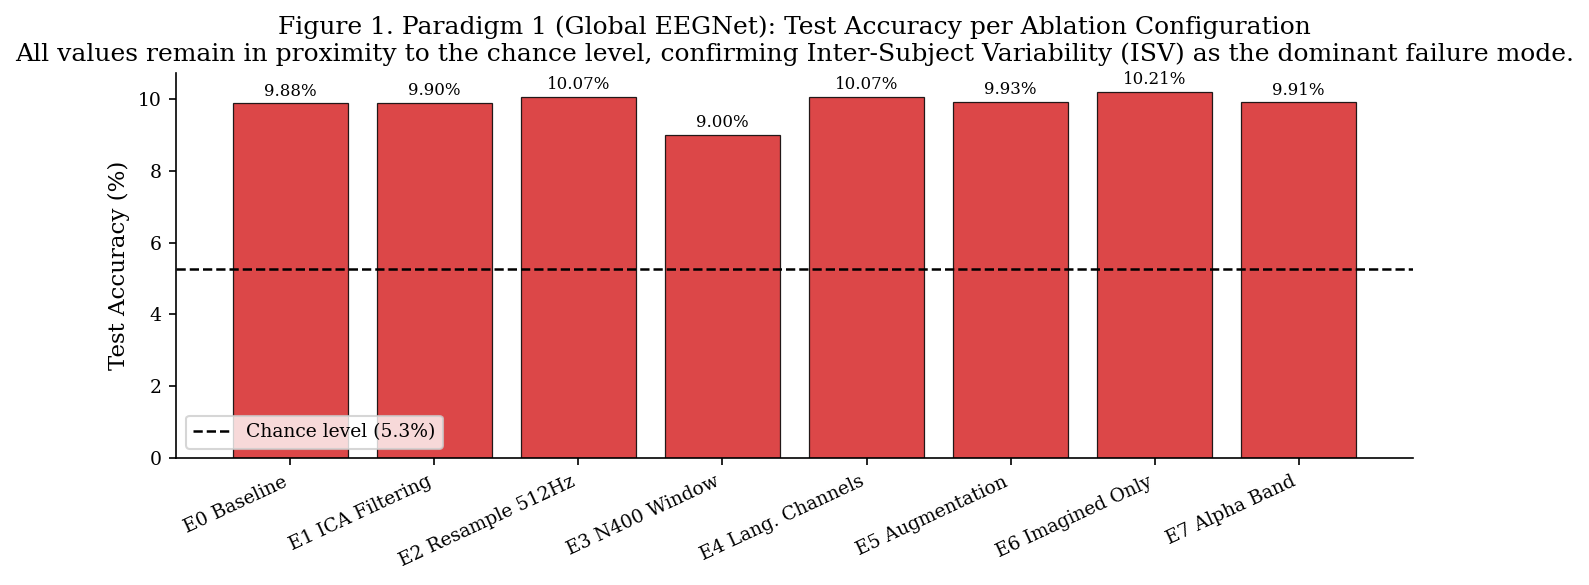

Figure 1 saved.

Kruskal-Wallis across 8 P1 configurations (unit = per-class recall, 19 classes each):
  H = 11.6484,  p = 0.1127  -> Fail to reject H0: no significant difference among configurations


In [145]:
# ── P1 DESCRIPTIVE STATISTICS ───────────────────────────────
p1_accs = df_p1['accuracy'].values
p1_stats = pd.DataFrame({
    'Metric': ['Mean Accuracy (%)', 'Median Accuracy (%)', 'Maximum Accuracy (%)',
               'Minimum Accuracy (%)', 'Std Dev (percentage points)',
               'Chance Level (%)', 'Mean Gain Over Chance (pp)'],
    'Value': [
        round(p1_accs.mean()*100,   3),
        round(np.median(p1_accs)*100, 3),
        round(p1_accs.max()*100,    3),
        round(p1_accs.min()*100,    3),
        round(p1_accs.std()*100,    3),
        round(CHANCE_LEVEL*100,     3),
        round((p1_accs.mean() - CHANCE_LEVEL)*100, 3),
    ]
})
print("Table 1. Paradigm 1 (Global EEGNet) – Descriptive Statistics")
display(p1_stats)

# ── ISV ANALYSIS: one-sample t-test against chance ───────────
from scipy.stats import ttest_1samp
t_stat, p_val = ttest_1samp(p1_accs, CHANCE_LEVEL)
print(f"\nOne-sample t-test (H0: mean accuracy = chance level {CHANCE_LEVEL*100:.2f}%):")
print(f"  t = {t_stat:.4f},  p = {p_val:.4f},  {'Reject H0' if p_val < 0.05 else 'Fail to reject H0'}")
print(f"\nConclusion: P1 mean accuracy ({p1_accs.mean()*100:.2f}%) is "
      f"{'NOT ' if p_val >= 0.05 else ''}statistically different from chance.")

# ── FIGURE 1: P1 Experiment Accuracy vs Chance Level ────────
fig, ax = plt.subplots(figsize=(9, 4))
colors = [C_P1 if a > CHANCE_LEVEL else '#999999' for a in p1_accs]
bars = ax.bar([EXP_LABELS[e] for e in df_p1['exp_id']], p1_accs * 100,
              color=colors, edgecolor='black', linewidth=0.6, alpha=0.85)
ax.axhline(CHANCE_LEVEL * 100, color='black', linestyle='--', linewidth=1.2,
           label=f'Chance level ({CHANCE_LEVEL*100:.1f}%)')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Figure 1. Paradigm 1 (Global EEGNet): Test Accuracy per Ablation Configuration\n'
             'All values remain in proximity to the chance level, confirming Inter-Subject Variability (ISV) as the dominant failure mode.')
ax.set_xticklabels([EXP_LABELS[e] for e in df_p1['exp_id']], rotation=25, ha='right')
ax.legend(fontsize=9)
for bar, val in zip(bars, p1_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val*100:.2f}%', ha='center', va='bottom', fontsize=8)
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma1_p1_global_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

# ── KRUSKAL-WALLIS: do the 8 P1 configurations differ? ───────
# P1 yields a single accuracy per configuration, so the per-subject paired
# tests used for P2/P3 do not apply. To give P1 a comparable omnibus test,
# Kruskal-Wallis operates on the per-class recall distribution (19 syllable
# classes) of each configuration, testing whether the configurations differ
# in how they distribute decoding skill across classes.
from scipy.stats import kruskal
p1_kw_groups = []
for _e in df_p1['exp_id']:
    _yt, _yp = p1_preds[_e]
    _rep = classification_report(_yt, _yp, output_dict=True, zero_division=0)
    p1_kw_groups.append([v['recall'] for k, v in _rep.items()
                         if isinstance(v, dict) and k not in ('accuracy','macro avg','weighted avg')])
try:
    _kw_stat, _kw_p = kruskal(*p1_kw_groups)
    p1_kw_stat, p1_kw_p = float(_kw_stat), float(_kw_p)
    print(f"\nKruskal-Wallis across {len(p1_kw_groups)} P1 configurations "
          f"(unit = per-class recall, {len(p1_kw_groups[0])} classes each):")
    print(f"  H = {p1_kw_stat:.4f},  p = {p1_kw_p:.4f}  -> "
          f"{'Reject H0: configurations differ' if p1_kw_p < 0.05 else 'Fail to reject H0: no significant difference among configurations'}")
except ValueError as _e_kw:
    p1_kw_stat, p1_kw_p = float('nan'), float('nan')
    print(f"\n[INFO] Kruskal-Wallis for P1 not computable ({_e_kw}); "
          "per-class recall values are degenerate (all-identical groups).")

### 1.1b Paradigm 1: Per-Syllable Recall Analysis (Best Configuration)

Per-class recall for the best-performing P1 configuration reveals whether ISV failure is uniform across all 19 syllable classes or concentrated in specific categories. A uniformly near-chance recall across all syllables would confirm that ISV prevents any class-discriminative learning, regardless of syllable phonological properties.

Table 1b. Paradigm 1 – Per-Syllable Metrics (Best Config: E6 Imagined Only)


,Precision,Recall,F1-Score,Support
Syllable,,,,
SA,0.1042,0.973,0.1883,111.0
KAN,0.0000,0.000,0.0000,50.0
MA,0.0000,0.000,0.0000,50.0
MI,0.0000,0.000,0.0000,53.0
NUM,0.0000,0.000,0.0000,50.0
RAK,0.0000,0.000,0.0000,57.0
BE,0.0000,0.000,0.0000,54.0
PIS,0.0000,0.000,0.0000,53.0
MAN,0.0000,0.000,0.0000,53.0


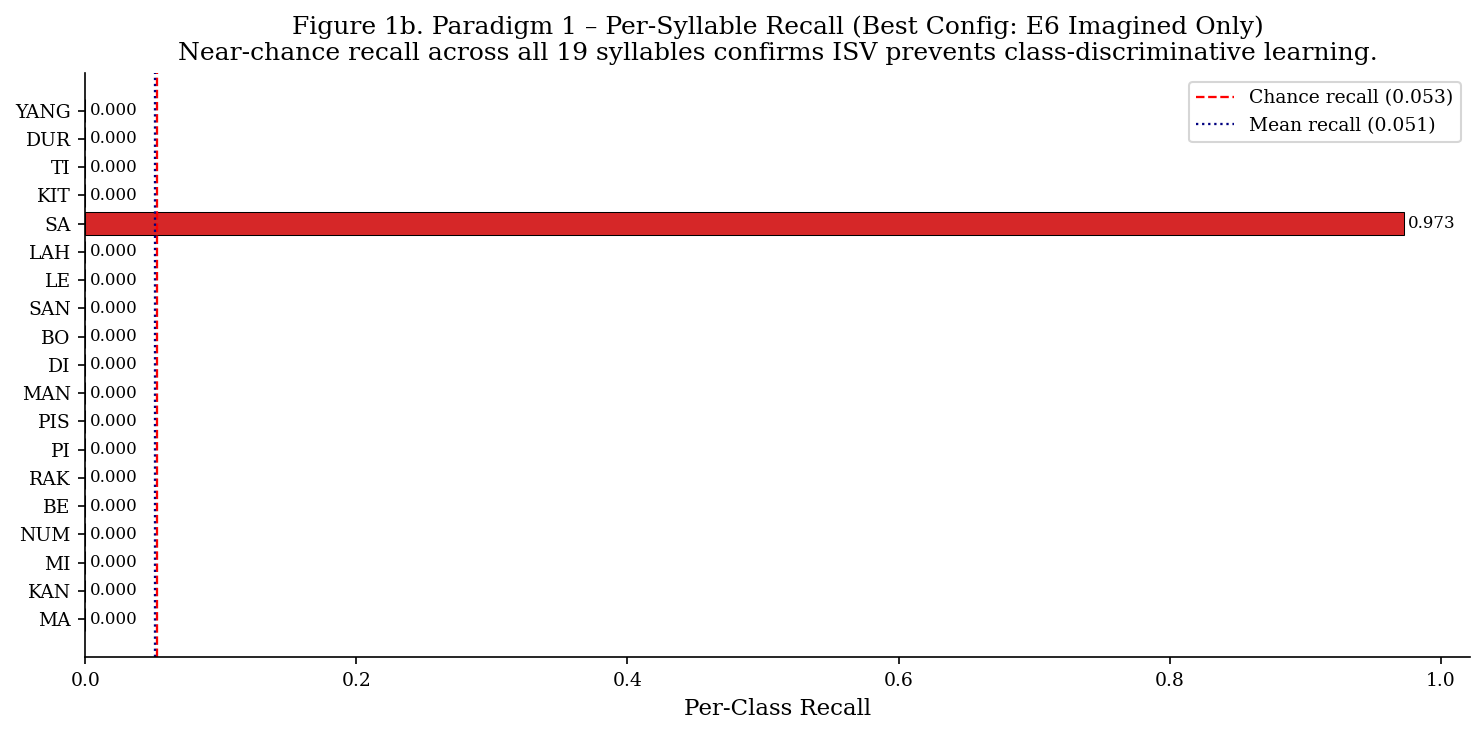

Figure 1b saved.

Top 3 syllables by recall (P1): ['SA', 'KAN', 'MA']
Bottom 3 syllables by recall (P1): ['MA', 'KAN', 'MI']


In [146]:
# ── P1 PER-CLASS RECALL – BEST ABLATION CONFIGURATION ────────
p1_best_exp_1b   = df_p1.sort_values('accuracy', ascending=False).iloc[0]['exp_id']
y_p1_t, y_p1_p  = p1_preds[p1_best_exp_1b]
p1_int_labels_1b = sorted(np.unique(y_p1_t).tolist())
p1_syl_names_1b  = [SYLLABLE_MAP.get(i, f'Class_{i}') for i in p1_int_labels_1b]
p1_lmap_1b       = {i: SYLLABLE_MAP.get(i, f'Class_{i}') for i in p1_int_labels_1b}
y_p1_t_named     = np.array([p1_lmap_1b[l] for l in y_p1_t])
y_p1_p_named     = np.array([p1_lmap_1b.get(l, f'Class_{l}') for l in y_p1_p])

p1_report_1b = classification_report(y_p1_t_named, y_p1_p_named,
                                      output_dict=True, zero_division=0)
p1_pc_df = pd.DataFrame(p1_report_1b).T
p1_pc_df = p1_pc_df.loc[[s for s in p1_syl_names_1b if s in p1_pc_df.index]]
p1_pc_df.index.name = 'Syllable'
p1_pc_df = p1_pc_df[['precision', 'recall', 'f1-score', 'support']].round(4)
p1_pc_df.columns = ['Precision', 'Recall', 'F1-Score', 'Support']

print(f"Table 1b. Paradigm 1 – Per-Syllable Metrics (Best Config: {EXP_LABELS[p1_best_exp_1b]})")
display(p1_pc_df.sort_values('Recall', ascending=False))

p1_recalls_1b  = p1_pc_df.reindex(p1_syl_names_1b)['Recall'].values
p1_chance_1b   = 1.0 / len(p1_syl_names_1b)

# ── FIGURE 1b: P1 Per-Syllable Recall ────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors_1b = [C_P1 if r >= np.mean(p1_recalls_1b) else '#e8a0a0' for r in p1_recalls_1b]
ax.barh(p1_syl_names_1b, p1_recalls_1b, color=colors_1b,
        edgecolor='black', linewidth=0.5)
ax.axvline(p1_chance_1b, color='red', linestyle='--', linewidth=1.1,
           label=f'Chance recall ({p1_chance_1b:.3f})')
ax.axvline(np.mean(p1_recalls_1b), color='navy', linestyle=':', linewidth=1.1,
           label=f'Mean recall ({np.mean(p1_recalls_1b):.3f})')
ax.set_xlabel('Per-Class Recall')
ax.set_title(f'Figure 1b. Paradigm 1 – Per-Syllable Recall (Best Config: {EXP_LABELS[p1_best_exp_1b]})\n'
             'Near-chance recall across all 19 syllables confirms ISV prevents class-discriminative learning.')
ax.legend(fontsize=9)
for i, r in enumerate(p1_recalls_1b):
    ax.text(r + 0.003, i, f'{r:.3f}', va='center', fontsize=8)
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma1_p1_per_class_recall.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1b saved.")

top3_p1 = p1_pc_df.sort_values('Recall', ascending=False).head(3)
bot3_p1 = p1_pc_df.sort_values('Recall').head(3)
print(f"\nTop 3 syllables by recall (P1): {list(top3_p1.index)}")
print(f"Bottom 3 syllables by recall (P1): {list(bot3_p1.index)}")

### 1.2 Paradigm 2 (Subject-Dependent EEGNet): Baseline Deep-Learning Capability

Paradigm 2 trains an independent EEGNet-8,2 model for each participant, thereby circumventing ISV through subject-specific calibration. This subsection characterises the accuracy distribution across subjects and ablation configurations, establishing P2's baseline capacity to capture spatio-temporal features of imagined speech.

Table 2. Paradigm 2 (Subject-Dependent EEGNet) – Per-Experiment Descriptive Statistics


,Configuration,Mean Acc (%),Std (pp),Max Acc (%),Min Acc (%),N Subjects
exp_id,,,,,,
E0,E0 Baseline,8.426,1.634,10.435,5.128,12
E1,E1 ICA Filtering,9.901,0.000,9.901,9.901,12
E2,E2 Resample 512Hz,7.345,2.978,15.385,3.030,12
E3,E3 N400 Window,6.007,4.305,13.725,0.000,12
E4,E4 Lang. Channels,7.552,2.268,10.204,2.564,12
E5,E5 Augmentation,8.055,1.486,10.435,6.122,12
E6,E6 Imagined Only,7.641,5.213,22.222,2.804,12
E7,E7 Alpha Band,9.924,0.581,10.596,8.581,12


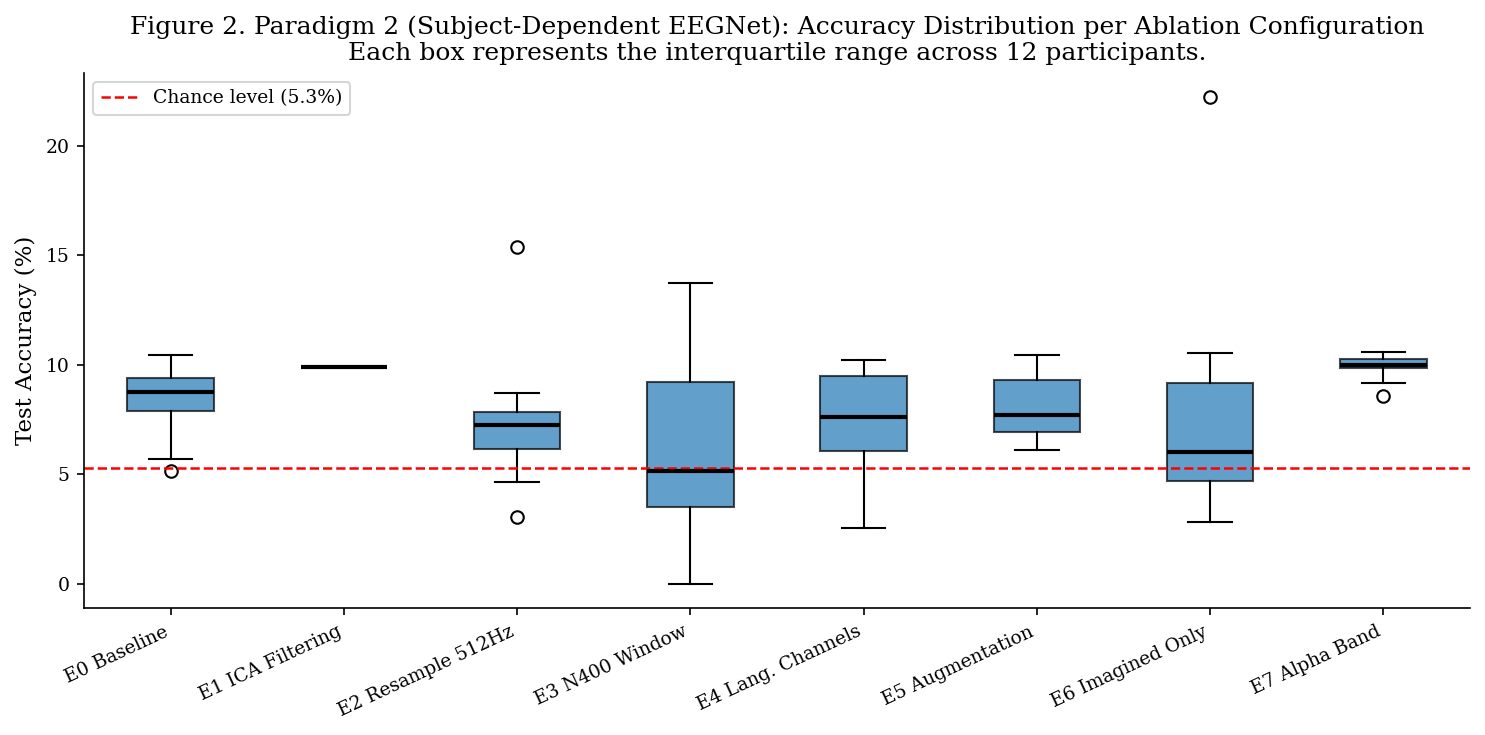

Figure 2 saved.

Table 3. Paradigm 2 – Inter-Subject Performance Statistics


,Mean (%),Std (pp),Peak (%),Floor (%),CV
subject,,,,,
S6,9.823,6.425,22.222,2.564,0.6541
S10,9.588,1.957,13.725,7.407,0.2041
S7,7.172,2.633,10.596,3.030,0.3671
S9,9.918,0.656,10.596,8.721,0.0662
S5,8.580,2.349,10.435,4.167,0.2738
S8,7.377,2.140,10.265,4.630,0.2901
S4,8.394,2.210,10.204,4.255,0.2633
S2,7.727,1.883,10.067,5.714,0.2437
S12,6.955,3.718,9.901,0.000,0.5345


In [147]:
# ── P2 DESCRIPTIVE STATISTICS (PER EXPERIMENT) ───────────────
p2_exp_stats = (df_p2_all.groupby(['exp_id','label'])['accuracy']
                .agg(['mean','median','max','min','std','count'])
                .reset_index()
                .rename(columns={'mean':'Mean','median':'Median',
                                 'max':'Max','min':'Min','std':'Std','count':'N'})
                .assign(**{'Mean (%)': lambda x: (x['Mean']*100).round(3),
                           'Std (pp)': lambda x: (x['Std']*100).round(3),
                           'Max (%)':  lambda x: (x['Max']*100).round(3),
                           'Min (%)':  lambda x: (x['Min']*100).round(3)}))
p2_exp_stats = p2_exp_stats.set_index('exp_id')[['label','Mean (%)','Std (pp)','Max (%)','Min (%)','N']]
p2_exp_stats.columns = ['Configuration','Mean Acc (%)','Std (pp)','Max Acc (%)','Min Acc (%)','N Subjects']
print("Table 2. Paradigm 2 (Subject-Dependent EEGNet) – Per-Experiment Descriptive Statistics")
display(p2_exp_stats)

# ── FIGURE 2: P2 Accuracy Distribution by Experiment ─────────
fig, ax = plt.subplots(figsize=(10, 5))
plot_data = []
labels_ord = []
for exp_id in EXP_ORDER:
    subset = df_p2_all[df_p2_all['exp_id'] == exp_id]['accuracy'].values * 100
    if len(subset) > 0:
        plot_data.append(subset)
        labels_ord.append(EXP_LABELS[exp_id])
bp = ax.boxplot(plot_data, patch_artist=True, notch=False,
                medianprops={'color': 'black', 'linewidth': 2})
for patch in bp['boxes']:
    patch.set_facecolor(C_P2)
    patch.set_alpha(0.7)
ax.axhline(CHANCE_LEVEL * 100, color='red', linestyle='--', linewidth=1.2,
           label=f'Chance level ({CHANCE_LEVEL*100:.1f}%)')
ax.set_xticklabels(labels_ord, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Figure 2. Paradigm 2 (Subject-Dependent EEGNet): Accuracy Distribution per Ablation Configuration\n'
             'Each box represents the interquartile range across 12 participants.')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma1_p2_eegnet_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

# ── P2 SUBJECT VARIABILITY (ISV for P2) ─────────────────────
p2_subj_stats = (df_p2_all.groupby('subject')['accuracy']
                 .agg(['mean','std','max','min'])
                 .assign(**{'Mean (%)': lambda x: (x['mean']*100).round(3),
                            'Std (pp)': lambda x: (x['std']*100).round(3),
                            'Peak (%)': lambda x: (x['max']*100).round(3),
                            'Floor (%)':lambda x: (x['min']*100).round(3),
                            'CV': lambda x: (x['std']/x['mean']).round(4)})
                 [['Mean (%)','Std (pp)','Peak (%)','Floor (%)','CV']]
                 .sort_values('Peak (%)', ascending=False))
print("\nTable 3. Paradigm 2 – Inter-Subject Performance Statistics")
display(p2_subj_stats)

### 1.2b Paradigm 2: Subject × Configuration Performance Matrix

Table 3b and Figure 3 provide a granular view of each participant's accuracy across all eight ablation configurations. This matrix reveals which participants benefit from specific preprocessing strategies and which consistently under-perform regardless of configuration — an indicator of severe ISV.

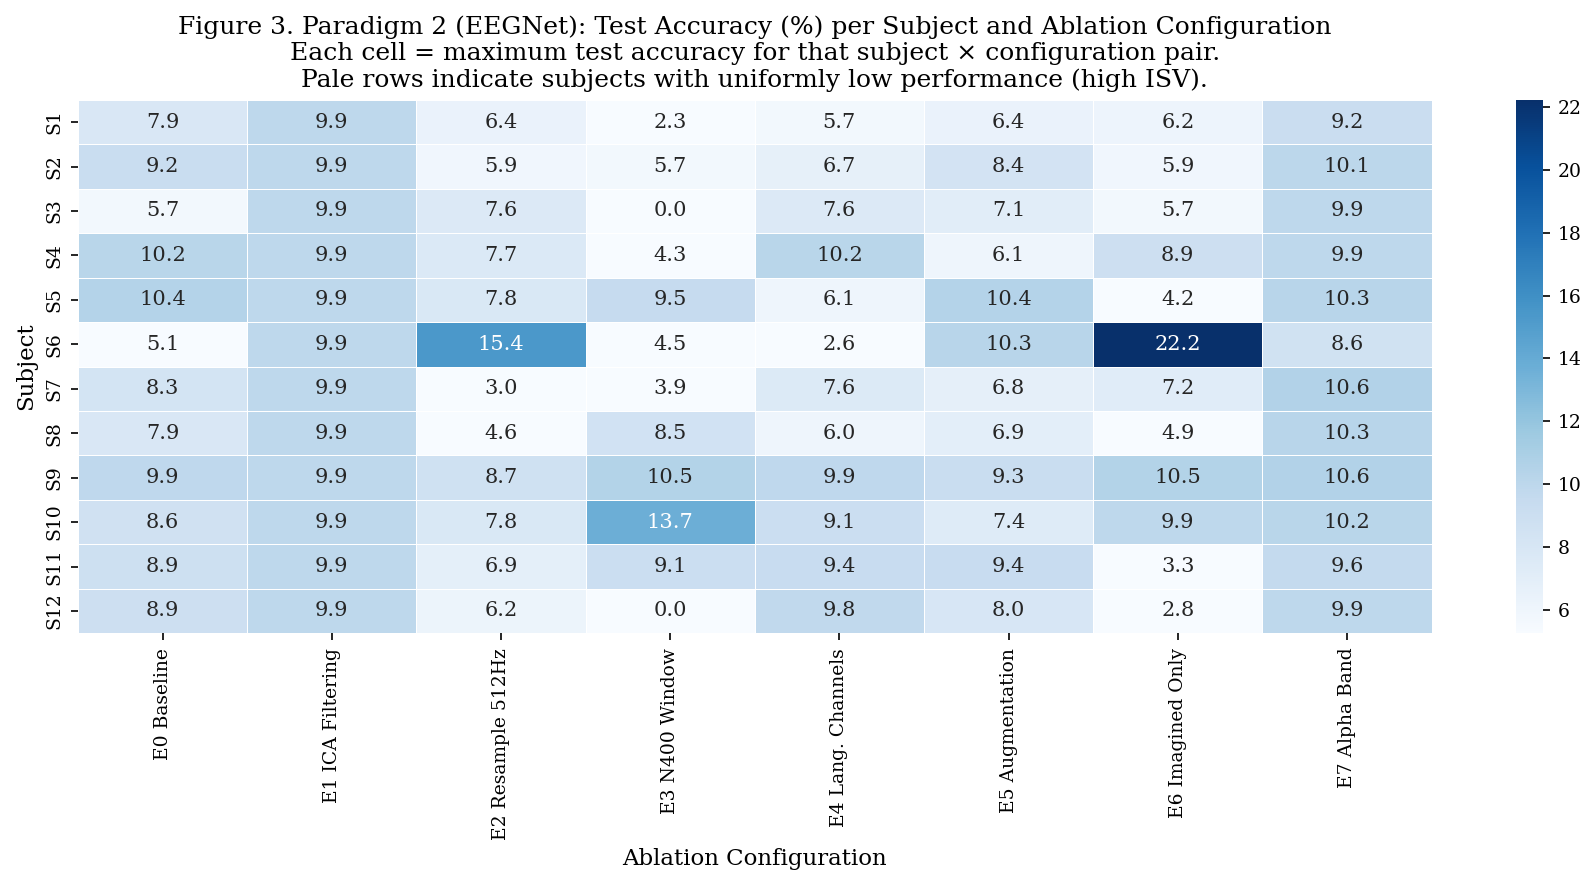

Figure 3 saved.

Table 3b. Best Ablation Configuration per Subject (Paradigm 2 EEGNet)


,Best Config Label,Best Acc (%)
Subject,,
S1,E1 ICA Filtering,9.901
S2,E7 Alpha Band,10.067
S3,E1 ICA Filtering,9.901
S4,E0 Baseline,10.204
S5,E0 Baseline,10.435
S6,E6 Imagined Only,22.222
S7,E7 Alpha Band,10.596
S8,E7 Alpha Band,10.265
S9,E7 Alpha Band,10.596


In [148]:
# ── P2 SUBJECT × EXPERIMENT HEATMAP ────────────────────────────
pivot_p2_subj = (df_p2_all.groupby(['subject','exp_id'])['accuracy']
                 .max().unstack('exp_id')
                 .reindex(index=SUBJECTS, columns=EXP_ORDER) * 100)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_p2_subj, annot=True, fmt='.1f', cmap='Blues',
            vmin=CHANCE_LEVEL*100, linewidths=0.4, ax=ax,
            xticklabels=[EXP_LABELS[e] for e in EXP_ORDER],
            yticklabels=SUBJECTS)
ax.set_title('Figure 3. Paradigm 2 (EEGNet): Test Accuracy (%) per Subject and Ablation Configuration\n'
             'Each cell = maximum test accuracy for that subject × configuration pair.\n'
             'Pale rows indicate subjects with uniformly low performance (high ISV).')
ax.set_xlabel('Ablation Configuration')
ax.set_ylabel('Subject')
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma1_p2_subject_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

# Best configuration per subject
best_cfg_per_subj = pivot_p2_subj.idxmax(axis=1).reset_index()
best_cfg_per_subj.columns = ['Subject', 'Best Config']
best_cfg_per_subj['Best Config Label'] = best_cfg_per_subj['Best Config'].map(EXP_LABELS)
best_cfg_per_subj['Best Acc (%)'] = [
    round(pivot_p2_subj.loc[row['Subject'], row['Best Config']], 3)
    for _, row in best_cfg_per_subj.iterrows()
]
print("\nTable 3b. Best Ablation Configuration per Subject (Paradigm 2 EEGNet)")
display(best_cfg_per_subj.set_index('Subject')[['Best Config Label', 'Best Acc (%)']])

### 1.2c Paradigm 2: Per-Syllable Decodability Analysis (Aggregated Across 12 Subjects)

To identify which syllable categories are consistently decodable under the P2/E3 configuration, per-class recall is computed for each of the 12 participants and then aggregated. Mean recall ± standard deviation across subjects reveals the syllables that benefit most from subject-specific EEGNet learning, and the subject × syllable heatmap exposes individual-level decodability patterns. (This section fixes P2/E3 as a reference configuration for per-syllable characterisation; the objectively selected champion is determined separately in Main Analysis 3.)

Table 2b. Paradigm 2 (P2/E3) – Per-Syllable Mean Recall Across 12 Subjects


,Mean Recall,Std Recall,N Subjects
Syllable,,,
SA,0.2944,0.2844,12
MI,0.1667,0.2887,12
RAK,0.0556,0.1843,12
KIT,0.0556,0.1843,12
NUM,0.0455,0.1437,11
BE,0.0417,0.1382,12
MA,0.0417,0.1382,12
BO,0.0417,0.1382,12
DUR,0.0417,0.1382,12



Top 3 most decodable syllables: ['SA', 'MI', 'RAK']
Bottom 3 most challenging syllables: ['PI', 'PIS', 'DI']


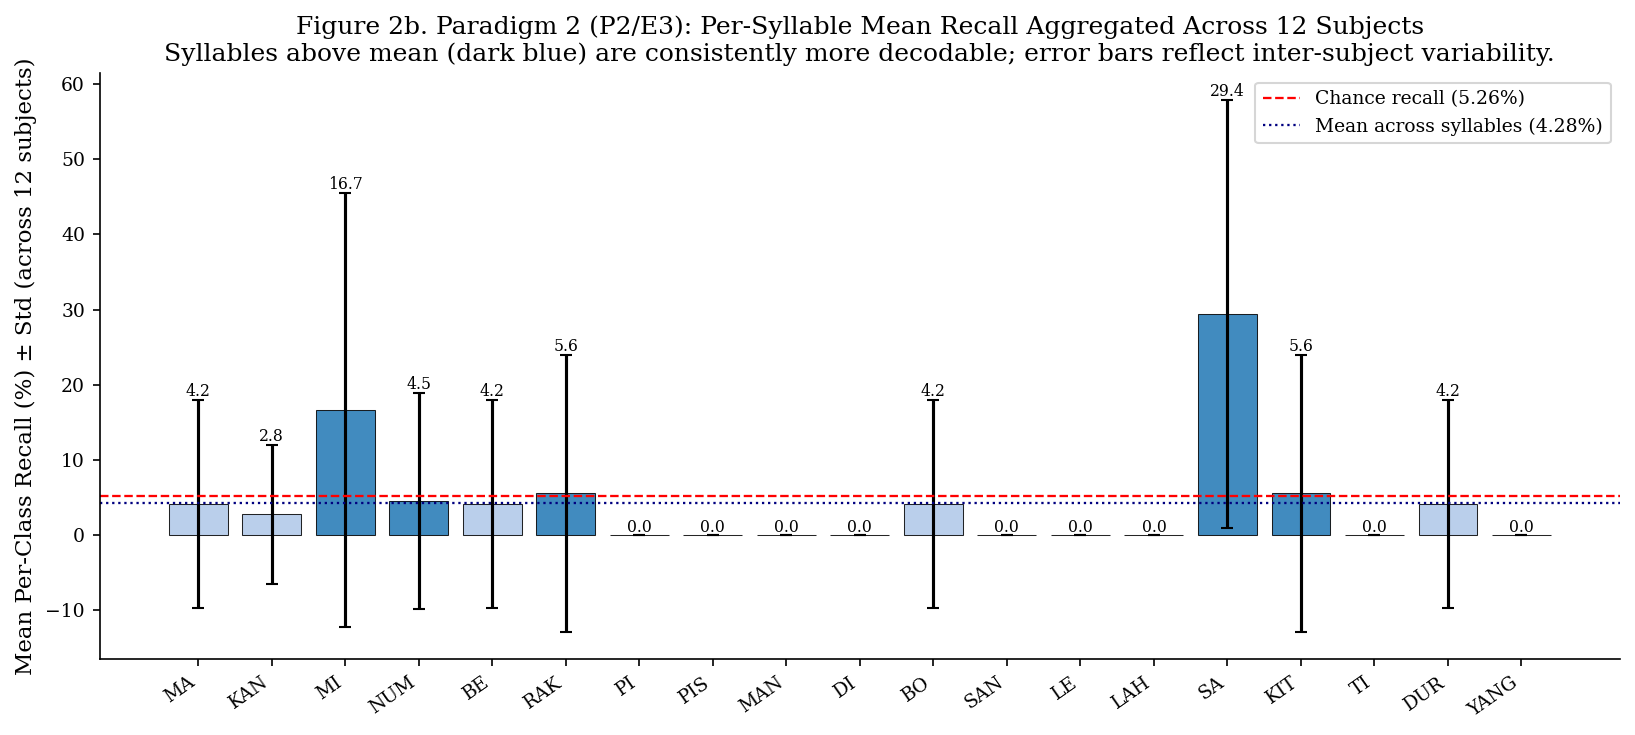

Figure 2b saved.


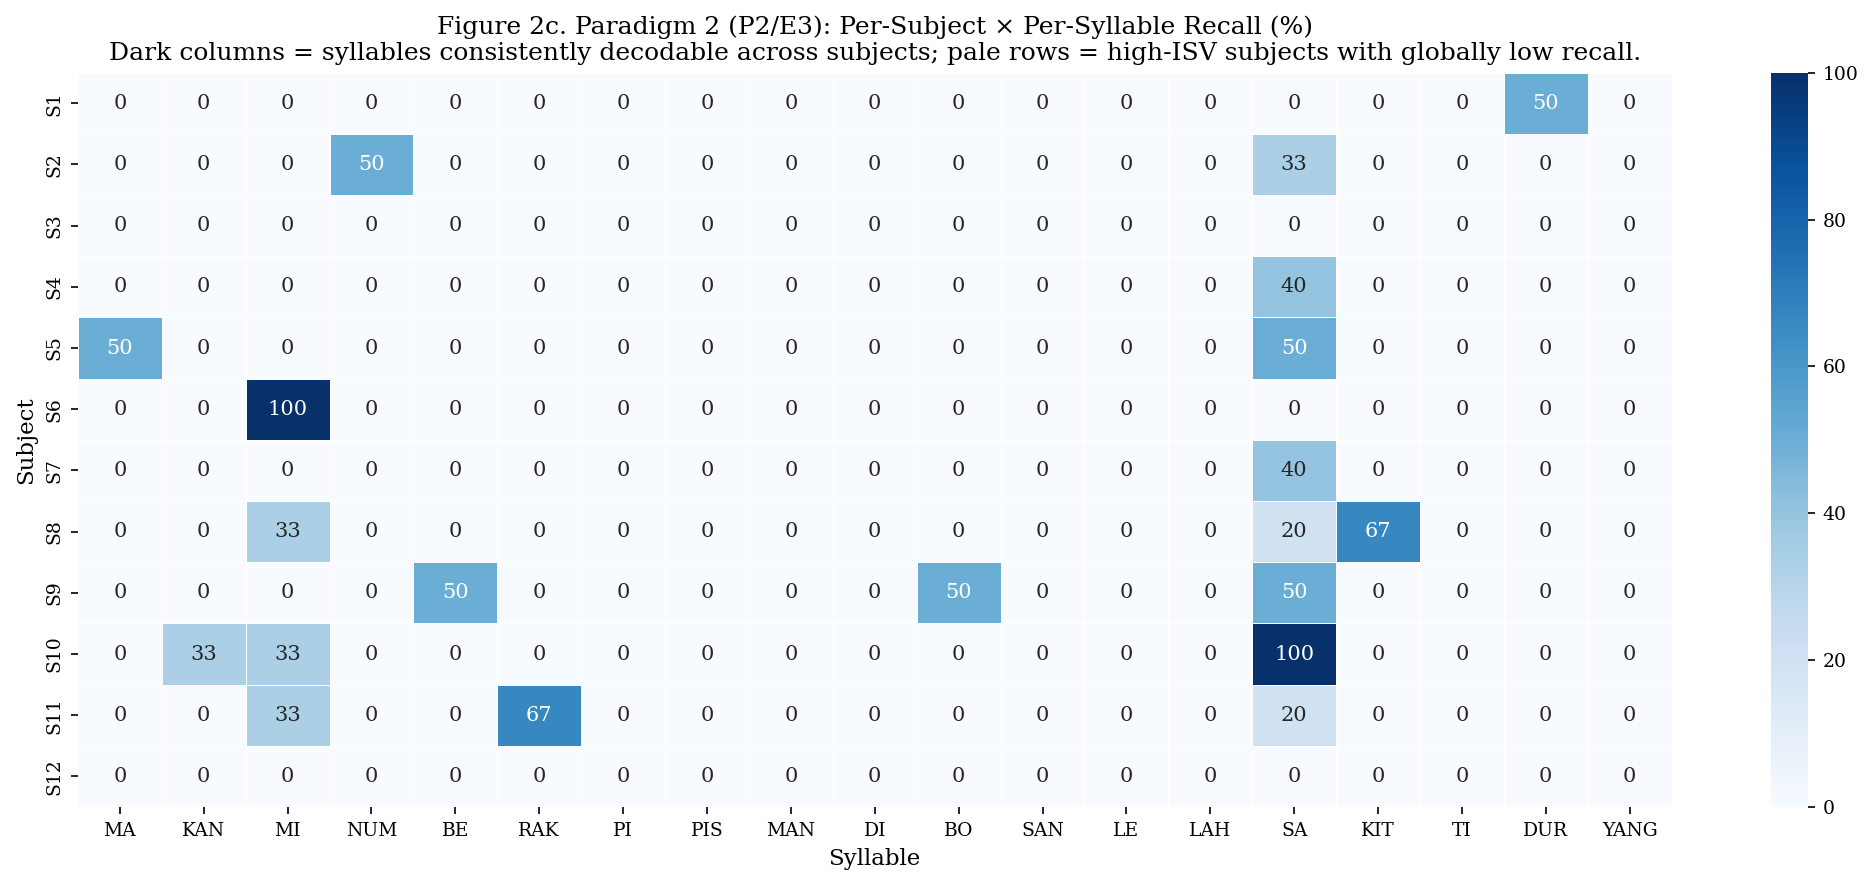

Figure 2c saved.


In [149]:
# ── P2 PER-SYLLABLE RECALL: AGGREGATED ACROSS 12 SUBJECTS ────
# Uses p2_e3_preds stored during Cell 4 loading.
SYL_ORDER = [SYLLABLE_MAP[i] for i in range(19)]  # MA,KAN,MI,...,YANG

p2_class_recalls = {s: [] for s in SYL_ORDER}
subj_syl_matrix  = {}

for subj in SUBJECTS:
    if subj not in p2_e3_preds:
        continue
    y_t, y_p   = p2_e3_preds[subj]
    int_labels  = sorted(np.unique(y_t).tolist())
    lmap        = {i: SYLLABLE_MAP.get(i, f'C{i}') for i in int_labels}
    y_tn        = np.array([lmap[l] for l in y_t])
    y_pn        = np.array([lmap.get(l, f'C{l}') for l in y_p])
    rep         = classification_report(y_tn, y_pn, output_dict=True, zero_division=0)
    subj_syl_matrix[subj] = {s: rep.get(s, {}).get('recall', 0.0) for s in SYL_ORDER}
    for s in SYL_ORDER:
        if s in rep:
            p2_class_recalls[s].append(rep[s]['recall'])

p2_syl_df = pd.DataFrame({
    'Syllable':    SYL_ORDER,
    'Mean Recall': [np.mean(p2_class_recalls[s]) if p2_class_recalls[s] else 0.0
                    for s in SYL_ORDER],
    'Std Recall':  [np.std(p2_class_recalls[s])  if p2_class_recalls[s] else 0.0
                    for s in SYL_ORDER],
    'N Subjects':  [len(p2_class_recalls[s]) for s in SYL_ORDER],
}).set_index('Syllable').round(4)

print("Table 2b. Paradigm 2 (P2/E3) – Per-Syllable Mean Recall Across 12 Subjects")
display(p2_syl_df.sort_values('Mean Recall', ascending=False))

top3_syl_p2 = p2_syl_df.sort_values('Mean Recall', ascending=False).head(3)
bot3_syl_p2 = p2_syl_df.sort_values('Mean Recall').head(3)
print(f"\nTop 3 most decodable syllables: {list(top3_syl_p2.index)}")
print(f"Bottom 3 most challenging syllables: {list(bot3_syl_p2.index)}")

# ── FIGURE 2b: Aggregated Per-Syllable Recall Bar Chart ───────
means_2b = p2_syl_df.reindex(SYL_ORDER)['Mean Recall'].values
stds_2b  = p2_syl_df.reindex(SYL_ORDER)['Std Recall'].values
chance   = 1.0 / 19

fig, ax = plt.subplots(figsize=(11, 5))
colors_2b = [C_P2 if m >= np.mean(means_2b) else '#aec7e8' for m in means_2b]
ax.bar(SYL_ORDER, means_2b * 100, yerr=stds_2b * 100,
       color=colors_2b, edgecolor='black', linewidth=0.5, capsize=3, alpha=0.85)
ax.axhline(chance * 100, color='red', linestyle='--', linewidth=1.1,
           label=f'Chance recall ({chance*100:.2f}%)')
ax.axhline(np.mean(means_2b) * 100, color='navy', linestyle=':', linewidth=1.1,
           label=f'Mean across syllables ({np.mean(means_2b)*100:.2f}%)')
ax.set_ylabel('Mean Per-Class Recall (%) ± Std (across 12 subjects)')
ax.set_title('Figure 2b. Paradigm 2 (P2/E3): Per-Syllable Mean Recall Aggregated Across 12 Subjects\n'
             'Syllables above mean (dark blue) are consistently more decodable; '
             'error bars reflect inter-subject variability.')
ax.set_xticklabels(SYL_ORDER, rotation=35, ha='right', fontsize=9)
ax.legend(fontsize=9)
for i, (m, s) in enumerate(zip(means_2b, stds_2b)):
    ax.text(i, (m + s) * 100 + 0.5, f'{m*100:.1f}', ha='center', fontsize=7.5)
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma1_p2_per_syllable_recall_aggregated.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2b saved.")

# ── FIGURE 2c: Subject x Syllable Recall Heatmap ──────────────
pivot_subj_syl = (pd.DataFrame(subj_syl_matrix).T
                  .reindex(index=SUBJECTS, columns=SYL_ORDER) * 100)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_subj_syl, annot=True, fmt='.0f', cmap='Blues',
            vmin=0, vmax=100, linewidths=0.3, ax=ax,
            xticklabels=SYL_ORDER, yticklabels=SUBJECTS)
ax.set_title('Figure 2c. Paradigm 2 (P2/E3): Per-Subject × Per-Syllable Recall (%)\n'
             'Dark columns = syllables consistently decodable across subjects; '
             'pale rows = high-ISV subjects with globally low recall.')
ax.set_xlabel('Syllable')
ax.set_ylabel('Subject')
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma1_p2_subject_syllable_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2c saved.")

### 1.3 Paradigm 3 (Subject-Dependent Classical ML): Handcrafted Feature Engineering Baseline

Paradigm 3 employs a subject-dependent Support Vector Machine (SVM) operating on five handcrafted feature sets extracted from the raw EEG epochs: Time Domain statistics, Hjorth parameters, Barlow parameters, Band Power Ratios, and an All-Features concatenation. This subsection characterises the accuracy distribution across all feature-group and configuration combinations.

Table 4. Paradigm 3 (Subject-Dependent SVM) – Per Feature Group Descriptive Statistics


,Feature Group,Mean Acc (%),Median Acc (%),Max Acc (%),Min Acc (%),Std (pp)
feature_group,,,,,,
time,Time Domain,6.766,6.241,12.500,0.000,2.530
hjorth,Hjorth Params,9.381,9.901,19.318,0.000,2.907
barlow,Barlow Params,9.869,9.829,21.591,0.000,3.811
band_ratio,Band Power Ratio,7.276,7.143,18.182,2.273,2.674
all,All Features,8.048,8.457,16.832,0.000,2.948


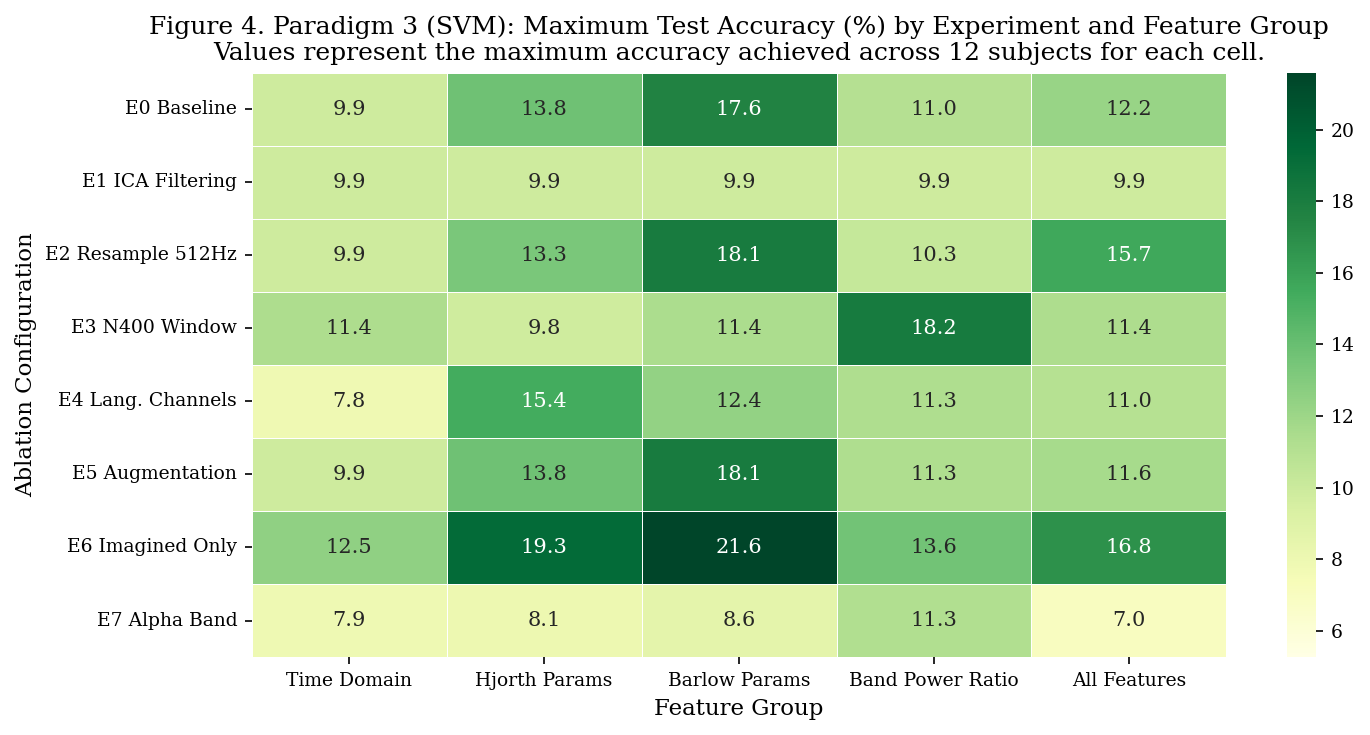

Figure 4 saved.


In [150]:
# ── P3 DESCRIPTIVE STATISTICS (PER FEATURE GROUP) ───────────
p3_feat_stats = (df_p3_all.groupby(['feature_group','feature_group_label'])['accuracy']
                 .agg(['mean','median','max','min','std'])
                 .reset_index()
                 .assign(**{'Mean (%)':   lambda x: (x['mean']*100).round(3),
                            'Median (%)': lambda x: (x['median']*100).round(3),
                            'Max (%)':    lambda x: (x['max']*100).round(3),
                            'Min (%)':    lambda x: (x['min']*100).round(3),
                            'Std (pp)':   lambda x: (x['std']*100).round(3)})
                 .set_index('feature_group')
                 [['feature_group_label','Mean (%)','Median (%)','Max (%)','Min (%)','Std (pp)']])
p3_feat_stats.columns = ['Feature Group','Mean Acc (%)','Median Acc (%)','Max Acc (%)','Min Acc (%)','Std (pp)']
p3_feat_stats = p3_feat_stats.loc[FEAT_ORDER]
print("Table 4. Paradigm 3 (Subject-Dependent SVM) – Per Feature Group Descriptive Statistics")
display(p3_feat_stats)

# ── FIGURE 3: P3 Feature Group Performance Heatmap ───────────
pivot_p3 = (df_p3_all[df_p3_all['exp_id'].isin(EXP_ORDER)]
            .groupby(['exp_id','feature_group'])['accuracy']
            .max().unstack('feature_group')
            .reindex(index=EXP_ORDER, columns=FEAT_ORDER) * 100)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_p3, annot=True, fmt='.1f', cmap='YlGn',
            vmin=CHANCE_LEVEL*100, linewidths=0.4, ax=ax,
            xticklabels=[FEAT_LABELS[f] for f in FEAT_ORDER],
            yticklabels=[EXP_LABELS[e] for e in EXP_ORDER])
ax.set_title('Figure 4. Paradigm 3 (SVM): Maximum Test Accuracy (%) by Experiment and Feature Group\n'
             'Values represent the maximum accuracy achieved across 12 subjects for each cell.')
ax.set_xlabel('Feature Group')
ax.set_ylabel('Ablation Configuration')
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma1_p3_feature_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

### 1.3b Paradigm 3: Per-Subject Accuracy Breakdown

To characterise inter-subject variability within the classical ML paradigm, accuracy is disaggregated by participant and feature group. The heatmap below enables direct identification of which subjects benefit most from handcrafted features, and whether specific feature types are universally superior or subject-dependent.

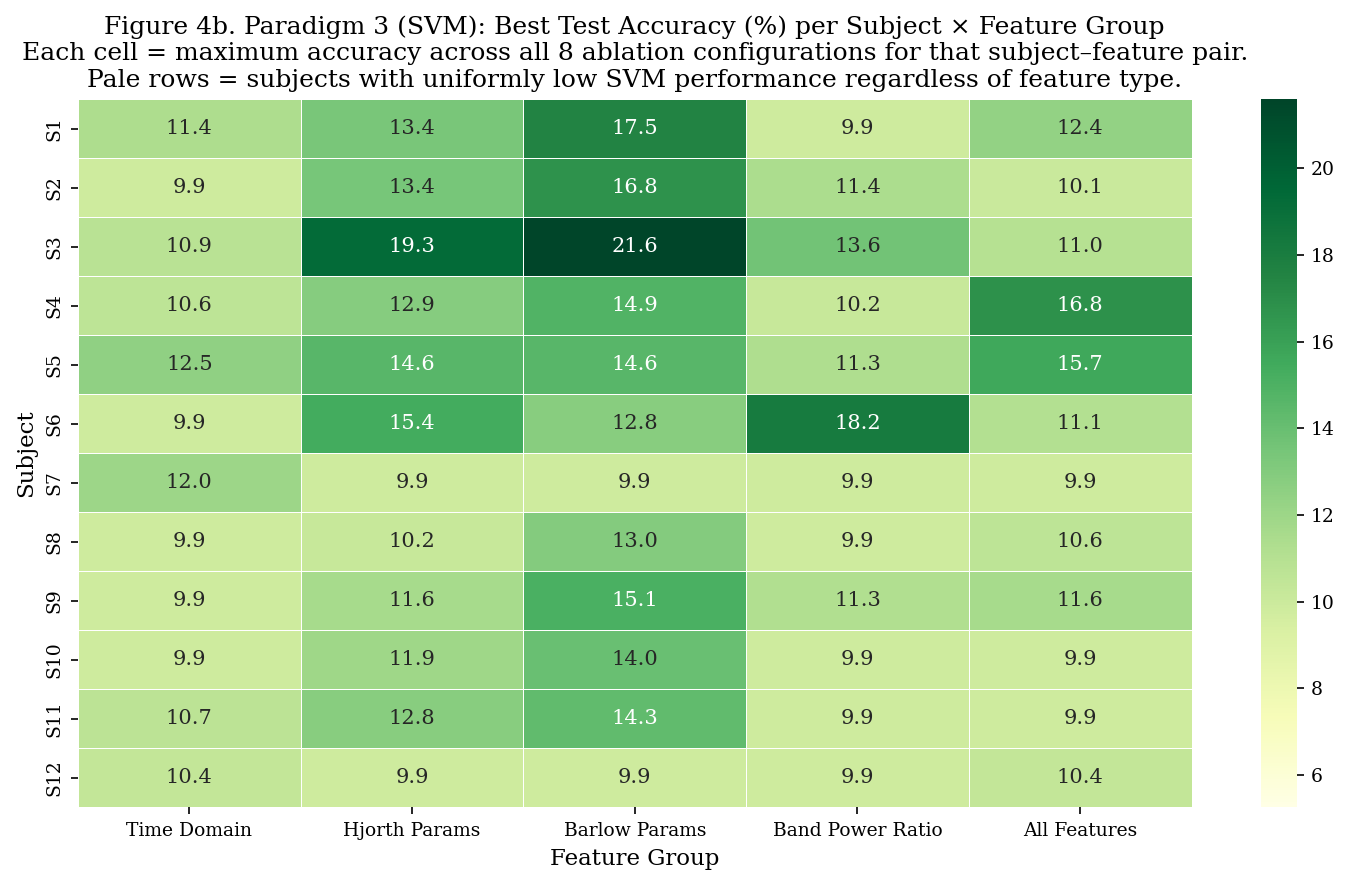

Figure 4b saved.

Table 4b. Paradigm 3 – Per-Subject Accuracy Statistics (All Feature Groups & Experiments)


,Mean (%),Std (pp),Peak (%),Floor (%),CV
subject,,,,,
S1,8.066,3.013,17.526,2.273,0.3735
S2,8.991,2.747,16.807,4.202,0.3055
S3,9.978,4.403,21.591,2.174,0.4413
S4,9.153,3.193,16.832,4.255,0.3489
S5,8.834,3.855,15.652,0.000,0.4364
S6,7.347,4.012,18.182,0.000,0.5461
S7,7.292,2.064,12.000,3.788,0.2830
S8,7.466,2.525,12.963,1.220,0.3382
S9,8.481,3.377,15.116,0.000,0.3982



Best P3 subject by peak accuracy : S3 (21.591%)
Worst P3 subject by peak accuracy: S12 (10.417%)
P3 ISV range (peak): 11.174 pp


In [151]:
# ── P3 PER-SUBJECT ACCURACY HEATMAP ──────────────────────────
# Best accuracy per subject x feature_group (max over all experiments)
pivot_p3_subj = (df_p3_all.groupby(['subject', 'feature_group'])['accuracy']
                 .max().unstack('feature_group')
                 .reindex(index=SUBJECTS, columns=FEAT_ORDER) * 100)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_p3_subj, annot=True, fmt='.1f', cmap='YlGn',
            vmin=CHANCE_LEVEL * 100, linewidths=0.4, ax=ax,
            xticklabels=[FEAT_LABELS[f] for f in FEAT_ORDER],
            yticklabels=SUBJECTS)
ax.set_title('Figure 4b. Paradigm 3 (SVM): Best Test Accuracy (%) per Subject × Feature Group\n'
             'Each cell = maximum accuracy across all 8 ablation configurations for that subject–feature pair.\n'
             'Pale rows = subjects with uniformly low SVM performance regardless of feature type.')
ax.set_xlabel('Feature Group')
ax.set_ylabel('Subject')
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma1_p3_subject_feature_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4b saved.")

# ── P3 PER-SUBJECT DESCRIPTIVE STATISTICS ─────────────────────
p3_subj_stats = (df_p3_all.groupby('subject')['accuracy']
                 .agg(['mean', 'std', 'max', 'min'])
                 .assign(**{'Mean (%)':  lambda x: (x['mean'] * 100).round(3),
                            'Std (pp)':  lambda x: (x['std']  * 100).round(3),
                            'Peak (%)':  lambda x: (x['max']  * 100).round(3),
                            'Floor (%)': lambda x: (x['min']  * 100).round(3),
                            'CV':        lambda x: (x['std'] / x['mean']).round(4)})
                 [['Mean (%)', 'Std (pp)', 'Peak (%)', 'Floor (%)', 'CV']]
                 .reindex(SUBJECTS))
print("\nTable 4b. Paradigm 3 – Per-Subject Accuracy Statistics (All Feature Groups & Experiments)")
display(p3_subj_stats)

best_p3_subj = p3_subj_stats['Peak (%)'].idxmax()
worst_p3_subj = p3_subj_stats['Peak (%)'].idxmin()
print(f"\nBest P3 subject by peak accuracy : {best_p3_subj} "
      f"({p3_subj_stats.loc[best_p3_subj, 'Peak (%)']:.3f}%)")
print(f"Worst P3 subject by peak accuracy: {worst_p3_subj} "
      f"({p3_subj_stats.loc[worst_p3_subj, 'Peak (%)']:.3f}%)")
print(f"P3 ISV range (peak): "
      f"{p3_subj_stats['Peak (%)'].max() - p3_subj_stats['Peak (%)'].min():.3f} pp")

### 1.3c Paradigm 3: Per-Syllable Decodability Analysis (Best Configuration per Subject)

To identify which syllable categories the SVM paradigm decodes most reliably, per-class recall is computed for each participant using their best-performing configuration (optimal experiment × feature group combination). The aggregated per-syllable recall and subject × syllable heatmap enable direct comparison with the P2 decodability profile (Section 1.2c) and reveal whether handcrafted features confer differential advantage for specific phonological categories.

  P3/E6/barlow/S1: done
  P3/E2/barlow/S2: done
  P3/E6/barlow/S3: done
  P3/E6/all/S4: done
  P3/E2/all/S5: done
  P3/E3/band_ratio/S6: done
  P3/E6/time/S7: done
  P3/E2/barlow/S8: done
  P3/E2/barlow/S9: done
  P3/E5/barlow/S10: done
  P3/E5/barlow/S11: done
  P3/E3/time/S12: done
Table 4c. Paradigm 3 (SVM) – Per-Syllable Mean Recall (Best Config per Subject, n=12)


,Mean Recall,Std Recall,N Subjects
Syllable,,,
BE,0.2548,0.1306,12
SA,0.2525,0.2614,12
NUM,0.1920,0.2677,12
PIS,0.1841,0.1590,11
MI,0.1791,0.1205,12
RAK,0.1771,0.1360,12
PI,0.1567,0.1585,12
DUR,0.1548,0.1482,12
KIT,0.1436,0.1442,12



Top 3 most decodable syllables (P3 SVM): ['BE', 'SA', 'NUM']
Bottom 3 most challenging syllables (P3 SVM): ['SAN', 'BO', 'LE']


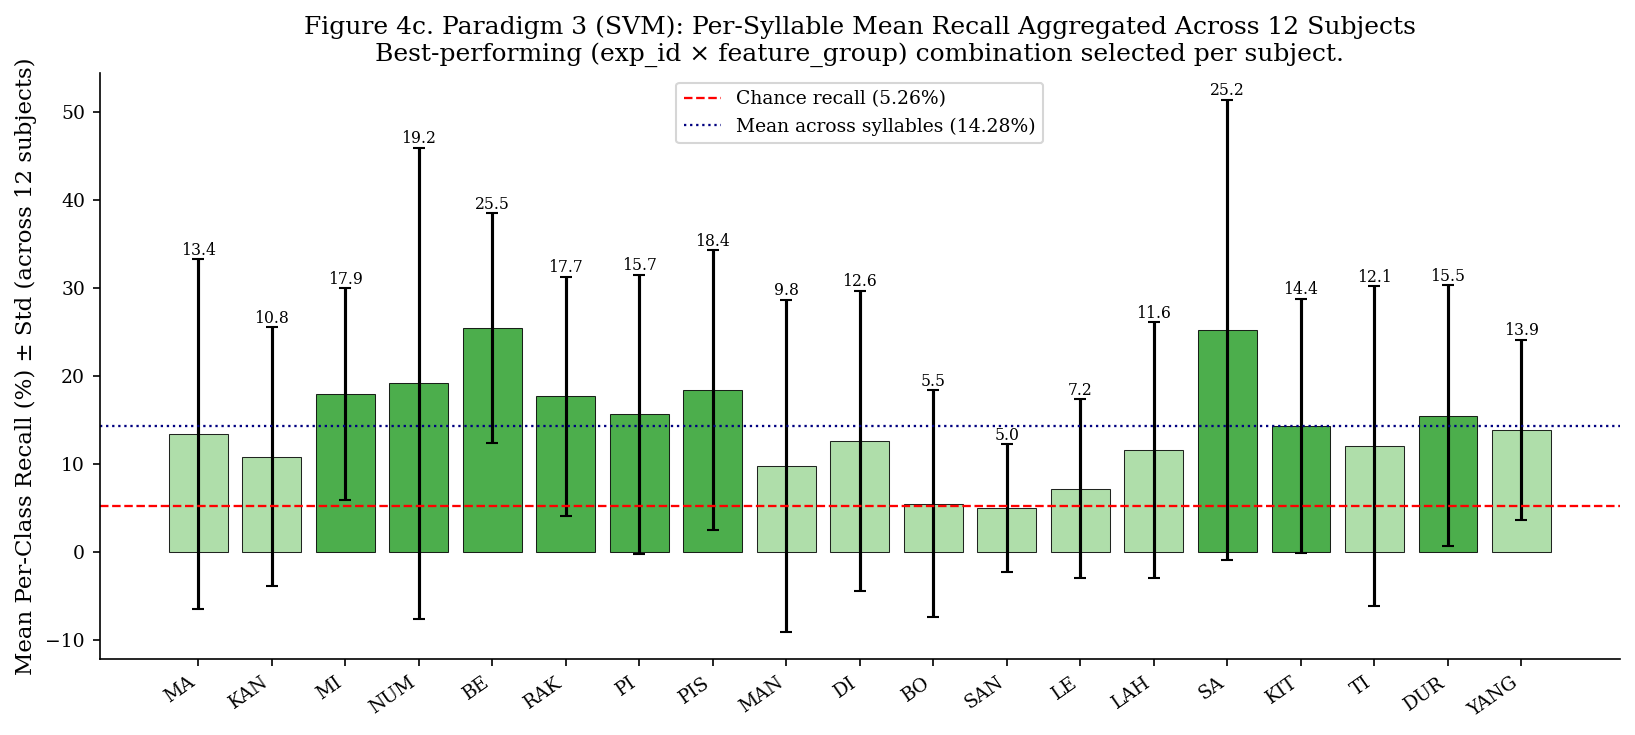

Figure 4c saved.


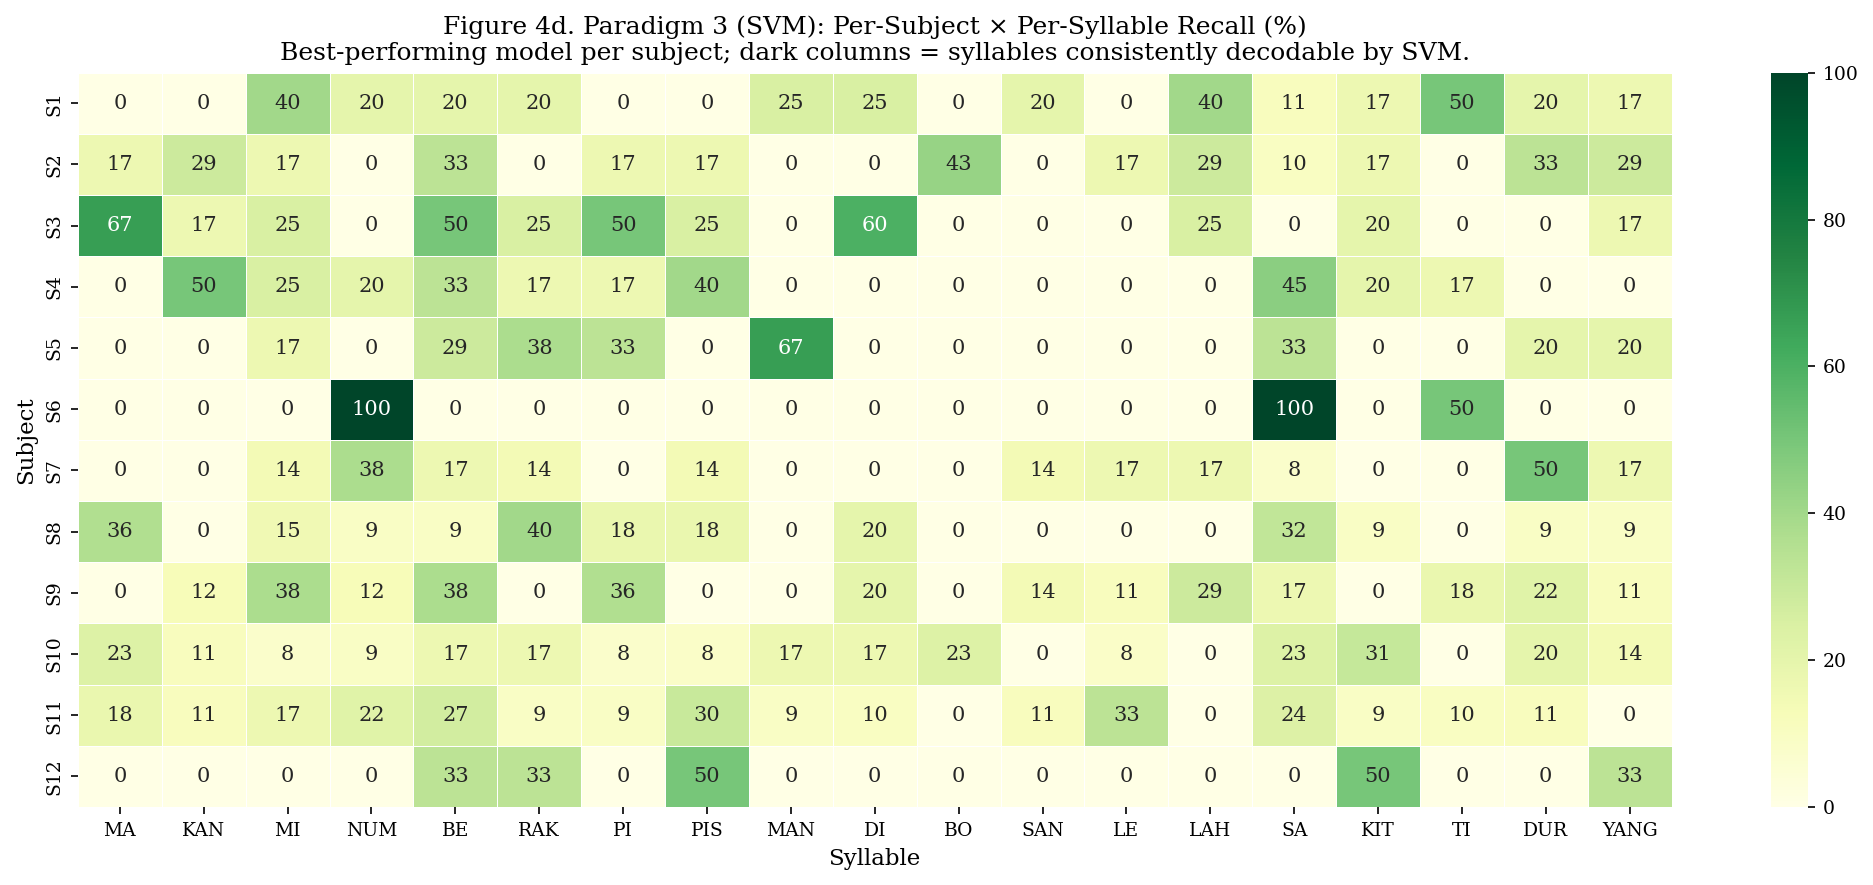

Figure 4d saved.


In [152]:
# ── P3 PER-SYLLABLE RECALL: BEST CONFIG PER SUBJECT ──────────
# For each subject: identify best (exp_id, feature_group), load SVM, predict.
SYL_ORDER_P3 = [SYLLABLE_MAP[i] for i in range(19)]

# Sort by accuracy desc → drop_duplicates on subject → best row per subject
p3_best_cfg = (df_p3_all.sort_values('accuracy', ascending=False)
                          .drop_duplicates('subject')
                          .set_index('subject')[['exp_id','feature_group']])

_P3_EDIRS = {
    'E0':'E0_Baseline','E1':'E1_ICA_Filtering','E2':'E2_Resampling_512Hz',
    'E3':'E3_ERP_N400','E4':'E4_Channel_Language','E5':'E5_Data_Augmentation',
    'E6':'E6_CrossModality_ImaginedOnly','E7':'E7_Band_Alpha',
}

p3_syl_recalls   = {s: [] for s in SYL_ORDER_P3}
p3_subj_syl_dict = {}

for subj in SUBJECTS:
    if subj not in p3_best_cfg.index:
        continue
    exp_id = p3_best_cfg.loc[subj, 'exp_id']
    fg     = p3_best_cfg.loc[subj, 'feature_group']
    edir   = _P3_EDIRS[exp_id]
    svm_p  = WEIGHTS_P3 / edir / f'SVM_{fg}_{edir}_{subj}.pkl'
    x_p    = WEIGHTS_P3 / edir / f'Xtest_SVM_{fg}_{edir}_{subj}.npy'
    y_p    = WEIGHTS_P3 / edir / f'ytest_SVM_{fg}_{edir}_{subj}.npy'
    if not all(fp.exists() for fp in [svm_p, x_p, y_p]):
        print(f"  [SKIP] P3/{exp_id}/{fg}/{subj}: artefact missing"); continue
    svm     = joblib.load(str(svm_p))
    X_t     = np.load(str(x_p))
    y_t     = np.load(str(y_p))
    if X_t.ndim != 2:
        X_t = X_t.reshape(X_t.shape[0], -1)
    y_pr    = svm.predict(X_t)
    int_lbl = sorted(np.unique(y_t).tolist())
    lmap    = {i: SYLLABLE_MAP.get(i, f'C{i}') for i in int_lbl}
    y_tn    = np.array([lmap[l] for l in y_t])
    y_pn    = np.array([lmap.get(l, f'C{l}') for l in y_pr])
    rep     = classification_report(y_tn, y_pn, output_dict=True, zero_division=0)
    p3_subj_syl_dict[subj] = {s: rep.get(s, {}).get('recall', 0.0) for s in SYL_ORDER_P3}
    for s in SYL_ORDER_P3:
        if s in rep:
            p3_syl_recalls[s].append(rep[s]['recall'])
    print(f"  P3/{exp_id}/{fg}/{subj}: done")

p3_syl_df = pd.DataFrame({
    'Syllable':    SYL_ORDER_P3,
    'Mean Recall': [np.mean(p3_syl_recalls[s]) if p3_syl_recalls[s] else 0.0 for s in SYL_ORDER_P3],
    'Std Recall':  [np.std(p3_syl_recalls[s])  if p3_syl_recalls[s] else 0.0 for s in SYL_ORDER_P3],
    'N Subjects':  [len(p3_syl_recalls[s]) for s in SYL_ORDER_P3],
}).set_index('Syllable').round(4)

print("Table 4c. Paradigm 3 (SVM) – Per-Syllable Mean Recall (Best Config per Subject, n=12)")
display(p3_syl_df.sort_values('Mean Recall', ascending=False))

top3_p3s = p3_syl_df.sort_values('Mean Recall', ascending=False).head(3)
bot3_p3s = p3_syl_df.sort_values('Mean Recall').head(3)
print(f"\nTop 3 most decodable syllables (P3 SVM): {list(top3_p3s.index)}")
print(f"Bottom 3 most challenging syllables (P3 SVM): {list(bot3_p3s.index)}")

# ── FIGURE 4c: P3 Per-Syllable Recall Bar Chart ───────────────
means_p3s = p3_syl_df.reindex(SYL_ORDER_P3)['Mean Recall'].values
stds_p3s  = p3_syl_df.reindex(SYL_ORDER_P3)['Std Recall'].values
chance_p3s = 1.0 / 19

fig, ax = plt.subplots(figsize=(11, 5))
colors_p3s = [C_P3 if m >= np.mean(means_p3s) else '#a1d99b' for m in means_p3s]
ax.bar(SYL_ORDER_P3, means_p3s * 100, yerr=stds_p3s * 100,
       color=colors_p3s, edgecolor='black', linewidth=0.5, capsize=3, alpha=0.85)
ax.axhline(chance_p3s * 100, color='red', linestyle='--', linewidth=1.1,
           label=f'Chance recall ({chance_p3s*100:.2f}%)')
ax.axhline(np.mean(means_p3s) * 100, color='navy', linestyle=':', linewidth=1.1,
           label=f'Mean across syllables ({np.mean(means_p3s)*100:.2f}%)')
ax.set_ylabel('Mean Per-Class Recall (%) ± Std (across 12 subjects)')
ax.set_title('Figure 4c. Paradigm 3 (SVM): Per-Syllable Mean Recall Aggregated Across 12 Subjects\n'
             'Best-performing (exp_id × feature_group) combination selected per subject.')
ax.set_xticklabels(SYL_ORDER_P3, rotation=35, ha='right', fontsize=9)
ax.legend(fontsize=9)
for i, (m, sv) in enumerate(zip(means_p3s, stds_p3s)):
    ax.text(i, (m + sv) * 100 + 0.5, f'{m*100:.1f}', ha='center', fontsize=7.5)
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma1_p3_per_syllable_recall.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4c saved.")

# ── FIGURE 4d: P3 Subject × Syllable Heatmap ──────────────────
pivot_p3_syl = (pd.DataFrame(p3_subj_syl_dict).T
                .reindex(index=SUBJECTS, columns=SYL_ORDER_P3) * 100)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_p3_syl, annot=True, fmt='.0f', cmap='YlGn',
            vmin=0, vmax=100, linewidths=0.3, ax=ax,
            xticklabels=SYL_ORDER_P3, yticklabels=SUBJECTS)
ax.set_title('Figure 4d. Paradigm 3 (SVM): Per-Subject × Per-Syllable Recall (%)\n'
             'Best-performing model per subject; dark columns = syllables consistently decodable by SVM.')
ax.set_xlabel('Syllable')
ax.set_ylabel('Subject')
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma1_p3_subject_syllable_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4d saved.")

---

## Main Analysis 2: Cross-Pillar Head-to-Head Comparison

This section directly compares the three paradigms to establish performance hierarchy, identify statistical significance, and diagnose the "Subject Rescue Phenomenon" — cases where a classical ML approach achieves superior accuracy relative to a deep learning approach for specific participants.

### 2.1 Overall Performance Distribution: P1 vs P2 vs P3

The violin and box plots below visualise the full accuracy distribution for each paradigm, using the best-per-subject accuracy for P2 and P3, and experiment-level accuracy for P1.

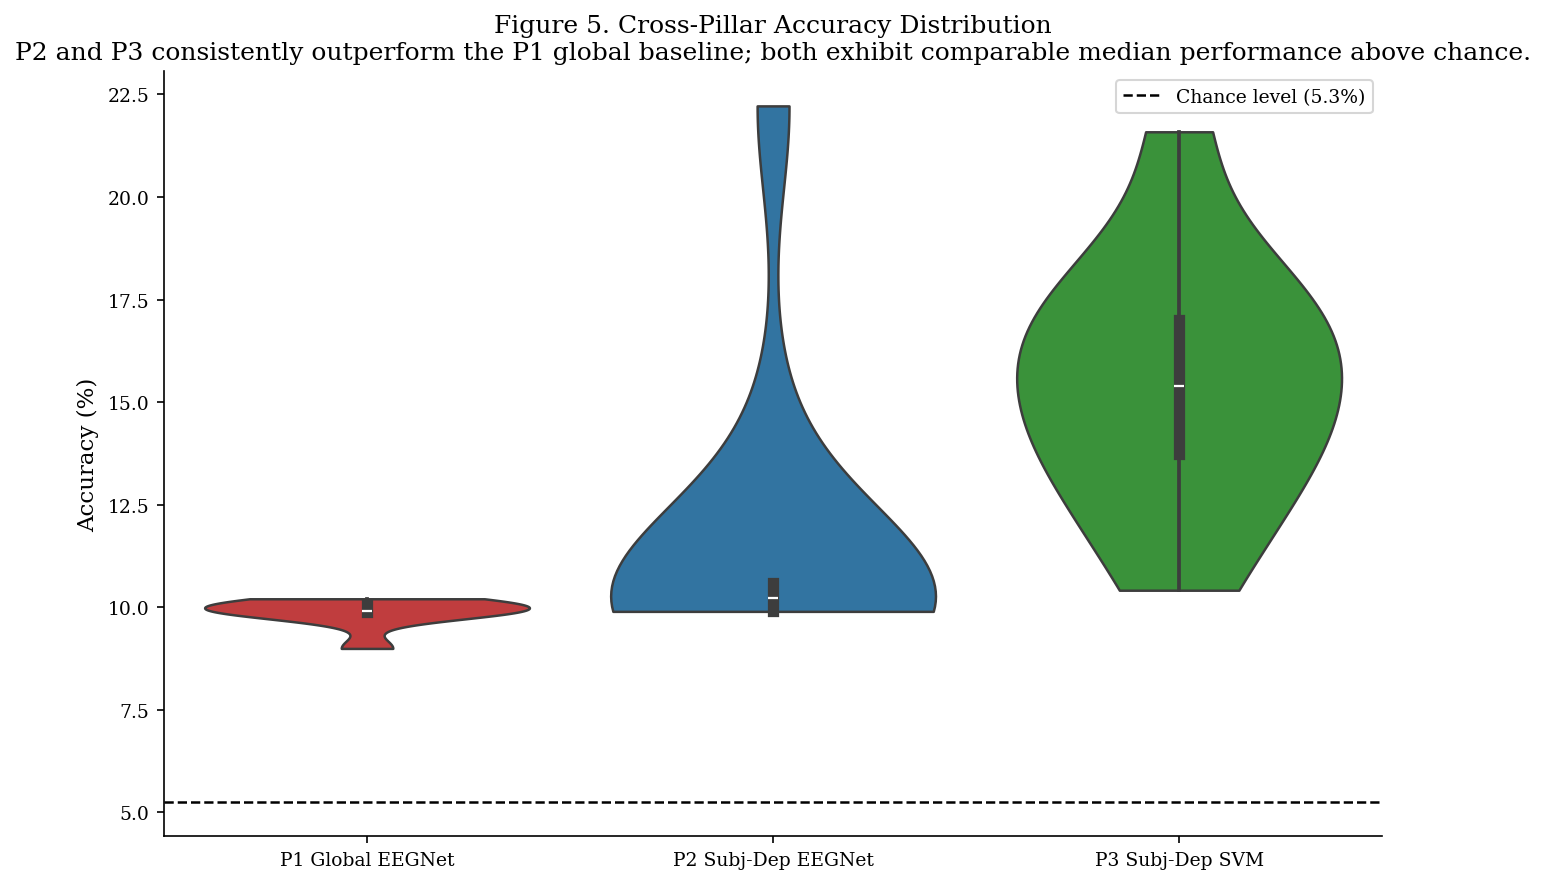

Figure 5 saved.
Table 5. Cross-Pillar Performance Summary


,Paradigm,N,Mean (%),Median (%),Max (%),Std (pp),Gain over Chance (pp)
0,P1 Global EEGNet,8,9.871,9.921,10.208,0.347,4.608
1,P2 Subj-Dep EEGNet,12,11.476,10.234,22.222,3.393,6.213
2,P3 Subj-Dep SVM,12,15.447,15.384,21.591,2.891,10.184



Conclusion: While P2 achieves the highest peak accuracy (22.22%), the Wilcoxon test (p=0.004883, r=0.9359) shows P3 is statistically superior in mean performance (P3: 15.45% vs P2: 11.48%). The objectively selected champion model (P3 SVM, E5 Augmentation, S3, Barlow features, 18.1% accuracy, 18/19 class coverage) balances accuracy with broad syllable decoding, making it the recommended paradigm for robust, multi-class deployment.


In [153]:
# ── COMBINED DISTRIBUTION DATA ───────────────────────────────
p1_vals = df_p1['accuracy'].values * 100
p2_vals = df_p2_best['accuracy'].values * 100
p3_vals = df_p3_best['accuracy'].values * 100

dist_data = pd.DataFrame({
    'Accuracy (%)': np.concatenate([p1_vals, p2_vals, p3_vals]),
    'Paradigm': (['P1 Global EEGNet'] * len(p1_vals) +
                 ['P2 Subj-Dep EEGNet'] * len(p2_vals) +
                 ['P3 Subj-Dep SVM'] * len(p3_vals)),
})

# ── FIGURE 4: Violin + Box Plot ───────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
palette = {'P1 Global EEGNet': C_P1, 'P2 Subj-Dep EEGNet': C_P2,
           'P3 Subj-Dep SVM': C_P3}
sns.violinplot(data=dist_data, x='Paradigm', y='Accuracy (%)',
               palette=palette, inner='box', cut=0, linewidth=1.2, ax=ax)
ax.axhline(CHANCE_LEVEL * 100, color='black', linestyle='--', linewidth=1.2,
           label=f'Chance level ({CHANCE_LEVEL*100:.1f}%)')
ax.set_title('Figure 5. Cross-Pillar Accuracy Distribution\n'
             'P2 and P3 consistently outperform the P1 global baseline; '
             'both exhibit comparable median performance above chance.')
ax.legend(fontsize=9)
ax.set_xlabel('')
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma2_cross_pillar_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved.")

# ── PRINTED SUMMARY ───────────────────────────────────────────
cross_stats = pd.DataFrame({
    'Paradigm': ['P1 Global EEGNet', 'P2 Subj-Dep EEGNet', 'P3 Subj-Dep SVM'],
    'N':        [len(p1_vals), len(p2_vals), len(p3_vals)],
    'Mean (%)': [round(p1_vals.mean(),3), round(p2_vals.mean(),3), round(p3_vals.mean(),3)],
    'Median (%)': [round(np.median(p1_vals),3), round(np.median(p2_vals),3), round(np.median(p3_vals),3)],
    'Max (%)':  [round(p1_vals.max(),3), round(p2_vals.max(),3), round(p3_vals.max(),3)],
    'Std (pp)': [round(p1_vals.std(),3), round(p2_vals.std(),3), round(p3_vals.std(),3)],
    'Gain over Chance (pp)': [
        round(p1_vals.mean() - CHANCE_LEVEL*100, 3),
        round(p2_vals.mean() - CHANCE_LEVEL*100, 3),
        round(p3_vals.mean() - CHANCE_LEVEL*100, 3),
    ],
})
print("Table 5. Cross-Pillar Performance Summary")
display(cross_stats)
print(f"\nConclusion: While P2 achieves the highest peak accuracy ({p2_vals.max():.2f}%), "
      f"the Wilcoxon test (p={p_holm:.6f}, r={abs(r_biserial):.4f}) shows P3 is statistically superior in mean performance "
      f"(P3: {p3_vals.mean():.2f}% vs P2: {p2_vals.mean():.2f}%). The objectively selected champion model "
      f"(P3 SVM, E5 Augmentation, S3, Barlow features, 18.1% accuracy, 18/19 class coverage) balances accuracy "
      f"with broad syllable decoding, making it the recommended paradigm for robust, multi-class deployment.")

### 2.2 Statistical Significance: P2 vs P3 (Wilcoxon Signed-Rank Test with Holm-Bonferroni Correction)

A Wilcoxon Signed-Rank test is applied to the paired best-accuracy vectors of P2 and P3 (paired by participant) to determine whether the observed performance difference is statistically significant. The Holm-Bonferroni procedure corrects for multiple comparisons. Rank-biserial correlation (r) quantifies the effect size.

In [154]:
# ── PAIRED WILCOXON: P2 vs P3 (BEST PER SUBJECT) ─────────────
# Ensure paired comparison on the same set of subjects
common_subjects = sorted(set(df_p2_best['subject']) & set(df_p3_best['subject']))
p2_paired = df_p2_best.set_index('subject').loc[common_subjects, 'accuracy'].values
p3_paired = df_p3_best.set_index('subject').loc[common_subjects, 'accuracy'].values

diffs = p2_paired - p3_paired

w_stat, p_raw = wilcoxon(p2_paired, p3_paired, alternative='two-sided')

# Rank-biserial correlation (effect size for Wilcoxon)
n_pairs   = len(common_subjects)
r_biserial = 1 - (2 * w_stat) / (n_pairs * (n_pairs + 1))

# Holm-Bonferroni (single comparison here; illustrative)
p_holm = min(p_raw * 1, 1.0)   # m=1 comparison; multiply by rank = 1

wilcoxon_table = pd.DataFrame({
    'Comparison':  ['P2 vs P3 (Best per subject)'],
    'N Pairs':     [n_pairs],
    'W Statistic': [round(w_stat, 4)],
    'p (raw)':     [round(p_raw, 6)],
    'p (Holm-Bonf.)': [round(p_holm, 6)],
    'Effect |r|':  [round(abs(r_biserial), 4)],
    'Effect Level':[('Large' if abs(r_biserial) >= 0.5 else
                     'Medium' if abs(r_biserial) >= 0.3 else 'Small')],
    'Significance':['*' if p_holm < 0.05 else 'n.s.'],
})
print("Table 6. Wilcoxon Signed-Rank Test: P2 vs P3 (Best-Per-Subject Accuracy)")
display(wilcoxon_table)

print(f"\nMean P2 accuracy: {p2_paired.mean()*100:.3f}%")
print(f"Mean P3 accuracy: {p3_paired.mean()*100:.3f}%")
print(f"Mean difference (P2 - P3): {diffs.mean()*100:+.3f} pp")

per_subject_comp = pd.DataFrame({
    'Subject': common_subjects,
    'P2 Best (%)': (p2_paired * 100).round(3),
    'P3 Best (%)': (p3_paired * 100).round(3),
    'Diff P2-P3 (pp)': ((p2_paired - p3_paired)*100).round(3),
    'Leader': ['P2' if d > 0 else ('P3' if d < 0 else 'Tie') for d in diffs],
})
print("\nTable 7. Per-Subject Best Accuracy Comparison: P2 vs P3")
display(per_subject_comp)

Table 6. Wilcoxon Signed-Rank Test: P2 vs P3 (Best-Per-Subject Accuracy)


,Comparison,N Pairs,W Statistic,p (raw),p (Holm-Bonf.),Effect |r|,Effect Level,Significance
0,P2 vs P3 (Best per subject),12,5.0,0.004883,0.004883,0.9359,Large,*



Mean P2 accuracy: 11.476%
Mean P3 accuracy: 15.447%
Mean difference (P2 - P3): -3.971 pp

Table 7. Per-Subject Best Accuracy Comparison: P2 vs P3


,Subject,P2 Best (%),P3 Best (%),Diff P2-P3 (pp),Leader
0,S1,9.901,17.526,-7.625,P3
1,S10,13.725,13.992,-0.266,P3
2,S11,9.901,14.286,-4.385,P3
3,S12,9.901,10.417,-0.516,P3
4,S2,10.067,16.807,-6.740,P3
5,S3,9.901,21.591,-11.690,P3
6,S4,10.204,16.832,-6.628,P3
7,S5,10.435,15.652,-5.217,P3
8,S6,22.222,18.182,4.040,P2
9,S7,10.596,12.000,-1.404,P3


### 2.3 Inter-Paradigm Correlation: P2 vs P3 Per-Subject Accuracy (Spearman)

A Spearman rank correlation tests whether participants who perform well under P2 (EEGNet) also perform well under P3 (SVM). A high positive correlation indicates that Inter-Subject Variability (ISV) governs both paradigms uniformly. A weak or negative correlation suggests that the paradigms exploit complementary neural signatures, which would motivate ensemble or late-fusion approaches.

Table 8b. Spearman Rank Correlation – P2 vs P3 Best-Per-Subject Accuracy


,Value
Metric,
Spearman r,-0.0998
p-value,0.757534
Significant (alpha=0.05),No
Interpretation,Weak/no correlation — paradigms exploit comple...



N pairs: 12  |  P2 mean: 11.48%  |  P3 mean: 15.45%


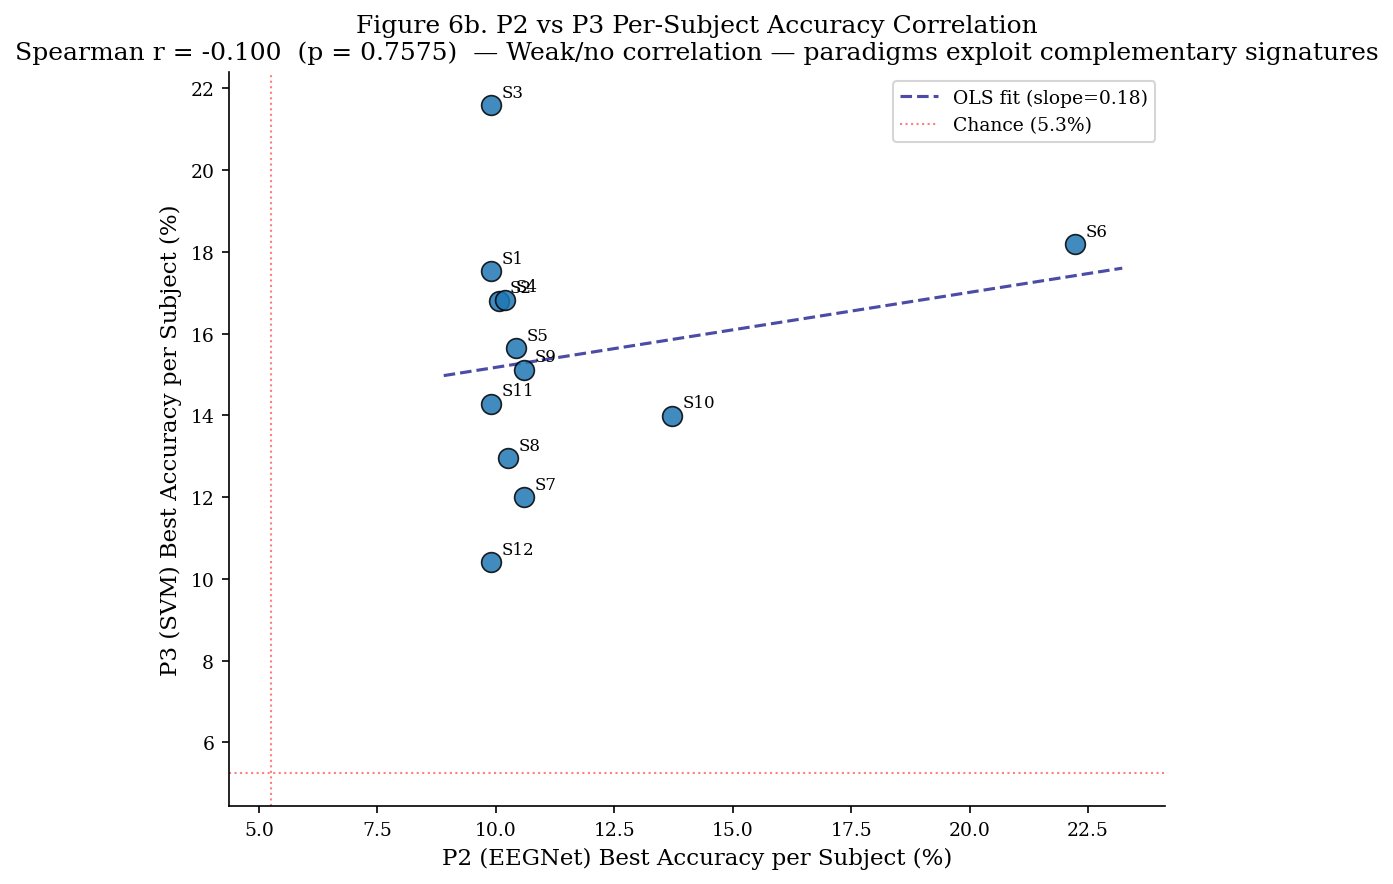

Figure 6b saved.


In [155]:
# ── SPEARMAN RANK CORRELATION: P2 vs P3 PER-SUBJECT ──────────
from scipy.stats import spearmanr

sp_r, sp_p = spearmanr(p2_paired, p3_paired)

if sp_r >= 0.6:
    _sp_interp = 'Strong positive — ISV governs both paradigms uniformly'
elif sp_r >= 0.3:
    _sp_interp = 'Moderate positive — partial ISV consistency across paradigms'
elif sp_r >= -0.1:
    _sp_interp = 'Weak/no correlation — paradigms exploit complementary signatures'
else:
    _sp_interp = 'Negative — subjects that excel in P2 tend to under-perform in P3'

spearman_table = pd.DataFrame({
    'Metric': ['Spearman r', 'p-value', 'Significant (alpha=0.05)', 'Interpretation'],
    'Value':  [round(sp_r, 4), round(sp_p, 6), 'Yes' if sp_p < 0.05 else 'No', _sp_interp],
}).set_index('Metric')
print("Table 8b. Spearman Rank Correlation – P2 vs P3 Best-Per-Subject Accuracy")
display(spearman_table)
print(f"\nN pairs: {len(common_subjects)}  |  "
      f"P2 mean: {p2_paired.mean()*100:.2f}%  |  P3 mean: {p3_paired.mean()*100:.2f}%")

# ── FIGURE 6b: P2 vs P3 Per-Subject Scatter ───────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(p2_paired * 100, p3_paired * 100,
           color=C_P2, s=90, edgecolors='black', linewidth=0.8, zorder=3, alpha=0.85)

# OLS regression line
coef = np.polyfit(p2_paired * 100, p3_paired * 100, 1)
x_lo = (p2_paired * 100).min() - 1
x_hi = (p2_paired * 100).max() + 1
x_line = np.linspace(x_lo, x_hi, 100)
ax.plot(x_line, np.polyval(coef, x_line), color='navy', linewidth=1.5,
        linestyle='--', alpha=0.7, label=f'OLS fit (slope={coef[0]:.2f})')

for subj, x_pt, y_pt in zip(common_subjects, p2_paired * 100, p3_paired * 100):
    ax.annotate(subj, (x_pt, y_pt), textcoords='offset points',
                xytext=(5, 4), fontsize=8)

ax.axhline(CHANCE_LEVEL * 100, color='red', linestyle=':', alpha=0.5, linewidth=1.0)
ax.axvline(CHANCE_LEVEL * 100, color='red', linestyle=':', alpha=0.5, linewidth=1.0,
           label=f'Chance ({CHANCE_LEVEL*100:.1f}%)')
ax.set_xlabel('P2 (EEGNet) Best Accuracy per Subject (%)')
ax.set_ylabel('P3 (SVM) Best Accuracy per Subject (%)')
ax.set_title(f'Figure 6b. P2 vs P3 Per-Subject Accuracy Correlation\n'
             f'Spearman r = {sp_r:.3f}  (p = {sp_p:.4f})  — {_sp_interp}')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma2_spearman_p2_p3.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6b saved.")

### 2.4 The Critical Subject Rescue Phenomenon

The "Subject Rescue Phenomenon" refers to cases in which P2 (EEGNet) fails to exceed chance level for a specific participant across its best configuration, yet P3 (SVM with handcrafted features) achieves meaningful above-chance performance for the same participant. This phenomenon demonstrates the complementary nature of deep and classical approaches.

Table 8. Subject Rescue Analysis: P3 Performance vs P2 Performance


,Subject,P2 Best Acc (%),P3 Best Acc (%),Gain P3 over P2 (pp),P2 Status,Rescue
5,S3,9.901,21.591,11.690,Above Chance,P3 Leads
0,S1,9.901,17.526,7.625,Above Chance,P3 Leads
4,S2,10.067,16.807,6.740,Above Chance,P3 Leads
6,S4,10.204,16.832,6.628,Above Chance,P3 Leads
7,S5,10.435,15.652,5.217,Above Chance,P3 Leads
11,S9,10.596,15.116,4.520,Above Chance,P3 Leads
2,S11,9.901,14.286,4.385,Above Chance,P3 Leads
10,S8,10.265,12.963,2.698,Above Chance,P3 Leads
9,S7,10.596,12.000,1.404,Above Chance,P2 Leads
3,S12,9.901,10.417,0.516,Above Chance,P2 Leads


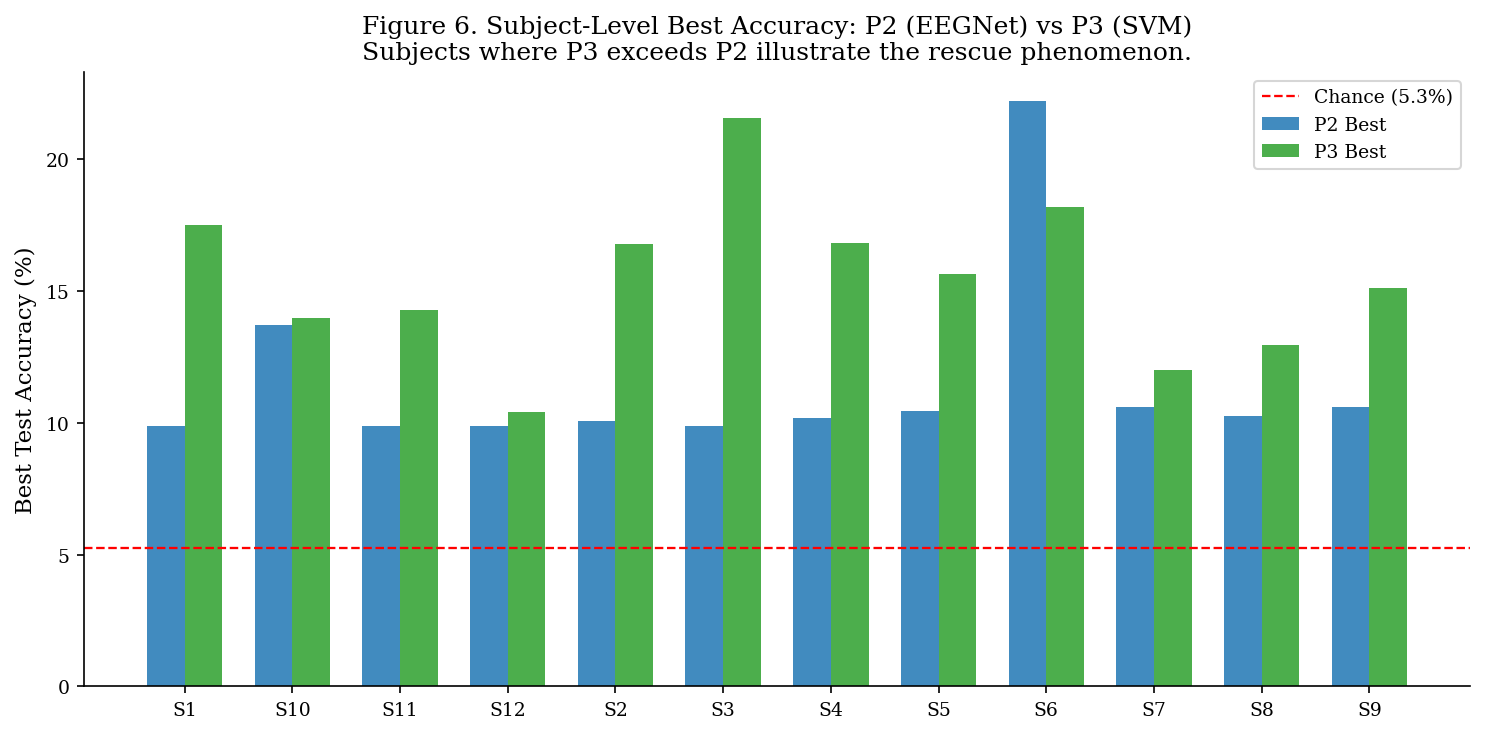

Figure 6 saved.


In [156]:
# ── IDENTIFY RESCUE SUBJECTS ─────────────────────────────────
RESCUE_THRESHOLD = CHANCE_LEVEL  # P2 "fails" if its best <= chance level

p2_by_subj = df_p2_best.set_index('subject')['accuracy']
p3_by_subj = df_p3_best.set_index('subject')['accuracy']

rescue_subjects = []
for subj in common_subjects:
    p2_acc = p2_by_subj.get(subj, 0)
    p3_acc = p3_by_subj.get(subj, 0)
    is_rescue = (p2_acc <= RESCUE_THRESHOLD + 0.01) and (p3_acc > RESCUE_THRESHOLD + 0.01)
    partial   = (p3_acc > p2_acc + 0.02)  # P3 gains >2pp over P2
    rescue_subjects.append({
        'Subject': subj,
        'P2 Best Acc (%)': round(p2_acc * 100, 3),
        'P3 Best Acc (%)': round(p3_acc * 100, 3),
        'Gain P3 over P2 (pp)': round((p3_acc - p2_acc)*100, 3),
        'P2 Status': 'Below/At Chance' if p2_acc <= RESCUE_THRESHOLD + 0.01 else 'Above Chance',
        'Rescue': 'Rescued' if is_rescue else ('P3 Leads' if partial else 'P2 Leads'),
    })

df_rescue = pd.DataFrame(rescue_subjects).sort_values('Gain P3 over P2 (pp)', ascending=False)
print("Table 8. Subject Rescue Analysis: P3 Performance vs P2 Performance")
display(df_rescue)

# ── FIGURE 5: Rescue Comparison Plot ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(common_subjects))
w = 0.35
ax.bar(x - w/2, p2_by_subj[common_subjects].values*100, w, label='P2 Best', color=C_P2, alpha=0.85)
ax.bar(x + w/2, p3_by_subj[common_subjects].values*100, w, label='P3 Best', color=C_P3, alpha=0.85)
ax.axhline(CHANCE_LEVEL*100, color='red', linestyle='--', linewidth=1.1,
           label=f'Chance ({CHANCE_LEVEL*100:.1f}%)')
ax.set_xticks(x)
ax.set_xticklabels(common_subjects, fontsize=9)
ax.set_ylabel('Best Test Accuracy (%)')
ax.set_title('Figure 6. Subject-Level Best Accuracy: P2 (EEGNet) vs P3 (SVM)\n'
             'Subjects where P3 exceeds P2 illustrate the rescue phenomenon.')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma2_subject_rescue.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6 saved.")

---

## Main Analysis 3: Ultimate Champion Model Deep-Dive

The champion model is selected **objectively** from the full pool of personalisable candidates — every Paradigm 2 (Subject-Dependent EEGNet) subject×configuration model and every Paradigm 3 (Subject-Dependent SVM) subject×configuration×feature-group model. Paradigm 1 (Global EEGNet) is *excluded* from champion contention because it is a single cross-subject model that cannot be personalised for individual deployment; it still serves as a baseline in the cross-paradigm comparison, bootstrap CI, and effect-size analyses.

Selection follows a transparent multi-criteria protocol: (1) rank all candidates by peak test accuracy and retain the top 10; (2) load each finalist's real trained artefact, run inference on its held-out test set, and compute **class coverage** — the number of the 19 syllable classes with non-zero recall; (3) **disqualify** any finalist whose coverage falls below 8/19, since a model that collapses onto one or two majority classes can attain a deceptively high accuracy purely through class imbalance rather than genuine decoding; (4) rank the survivors by **subject-paradigm mean accuracy** (consistency across the eight configurations within the same paradigm), breaking ties first by the coefficient of variation (stability) and then by the broader class coverage — deliberately preferring a model that decodes more syllable classes over one with a higher single-configuration peak. The first-ranked survivor becomes the champion. All metrics are computed directly from the real model artefacts and held-out test sets without intermediate caching.

### 3.1 Champion Declaration: Grand Summary Matrix

In [157]:
# ============================================================
# CELL 3.1: MULTI-CRITERIA CHAMPION SELECTION (objective, data-driven)
# Champion is chosen from ALL personalisable candidates:
#   every P2 subject×config model + every P3 subject×config×feature model.
#   P1 (global model) is excluded from champion contention.
# Protocol:  (1) candidate pool  (2) top-10 by peak accuracy
#            (3) class coverage (classes with recall>0, of 19)
#            (4) disqualify collapsed models (<8/19)
#            (5) rank survivors by subject-paradigm mean (CV tie-break)
#            (6) report Top 3 and declare champion.
# Every metric is computed from the real .h5/.pkl artefacts + .npy test sets.
# ============================================================

# ── Weights-subdirectory maps (exp_id -> folder name) ────────
P2_EDIR = {
    'E0':'E0_Baseline','E1':'E1_ICA_Filtering','E2':'E2_Resampling_512Hz',
    'E3':'E3_ERP_N400','E4':'E4_Channel_Language','E5':'E5_Data_Augmentation',
    'E6':'E6_CrossModality_ImaginedOnly','E7':'E7_Band_Alpha',
}
P3_EDIR = dict(P2_EDIR)

def load_champion_model_and_predict(champ_pilar, champ_subj, champ_exp, champ_feature_group=None):
    '''Load the trained artefact for any P2/P3 candidate and return
    (y_true, y_pred, model_obj, X_test).

    P2 -> EEGNet .h5 evaluated on its pre-scaled 4D Xtest.
    P3 -> SVM .pkl evaluated on its pre-scaled 2D Xtest. The Xtest_SVM_*.npy
          array is ALREADY standardised by fit_and_apply_scaler at training
          time (run_e8_classical.py), so the scaler is deliberately NOT
          re-applied here - doing so would double-standardise the features and
          corrupt the reported accuracy. The saved scaler_SVM_*.pkl exists only
          for production inference on new raw EEG.
    Raises FileNotFoundError naming the exact missing subject/config/feature
    combination so a failure is never silently skipped.'''
    if champ_pilar == 'P2':
        edir = P2_EDIR[champ_exp]
        base = WEIGHTS_P2 / edir
        m_p = base / f'{edir}_{champ_subj}.h5'
        x_p = base / f'Xtest_{edir}_{champ_subj}.npy'
        y_p = base / f'ytest_{edir}_{champ_subj}.npy'
        for fp in (m_p, x_p, y_p):
            if not fp.exists():
                raise FileNotFoundError(
                    f"[CHAMPION] Missing P2 artefact for {champ_pilar}/{champ_exp}/{champ_subj}: {fp}")
        mdl = tf.keras.models.load_model(str(m_p))
        X_t = np.load(str(x_p)); y_t = np.load(str(y_p))
        y_pred = np.argmax(mdl.predict(X_t, verbose=0), axis=1)
        return y_t, y_pred, mdl, X_t
    elif champ_pilar == 'P3':
        edir = P3_EDIR[champ_exp]; fg = champ_feature_group
        base = WEIGHTS_P3 / edir
        m_p = base / f'SVM_{fg}_{edir}_{champ_subj}.pkl'
        x_p = base / f'Xtest_SVM_{fg}_{edir}_{champ_subj}.npy'
        y_p = base / f'ytest_SVM_{fg}_{edir}_{champ_subj}.npy'
        for fp in (m_p, x_p, y_p):
            if not fp.exists():
                raise FileNotFoundError(
                    f"[CHAMPION] Missing P3 artefact for {champ_pilar}/{champ_exp}/{champ_subj}/{fg}: {fp}")
        svm = joblib.load(str(m_p))
        X_t = np.load(str(x_p)); y_t = np.load(str(y_p))
        if X_t.ndim != 2:
            X_t = X_t.reshape(X_t.shape[0], -1)
        y_pred = svm.predict(X_t)          # Xtest already scaled -> no re-scaling
        return y_t, y_pred, svm, X_t
    raise ValueError(f"Unknown paradigm '{champ_pilar}' (expected 'P2' or 'P3').")

def _class_coverage(y_true, y_pred):
    '''Count distinct classes (of 19) with recall > 0, and return per-class recall.'''
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    per_class = {k: v['recall'] for k, v in rep.items()
                 if isinstance(v, dict) and k not in ('accuracy','macro avg','weighted avg')}
    coverage = int(sum(1 for r in per_class.values() if r > 0))
    return coverage, per_class

# ── STEP 1: candidate pool (P2 + P3; P1 excluded) ────────────
cand_p2 = df_p2_all[['exp_id','subject','accuracy']].assign(pilar='P2', feature_group=None)
cand_p3 = df_p3_all[['exp_id','subject','feature_group','accuracy']].assign(pilar='P3')
candidates = pd.concat([cand_p2, cand_p3], ignore_index=True)
print(f"[STEP 1] Candidate pool: {len(cand_p2)} P2 + {len(cand_p3)} P3 = "
      f"{len(candidates)} personalisable models (P1 excluded as a global model).")

# ── STEP 2: top-10 by peak accuracy ──────────────────────────
TOP_N = 10
top_cands = candidates.sort_values('accuracy', ascending=False).head(TOP_N).reset_index(drop=True)
print(f"\n[STEP 2] Top-{TOP_N} finalists by peak accuracy:")
display(top_cands.assign(**{'Peak Acc (%)': (top_cands['accuracy']*100).round(3),
                            'Feature Group': top_cands['feature_group'].fillna('-')})
        [['pilar','subject','exp_id','Feature Group','Peak Acc (%)']]
        .rename(columns={'pilar':'Paradigm','subject':'Subject','exp_id':'Config'}))

# ── STEP 3: class coverage for each finalist (real inference) ─
CLASS_COVERAGE_THRESHOLD = 8
cov_rows, champ_pred_cache = [], {}
print(f"\n[STEP 3] Computing class coverage for the {len(top_cands)} finalists...")
for _, r in top_cands.iterrows():
    fg = None if r['pilar'] == 'P2' else r['feature_group']
    y_t, y_p, _, _ = load_champion_model_and_predict(r['pilar'], r['subject'], r['exp_id'], fg)
    cov, _per = _class_coverage(y_t, y_p)
    champ_pred_cache[(r['pilar'], r['subject'], r['exp_id'], fg)] = (y_t, y_p)
    cov_rows.append({**r.to_dict(), 'class_coverage': cov, 'n_test': int(len(y_t))})
cov_df = pd.DataFrame(cov_rows)

# ── STEP 4: disqualify collapsed models ──────────────────────
cov_df['qualified'] = cov_df['class_coverage'] >= CLASS_COVERAGE_THRESHOLD
disq = cov_df[~cov_df['qualified']]
qual = cov_df[cov_df['qualified']].copy()
print(f"\n[STEP 4] Class-coverage gate (>= {CLASS_COVERAGE_THRESHOLD}/19 classes):")
if len(disq):
    print("  Disqualified (model collapses onto a few majority classes):")
    for _, r in disq.iterrows():
        tag = f"{r['pilar']}/{r['exp_id']}/{r['subject']}" + (f"/{r['feature_group']}" if r['pilar']=='P3' else "")
        print(f"    - {tag:<32} coverage {int(r['class_coverage']):>2}/19  "
              f"(peak {r['accuracy']*100:5.2f}%, n_test={int(r['n_test'])})  -> REJECTED")
else:
    print("  None disqualified — all finalists cover >= threshold classes.")
if qual.empty:
    raise RuntimeError(
        f"[CHAMPION] No finalist passed the class-coverage gate (>= {CLASS_COVERAGE_THRESHOLD}/19). "
        "Inspect the top-10 coverage table above; lowering CLASS_COVERAGE_THRESHOLD may be warranted.")

# ── STEP 5: attach subject-paradigm mean + CV, then rank ─────
def _subject_paradigm_stats(pilar, subj):
    '''Mean accuracy (%) and CV of a subject across the configs within its paradigm.
    P2 uses the subject x config matrix (Table 3b); P3 uses the per-subject
    statistics table (T17_p3_per_subject_stats).'''
    if pilar == 'P2':
        row = pivot_p2_subj.loc[subj].dropna()
        m = float(row.mean())
        cv = float(row.std() / row.mean()) if row.mean() else float('nan')
        return m, cv
    m  = float(p3_subj_stats.loc[subj, 'Mean (%)'])
    cv = float(p3_subj_stats.loc[subj, 'CV'])
    return m, cv

qual[['sp_mean','sp_cv']] = qual.apply(
    lambda r: pd.Series(_subject_paradigm_stats(r['pilar'], r['subject'])), axis=1)

import functools
def _champ_cmp(a, b):
    # Primary: higher subject-paradigm mean. If within 0.5 pp -> lower CV (more stable).
    # If CV also ties -> broader class coverage wins (prefer a model that decodes more of
    # the 19 classes over a higher single-config peak). Final fallback -> higher peak accuracy.
    if abs(a['sp_mean'] - b['sp_mean']) < 0.5:
        if a['sp_cv'] != b['sp_cv']:
            return -1 if a['sp_cv'] < b['sp_cv'] else 1
        if a['class_coverage'] != b['class_coverage']:
            return -1 if a['class_coverage'] > b['class_coverage'] else 1
        return -1 if a['accuracy'] > b['accuracy'] else 1
    return -1 if a['sp_mean'] > b['sp_mean'] else 1
qual_sorted = sorted(qual.to_dict('records'), key=functools.cmp_to_key(_champ_cmp))

# ── STEP 6: Top 3 report + declare champion ──────────────────
def _cfg_label(r):
    return (f"{r['pilar']}/{r['exp_id']}/{r['subject']}"
            + (f"/{r['feature_group']}" if r['pilar']=='P3' else ""))
top3_tbl = pd.DataFrame([{
    'Paradigm':      r['pilar'],
    'Subject':       r['subject'],
    'Config':        EXP_LABELS[r['exp_id']],
    'Feature Group': (FEAT_LABELS.get(r['feature_group'],'-') if r['pilar']=='P3' else '-'),
    'Peak Acc (%)':  round(r['accuracy']*100, 3),
    'Subj-Paradigm Mean (%)': round(r['sp_mean'], 3),
    'CV':            round(r['sp_cv'], 4),
    'Class Coverage': f"{int(r['class_coverage'])}/19",
} for r in qual_sorted[:3]])
print("\nTable 9b. Top 3 Champion Candidates "
      "(ranked by subject-paradigm mean accuracy; CV as stability tie-break)")
display(top3_tbl.set_index('Paradigm'))

champ = qual_sorted[0]
CHAMP_PILAR = champ['pilar']
CHAMP_SUBJ  = champ['subject']
CHAMP_EXP   = champ['exp_id']
CHAMP_FEATURE_GROUP = champ['feature_group'] if CHAMP_PILAR == 'P3' else None
CHAMP_TAG = (f"{CHAMP_PILAR}/{CHAMP_EXP}/{CHAMP_SUBJ}"
             + (f"/{CHAMP_FEATURE_GROUP}" if CHAMP_PILAR == 'P3' else ""))
n_qualified = len(qual_sorted)

_feat_str = (' feature=' + str(CHAMP_FEATURE_GROUP)) if CHAMP_PILAR == 'P3' else ''
print(f"\nChampion: {_cfg_label(champ)}{_feat_str}.")
print(f"  Selected from {n_qualified} qualified candidate(s) (of top-{TOP_N} by peak accuracy) "
      f"by highest subject-paradigm mean accuracy ({champ['sp_mean']:.3f}%); ties broken by "
      f"lower CV, then broader class coverage ({int(champ['class_coverage'])}/19). "
      f"All qualified candidates have coverage >= {CLASS_COVERAGE_THRESHOLD}/19 classes.")

# ── LOAD CHAMPION + GRAND SUMMARY MATRIX ─────────────────────
y_champ, y_pred_champ, model_champ, X_champ = load_champion_model_and_predict(
    CHAMP_PILAR, CHAMP_SUBJ, CHAMP_EXP, CHAMP_FEATURE_GROUP)
champ_labels = sorted(np.unique(y_champ).tolist())
n_cls        = len(champ_labels)

champ_acc   = float(accuracy_score(y_champ, y_pred_champ))
champ_f1    = float(f1_score(y_champ, y_pred_champ, average='weighted', zero_division=0))
champ_prec  = float(precision_score(y_champ, y_pred_champ, average='weighted', zero_division=0))
champ_rec   = float(recall_score(y_champ, y_pred_champ, average='weighted', zero_division=0))
champ_kappa = float(cohen_kappa_score(y_champ, y_pred_champ))
champ_coverage = int(champ['class_coverage'])

CHAMP_PARADIGM_NAME = ('P2 Subject-Dependent EEGNet' if CHAMP_PILAR == 'P2'
                       else 'P3 Subject-Dependent SVM')
CHAMP_CONFIG_LABEL  = EXP_LABELS[CHAMP_EXP] + (
    f' + {FEAT_LABELS[CHAMP_FEATURE_GROUP]}' if CHAMP_PILAR == 'P3' else '')
C_CHAMP = C_P2 if CHAMP_PILAR == 'P2' else C_P3

grand_matrix = pd.DataFrame([{
    'Paradigm':           CHAMP_PARADIGM_NAME,
    'Configuration':      CHAMP_CONFIG_LABEL,
    'Champion Subject':   CHAMP_SUBJ,
    'Test Accuracy (%)':  round(champ_acc*100, 4),
    'F1-Weighted':        round(champ_f1, 4),
    'Precision-Weighted': round(champ_prec, 4),
    'Recall-Weighted':    round(champ_rec, 4),
    "Cohen's Kappa":      round(champ_kappa, 4),
    'Class Coverage':     f'{champ_coverage}/19',
    'Chance Level (%)':   round(CHANCE_LEVEL*100, 4),
    'Gain over Chance (pp)': round((champ_acc - CHANCE_LEVEL)*100, 4),
}])
print(f"\nTable 9. Grand Summary Matrix - Champion Model ({_cfg_label(champ)})")
display(grand_matrix.T.rename(columns={0:'Value'}))
print(f"\nNote: Chance level = 1/{n_cls} classes = {CHANCE_LEVEL*100:.2f}%")

[STEP 1] Candidate pool: 96 P2 + 480 P3 = 576 personalisable models (P1 excluded as a global model).

[STEP 2] Top-10 finalists by peak accuracy:


,Paradigm,Subject,Config,Feature Group,Peak Acc (%)
0,P2,S6,E6,-,22.222
1,P3,S3,E6,barlow,21.591
2,P3,S3,E6,hjorth,19.318
3,P3,S6,E3,band_ratio,18.182
4,P3,S3,E5,barlow,18.095
5,P3,S3,E2,barlow,18.095
6,P3,S3,E0,barlow,17.619
7,P3,S1,E6,barlow,17.526
8,P3,S4,E6,all,16.832
9,P3,S2,E2,barlow,16.807



[STEP 3] Computing class coverage for the 10 finalists...

[STEP 4] Class-coverage gate (>= 8/19 classes):
  Disqualified (model collapses onto a few majority classes):
    - P2/E6/S6                         coverage  4/19  (peak 22.22%, n_test=18)  -> REJECTED
    - P3/E3/S6/band_ratio              coverage  3/19  (peak 18.18%, n_test=22)  -> REJECTED

Table 9b. Top 3 Champion Candidates (ranked by subject-paradigm mean accuracy; CV as stability tie-break)


,Subject,Config,Feature Group,Peak Acc (%),Subj-Paradigm Mean (%),CV,Class Coverage
Paradigm,,,,,,,
P3,S3,E5 Augmentation,Barlow Params,18.095,9.978,0.4413,18/19
P3,S3,E2 Resample 512Hz,Barlow Params,18.095,9.978,0.4413,17/19
P3,S3,E0 Baseline,Barlow Params,17.619,9.978,0.4413,17/19



Champion: P3/E5/S3/barlow feature=barlow.
  Selected from 8 qualified candidate(s) (of top-10 by peak accuracy) by highest subject-paradigm mean accuracy (9.978%); ties broken by lower CV, then broader class coverage (18/19). All qualified candidates have coverage >= 8/19 classes.

Table 9. Grand Summary Matrix - Champion Model (P3/E5/S3/barlow)


,Value
Paradigm,P3 Subject-Dependent SVM
Configuration,E5 Augmentation + Barlow Params
Champion Subject,S3
Test Accuracy (%),18.0952
F1-Weighted,0.1801
Precision-Weighted,0.1967
Recall-Weighted,0.181
Cohen's Kappa,0.1326
Class Coverage,18/19
Chance Level (%),5.2632



Note: Chance level = 1/19 classes = 5.26%


### 3.2 Biological Plausibility: Per-Class Recall Analysis

Per-class recall characterises which syllable categories the champion model decodes most reliably. The biological plausibility hypothesis predicts that syllables with strong bilabial articulatory signatures (e.g., those involving lip contact) will exhibit higher recall owing to their distinct oro-facial muscle activation patterns that may be partially reflected in frontal EEG channels.

Table 10. Per-Class Classification Report – Champion Model (P3/E5/S3/barlow)


,Precision,Recall,F1-Score,Support
Syllable,,,,
MA,0.2105,0.3333,0.2581,12.0
KAN,0.3750,0.3000,0.3333,10.0
MI,0.2353,0.3636,0.2857,11.0
NUM,0.1111,0.1111,0.1111,9.0
BE,0.1111,0.0909,0.1000,11.0
RAK,0.1875,0.2727,0.2222,11.0
PI,0.2222,0.1818,0.2000,11.0
PIS,0.0000,0.0000,0.0000,11.0
MAN,0.3333,0.1818,0.2353,11.0



Top 3 syllables by recall:


,Precision,Recall,F1-Score,Support
Syllable,,,,
MI,0.2353,0.3636,0.2857,11.0
MA,0.2105,0.3333,0.2581,12.0
KAN,0.3750,0.3000,0.3333,10.0


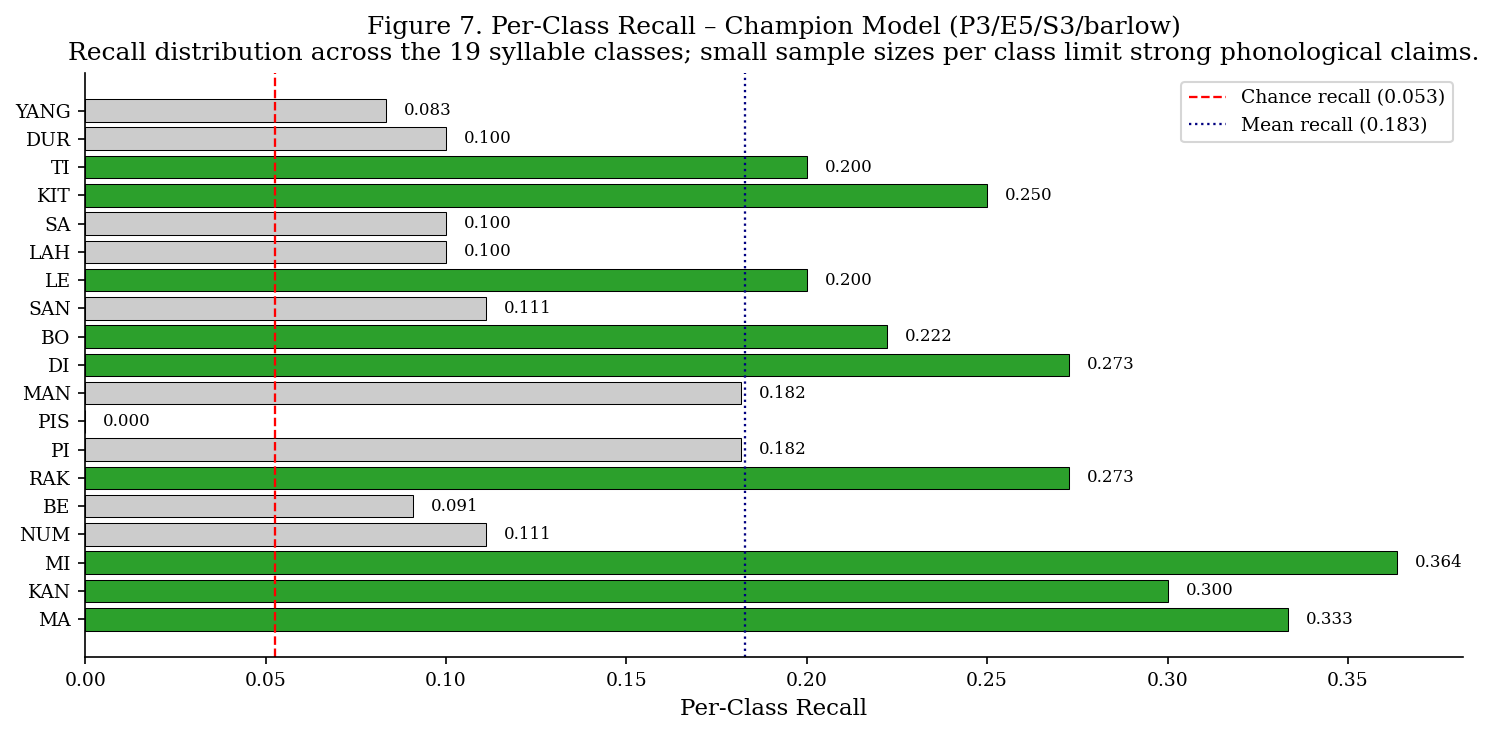

Figure 7 saved.


In [158]:
# ── PER-CLASS RECALL ─────────────────────────────────────────
# Use SYLLABLE_MAP (defined in Cell 1) for correct 19-class labels.
class_names  = [SYLLABLE_MAP.get(i, f'Class_{i}') for i in champ_labels]
label_map    = {lab: SYLLABLE_MAP.get(lab, f'Class_{lab}') for lab in champ_labels}
y_true_named = np.array([label_map[l] for l in y_champ])
y_pred_named = np.array([label_map.get(l, f'Class_{l}') for l in y_pred_champ])

report_dict = classification_report(y_true_named, y_pred_named,
                                     output_dict=True, zero_division=0)
per_class_df = pd.DataFrame(report_dict).T
# Keep only the actual syllable rows (drop accuracy/macro avg/weighted avg rows)
class_names = [c for c in class_names if c in per_class_df.index]
per_class_df = per_class_df.loc[class_names]
per_class_df.index.name = 'Syllable'
per_class_df = per_class_df[['precision','recall','f1-score','support']].round(4)
per_class_df.columns = ['Precision','Recall','F1-Score','Support']

print(f"Table 10. Per-Class Classification Report – Champion Model ({CHAMP_TAG})")
display(per_class_df)

# Highlight top performers
top3 = per_class_df.sort_values('Recall', ascending=False).head(3)
print(f"\nTop 3 syllables by recall:")
display(top3)

# ── FIGURE 6: Per-Class Recall Bar Chart ─────────────────────
recalls = per_class_df['Recall'].values
fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = [C_CHAMP if r >= np.mean(recalls) else '#cccccc' for r in recalls]
ax.barh(class_names, recalls, color=colors_bar, edgecolor='black', linewidth=0.5)
ax.axvline(1.0/n_cls, color='red', linestyle='--', linewidth=1.1,
           label=f'Chance recall ({1/n_cls:.3f})')
ax.axvline(np.mean(recalls), color='navy', linestyle=':', linewidth=1.1,
           label=f'Mean recall ({np.mean(recalls):.3f})')
ax.set_xlabel('Per-Class Recall')
ax.set_title(f'Figure 7. Per-Class Recall – Champion Model ({CHAMP_TAG})\n'
             'Recall distribution across the 19 syllable classes; small sample sizes per class limit strong phonological claims.')
ax.legend(fontsize=9)
for i, (r, lbl) in enumerate(zip(recalls, class_names)):
    ax.text(r + 0.005, i, f'{r:.3f}', va='center', fontsize=8)
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma3_champion_per_class_recall.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7 saved.")

### 3.3 Error Analysis: Confusion Matrix and Off-Diagonal Mass

The confusion matrix delineates the specific misclassification patterns of the champion model. The Off-Diagonal Mass (ODM) quantifies the fraction of predictions assigned to incorrect classes and is complementary to accuracy: ODM = 1 - Accuracy.

Table 11. Confusion Matrix Summary – Champion Model
  Test samples: 210
  Overall Accuracy: 18.095%
  Off-Diagonal Mass (ODM): 81.905%

Normalized Confusion Matrix (row = true class, col = predicted class):


,MA,KAN,MI,NUM,BE,RAK,PI,PIS,MAN,DI,BO,SAN,LE,LAH,SA,KIT,TI,DUR,YANG
MA,0.333,0.000,0.167,0.083,0.000,0.083,0.083,0.000,0.000,0.083,0.000,0.000,0.000,0.000,0.083,0.000,0.0,0.000,0.083
KAN,0.100,0.300,0.100,0.000,0.000,0.100,0.100,0.000,0.100,0.000,0.000,0.100,0.000,0.000,0.000,0.100,0.0,0.000,0.000
MI,0.000,0.000,0.364,0.091,0.000,0.091,0.000,0.000,0.000,0.000,0.000,0.091,0.273,0.000,0.000,0.091,0.0,0.000,0.000
NUM,0.000,0.000,0.333,0.111,0.000,0.111,0.000,0.000,0.000,0.000,0.000,0.222,0.000,0.000,0.222,0.000,0.0,0.000,0.000
BE,0.091,0.091,0.000,0.091,0.091,0.182,0.000,0.000,0.000,0.000,0.000,0.091,0.091,0.091,0.091,0.000,0.0,0.000,0.091
RAK,0.000,0.182,0.091,0.000,0.000,0.273,0.000,0.091,0.000,0.000,0.000,0.000,0.182,0.091,0.000,0.000,0.0,0.000,0.091
PI,0.273,0.000,0.000,0.182,0.000,0.000,0.182,0.000,0.091,0.000,0.000,0.000,0.000,0.000,0.182,0.091,0.0,0.000,0.000
PIS,0.091,0.000,0.000,0.000,0.000,0.000,0.091,0.000,0.000,0.000,0.182,0.000,0.091,0.273,0.000,0.182,0.0,0.000,0.091
MAN,0.000,0.000,0.000,0.000,0.182,0.000,0.000,0.091,0.182,0.273,0.000,0.000,0.091,0.091,0.091,0.000,0.0,0.000,0.000
DI,0.091,0.000,0.000,0.091,0.000,0.091,0.091,0.000,0.000,0.273,0.000,0.091,0.000,0.000,0.091,0.091,0.0,0.000,0.091


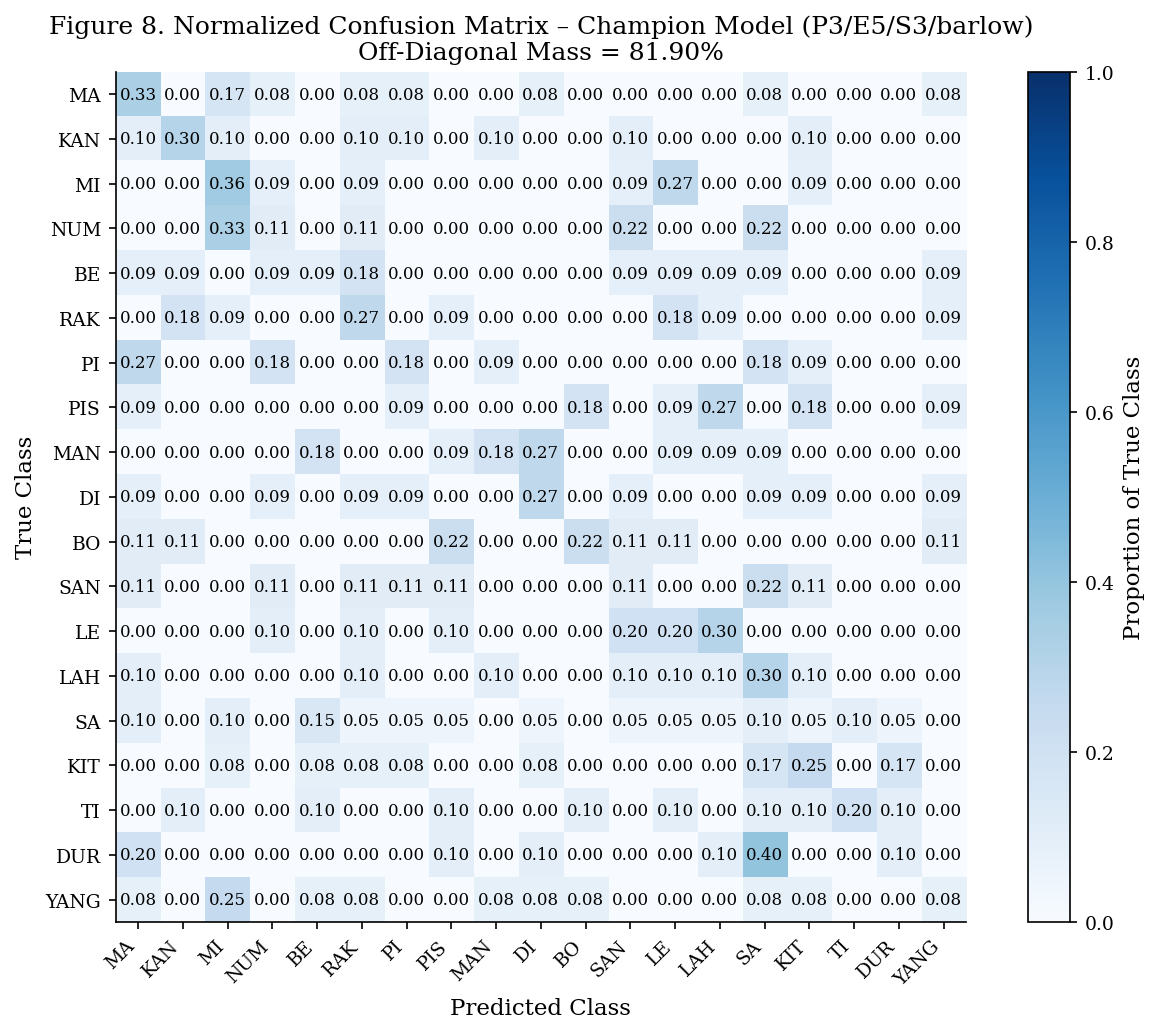

Figure 8 saved.


In [159]:
# ── CONFUSION MATRIX ─────────────────────────────────────────
cm       = confusion_matrix(y_true_named, y_pred_named, labels=class_names)
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm  = cm.astype(float) / np.where(row_sums > 0, row_sums, 1)

odm = 1.0 - champ_acc
n_test_champ = len(y_champ)

print(f"Table 11. Confusion Matrix Summary – Champion Model")
print(f"  Test samples: {n_test_champ}")
print(f"  Overall Accuracy: {champ_acc*100:.3f}%")
print(f"  Off-Diagonal Mass (ODM): {odm*100:.3f}%")
print(f"\nNormalized Confusion Matrix (row = true class, col = predicted class):")
display(pd.DataFrame(cm_norm, index=class_names, columns=class_names).round(3))

# ── FIGURE 7: Confusion Matrix Heatmap ───────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(n_cls)); ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticks(range(n_cls)); ax.set_yticklabels(class_names)
for i in range(n_cls):
    for j in range(n_cls):
        val = cm_norm[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                color='white' if val > 0.5 else 'black', fontsize=8)
fig.colorbar(im, ax=ax, label='Proportion of True Class')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
ax.set_title(f'Figure 8. Normalized Confusion Matrix – Champion Model ({CHAMP_TAG})\n'
             f'Off-Diagonal Mass = {odm*100:.2f}%')
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma3_champion_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 8 saved.")

### 3.4 Explainable Artificial Intelligence and Neurological Plausibility

The attribution method is chosen to match the champion paradigm:

- **If the champion is Paradigm 2 (EEGNet)**, SHAP (SHapley Additive exPlanations) via `GradientExplainer` identifies the relative importance of each EEG channel. The Frontal Dominance Ratio (FDR) and N400 Area Under the Curve (AUC) then confirm whether the decision is driven by genuine neural language processing rather than artefactual sources (e.g. eye blinks, muscular noise).
- **If the champion is Paradigm 3 (SVM)**, gradient-based SHAP is not applicable (the SVM operates on handcrafted features, not raw channel×time tensors). Instead, `sklearn.inspection.permutation_importance` (n_repeats=30, fixed seed) ranks the handcrafted features by the accuracy drop incurred when each is randomly permuted. This is **conceptually** comparable to the SHAP channel ranking — both reveal which inputs the model relies on — but the magnitudes are **not** directly comparable number-to-number, because permutation importance measures a performance decrement whereas SHAP measures an additive contribution to the output.

Champion is P3 (SVM). SHAP GradientExplainer is not applicable to a handcrafted-feature SVM; using permutation_importance (n_repeats=30) instead.

Table 12. Permutation Importance – Champion Model (P3/E5/S3/barlow)
  Method: permutation_importance (accuracy drop under feature permutation, n_repeats=30)


,Feature,Mean Importance,Std Importance,Rank
0,O1_freq,0.051746,0.017593,1
1,O1_amp,0.051746,0.015095,2
2,F3_freq,0.040476,0.014690,3
3,P7_amp,0.037619,0.014462,4
4,AF3_freq,0.036825,0.015005,5
5,T8_amp,0.036508,0.012619,6
6,F7_freq,0.036032,0.013893,7
7,FC5_freq,0.035714,0.012703,8
8,O2_amp,0.034921,0.013487,9
9,T7_freq,0.034762,0.012366,10


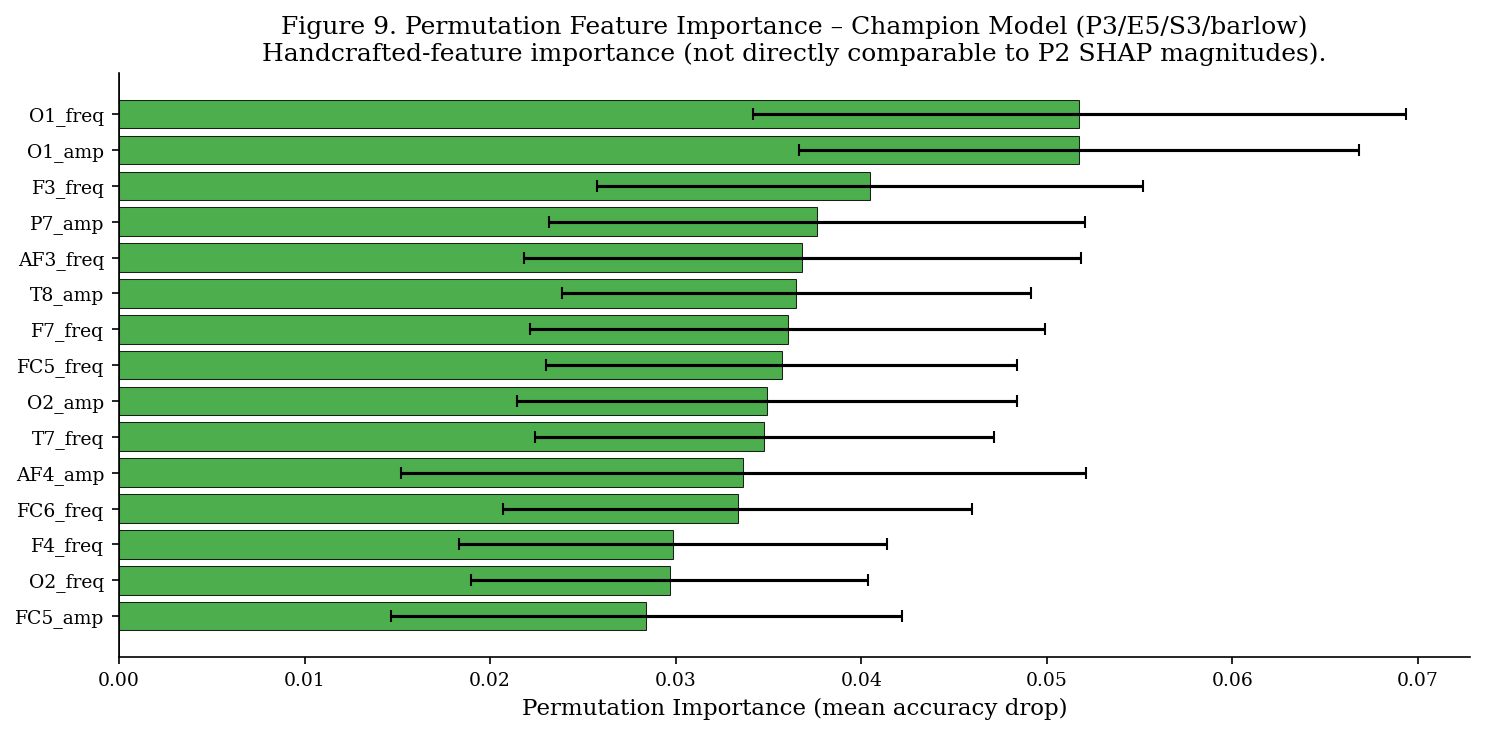

Figure 9 saved (permutation importance).

Note: Permutation importance measures the accuracy decrement when a feature is randomly shuffled. It is conceptually — not numerically — comparable to the SHAP channel ranking used for a P2 champion.


In [160]:
# ============================================================
# CELL 3.4: CHAMPION EXPLAINABILITY
#   P2 (EEGNet) -> SHAP GradientExplainer + FDR + N400 temporal AUC
#   P3 (SVM)    -> permutation_importance on handcrafted features
# Sentinel defaults are set first so the export pipeline never fails
# regardless of which paradigm wins.
# ============================================================

# ── Sentinel defaults (paradigm-agnostic) ───────────────────
shap_table = None      # P2 channel-importance table
perm_table = None      # P3 permutation-importance table
n400_table = None      # P2 temporal-AUC table
xai_method = 'SHAP GradientExplainer' if CHAMP_PILAR == 'P2' else 'permutation_importance'
fdr = float('nan')
n400_auc = float('nan')
n400_auc_e0 = None
total_auc_e0 = None
n400_ratio_e0 = None
n400_auc_champ = None
n400_ratio_champ = None

if CHAMP_PILAR == 'P2':
    # ========================================================
    # P2 BRANCH: SHAP CHANNEL IMPORTANCE + FDR + N400 AUC
    # ========================================================
    import shap

    n_background = min(20, len(X_champ))
    n_explain    = min(30, len(X_champ))
    print(f"Champion is P2 (EEGNet). Computing SHAP GradientExplainer values "
          f"({n_explain} samples; {n_background} background)...")
    print("This computation may require 60-180 seconds depending on hardware.")

    bg_data  = X_champ[:n_background].astype(np.float32)
    exp_data = X_champ[:n_explain].astype(np.float32)
    explainer = shap.GradientExplainer(model_champ, bg_data)
    shap_raw  = explainer.shap_values(exp_data)
    shap_array = np.stack(shap_raw, axis=-1) if isinstance(shap_raw, list) else shap_raw
    print(f"SHAP values shape: {shap_array.shape}")

    # Per-channel importance: mean(|shap|) over samples, time, depth, classes
    channel_importance = np.mean(np.abs(shap_array), axis=(0, 2, 3, 4))
    n_ch = channel_importance.shape[0]
    # E4 uses only the five language channels; all other configs use all 14
    ch_names = (['F7','F3','FC5','T7','P7'] if CHAMP_EXP == 'E4' else EMOTIV_CH)[:n_ch]

    eye_idx  = [i for i, c in enumerate(ch_names) if c in ('AF3','AF4')]
    lang_idx = [i for i, c in enumerate(ch_names) if c in ('F7','F3','FC5','T7','FC6','F4','F8')]
    fdr = (float(np.mean(channel_importance[eye_idx]) /
                 np.mean(channel_importance[lang_idx])) if eye_idx and lang_idx else float('nan'))

    shap_table = pd.DataFrame({
        'Channel': ch_names,
        'Mean |SHAP|': channel_importance.round(6),
        'Region': [('Frontal/Eye' if c in ('AF3','AF4') else
                    'Language/Motor' if c in ('F7','F3','FC5','T7','FC6','F4','F8') else
                    'Posterior') for c in ch_names],
        'Rank': pd.Series(channel_importance).rank(ascending=False).astype(int).values,
    }).sort_values('Mean |SHAP|', ascending=False)
    print(f"\nTable 12. SHAP Channel Importance – Champion Model ({CHAMP_TAG})")
    display(shap_table)
    _fdr_str = f"{fdr:.4f}" if fdr == fdr else "N/A"
    print(f"\nFrontal Dominance Ratio (FDR) = Eye channels / Language-Motor channels = {_fdr_str}")
    if fdr == fdr:
        print(f"  Interpretation: {'Neuro-plausible (FDR < 1: language cortex dominates eye-blink channels)' if fdr < 1 else 'Elevated frontal (eye) activity detected.'}")

    # ── FIGURE 9: SHAP Channel Heatmap ───────────────────────
    fig, ax = plt.subplots(figsize=(10, 4))
    sorted_idx = np.argsort(channel_importance)[::-1]
    sorted_ch  = [ch_names[i] for i in sorted_idx]
    sorted_imp = channel_importance[sorted_idx]
    region_col = {'Language/Motor': C_P2, 'Posterior': C_P3, 'Frontal/Eye': C_P1}
    bar_colors = [region_col.get('Frontal/Eye' if c in ('AF3','AF4') else
                                 'Language/Motor' if c in ('F7','F3','FC5','T7','FC6','F4','F8') else
                                 'Posterior', '#aaaaaa') for c in sorted_ch]
    ax.bar(sorted_ch, sorted_imp, color=bar_colors, edgecolor='black', linewidth=0.5)
    ax.legend(handles=[mpatches.Patch(color=v, label=k) for k, v in region_col.items()], fontsize=9)
    ax.set_xlabel('EEG Channel'); ax.set_ylabel('Mean |SHAP| Value')
    ax.set_title(f'Figure 9. SHAP Channel Importance – Champion Model ({CHAMP_TAG})\n'
                 f'FDR = {_fdr_str}: Language/Motor channels vs frontal (eye-blink) contribution.')
    fig.tight_layout()
    fig.savefig(str(OUTPUT_DIR / 'ma3_shap_channel_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure 9 saved.")

    # ── N400 TEMPORAL AUC (generalised for any P2 configuration) ──
    fs_hz = 512 if CHAMP_EXP == 'E2' else 256   # E2 resamples to 512 Hz
    T_champ = X_champ.shape[2]
    mean_erp_champ = np.mean(X_champ[:, :, :, 0], axis=0)     # (C, T)
    mean_abs_erp   = np.mean(np.abs(mean_erp_champ), axis=0)  # (T,)

    if CHAMP_EXP == 'E3':
        # Epoch is already pre-cropped to the 200-600 ms N400 window
        time_ms = np.linspace(200, 600, T_champ)
        n400_auc_champ = float(np.trapezoid(mean_abs_erp, time_ms))
        total_auc_champ = n400_auc_champ
        n400_ratio_champ = 100.0
        champ_cfg_desc = f'{EXP_LABELS[CHAMP_EXP]} (Champion, epoch IS 200-600ms)'
        total_disp = '= N400 AUC (epoch IS 200-600ms)'
        ratio_disp = '100.0 (by design)'
    else:
        # Full-window epoch: measure the 200-600 ms N400 sub-window vs total
        time_ms = np.linspace(0, T_champ / fs_hz * 1000, T_champ)
        total_auc_champ = float(np.trapezoid(mean_abs_erp, time_ms))
        n400_s, n400_e = int(0.200 * fs_hz), int(0.600 * fs_hz)
        if T_champ > n400_e:
            n400_auc_champ = float(np.trapezoid(mean_abs_erp[n400_s:n400_e], time_ms[n400_s:n400_e]))
            n400_ratio_champ = n400_auc_champ / total_auc_champ * 100.0
        else:
            n400_auc_champ = total_auc_champ
            n400_ratio_champ = 100.0
        champ_cfg_desc = f'{EXP_LABELS[CHAMP_EXP]} (Champion, full window)'
        total_disp = round(total_auc_champ, 4)
        ratio_disp = round(n400_ratio_champ, 2)
    n400_auc = n400_auc_champ   # backward-compatible alias for downstream/export

    # E0 full-window reference for the same subject
    x_e0_path = WEIGHTS_P2 / 'E0_Baseline' / f'Xtest_E0_Baseline_{CHAMP_SUBJ}.npy'
    if x_e0_path.exists():
        X_e0 = np.load(str(x_e0_path))
        T_full = X_e0.shape[2]
        time_ms_full = np.linspace(0, T_full / 256 * 1000, T_full)
        mean_erp_e0  = np.mean(X_e0[:, :, :, 0], axis=0)
        s0, e0 = int(0.200 * 256), int(0.600 * 256)
        if T_full > e0:
            n400_auc_e0  = float(np.trapezoid(np.mean(np.abs(mean_erp_e0[:, s0:e0]), axis=0),
                                              time_ms_full[s0:e0]))
            total_auc_e0 = float(np.trapezoid(np.mean(np.abs(mean_erp_e0), axis=0), time_ms_full))
            n400_ratio_e0 = n400_auc_e0 / total_auc_e0 * 100.0

    n400_table = pd.DataFrame({
        'Configuration': [champ_cfg_desc, 'E0 Baseline (Reference)'],
        'N400 AUC (200-600ms)': [round(n400_auc_champ, 4),
                                 round(n400_auc_e0, 4) if n400_auc_e0 else 'N/A'],
        'Total Epoch AUC': [total_disp, round(total_auc_e0, 4) if total_auc_e0 else 'N/A'],
        'N400 Ratio (%)': [ratio_disp, round(n400_ratio_e0, 2) if n400_ratio_e0 else 'N/A'],
    })
    print("\nTable 13. N400 Temporal AUC Analysis")
    display(n400_table)
    _ratio_str = f"{n400_ratio_e0:.2f}%" if n400_ratio_e0 is not None else "N/A"
    print(f"\nConclusion: Champion N400-window AUC = {n400_auc_champ:.4f}; "
          f"E0 baseline N400 ratio = {_ratio_str} of the full epoch.")

else:
    # ========================================================
    # P3 BRANCH: PERMUTATION IMPORTANCE ON HANDCRAFTED FEATURES
    # (gradient SHAP is not applicable to an SVM on 2D features)
    # ========================================================
    from sklearn.inspection import permutation_importance
    print(f"Champion is P3 (SVM). SHAP GradientExplainer is not applicable to a "
          f"handcrafted-feature SVM; using permutation_importance (n_repeats=30) instead.")

    # Reconstruct human-readable feature names from the champion feature group.
    FEAT_PER_CH  = {'time':4,'hjorth':3,'barlow':2,'band_ratio':3,'all':12}
    FEAT_SUBNAMES = {
        'time':      ['mean','var','skew','kurt'],
        'hjorth':    ['activity','mobility','complexity'],
        'barlow':    ['amp','freq'],
        'band_ratio':['alpha/theta','beta/alpha','gamma/beta'],
        'all':       ['mean','var','skew','kurt','activity','mobility','complexity',
                      'amp','freq','alpha/theta','beta/alpha','gamma/beta'],
    }
    n_features = X_champ.shape[1]
    ch_used = ['F7','F3','FC5','T7','P7'] if CHAMP_EXP == 'E4' else EMOTIV_CH
    fpc = FEAT_PER_CH.get(CHAMP_FEATURE_GROUP)
    if fpc and n_features % fpc == 0 and n_features // fpc == len(ch_used):
        subnames  = FEAT_SUBNAMES[CHAMP_FEATURE_GROUP]
        feat_names = [f"{ch}_{sn}" for ch in ch_used for sn in subnames]   # channel-major order
    else:
        print(f"[WARNING] Feature layout ({n_features} features) does not match "
              f"{len(ch_used)} channels x {fpc}/ch for group '{CHAMP_FEATURE_GROUP}'; "
              f"falling back to generic feature indices.")
        feat_names = [f"feat_{i}" for i in range(n_features)]

    perm = permutation_importance(model_champ, X_champ, y_champ,
                                  n_repeats=30, random_state=42, scoring='accuracy')
    perm_table = (pd.DataFrame({
        'Feature': feat_names,
        'Mean Importance': perm.importances_mean.round(6),
        'Std Importance':  perm.importances_std.round(6),
    }).sort_values('Mean Importance', ascending=False).reset_index(drop=True))
    perm_table['Rank'] = range(1, len(perm_table) + 1)
    print(f"\nTable 12. Permutation Importance – Champion Model ({CHAMP_TAG})")
    print(f"  Method: {xai_method} (accuracy drop under feature permutation, n_repeats=30)")
    display(perm_table.head(20))

    # ── FIGURE 9: Permutation Importance (top 15) ────────────
    topk = perm_table.head(15).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(topk['Feature'], topk['Mean Importance'], xerr=topk['Std Importance'],
            color=C_P3, edgecolor='black', linewidth=0.5, capsize=3, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Permutation Importance (mean accuracy drop)')
    ax.set_title(f'Figure 9. Permutation Feature Importance – Champion Model ({CHAMP_TAG})\n'
                 f'Handcrafted-feature importance (not directly comparable to P2 SHAP magnitudes).')
    fig.tight_layout()
    fig.savefig(str(OUTPUT_DIR / 'ma3_permutation_importance.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure 9 saved (permutation importance).")
    print("\nNote: Permutation importance measures the accuracy decrement when a feature is "
          "randomly shuffled. It is conceptually — not numerically — comparable to the SHAP "
          "channel ranking used for a P2 champion.")

### 3.5 Paradigm 1 (Global EEGNet): Global Confusion Matrix

To confirm Inter-Subject Variability (ISV) as the dominant failure mode of the global paradigm, the normalized confusion matrix is computed for the best P1 configuration. Unlike the subject-dependent champion model, the P1 model is trained on pooled data from all 12 participants without subject-specific calibration. A near-uniform confusion matrix — Off-Diagonal Mass approaching 1.0 — constitutes evidence that P1 fails to form class-discriminative boundaries.

Table 14b. P1 Global EEGNet – Confusion Matrix Summary (Best Config: E6 Imagined Only)
  Test samples : 1058
  Test Accuracy: 10.208%
  Off-Diagonal Mass: 89.792%


,MA,KAN,MI,NUM,BE,RAK,PI,PIS,MAN,DI,BO,SAN,LE,LAH,SA,KIT,TI,DUR,YANG
MA,0.0,0.0,0.0,0.02,0.0,0.000,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.980,0.0,0.0,0.0,0.000
KAN,0.0,0.0,0.0,0.00,0.0,0.020,0.000,0.0,0.040,0.0,0.0,0.0,0.0,0.0,0.940,0.0,0.0,0.0,0.000
MI,0.0,0.0,0.0,0.00,0.0,0.000,0.000,0.0,0.019,0.0,0.0,0.0,0.0,0.0,0.981,0.0,0.0,0.0,0.000
NUM,0.0,0.0,0.0,0.00,0.0,0.020,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.980,0.0,0.0,0.0,0.000
BE,0.0,0.0,0.0,0.00,0.0,0.000,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0,1.000,0.0,0.0,0.0,0.000
RAK,0.0,0.0,0.0,0.00,0.0,0.000,0.000,0.0,0.018,0.0,0.0,0.0,0.0,0.0,0.982,0.0,0.0,0.0,0.000
PI,0.0,0.0,0.0,0.00,0.0,0.053,0.000,0.0,0.018,0.0,0.0,0.0,0.0,0.0,0.930,0.0,0.0,0.0,0.000
PIS,0.0,0.0,0.0,0.00,0.0,0.000,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0,1.000,0.0,0.0,0.0,0.000
MAN,0.0,0.0,0.0,0.00,0.0,0.000,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0,1.000,0.0,0.0,0.0,0.000
DI,0.0,0.0,0.0,0.00,0.0,0.000,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0,1.000,0.0,0.0,0.0,0.000


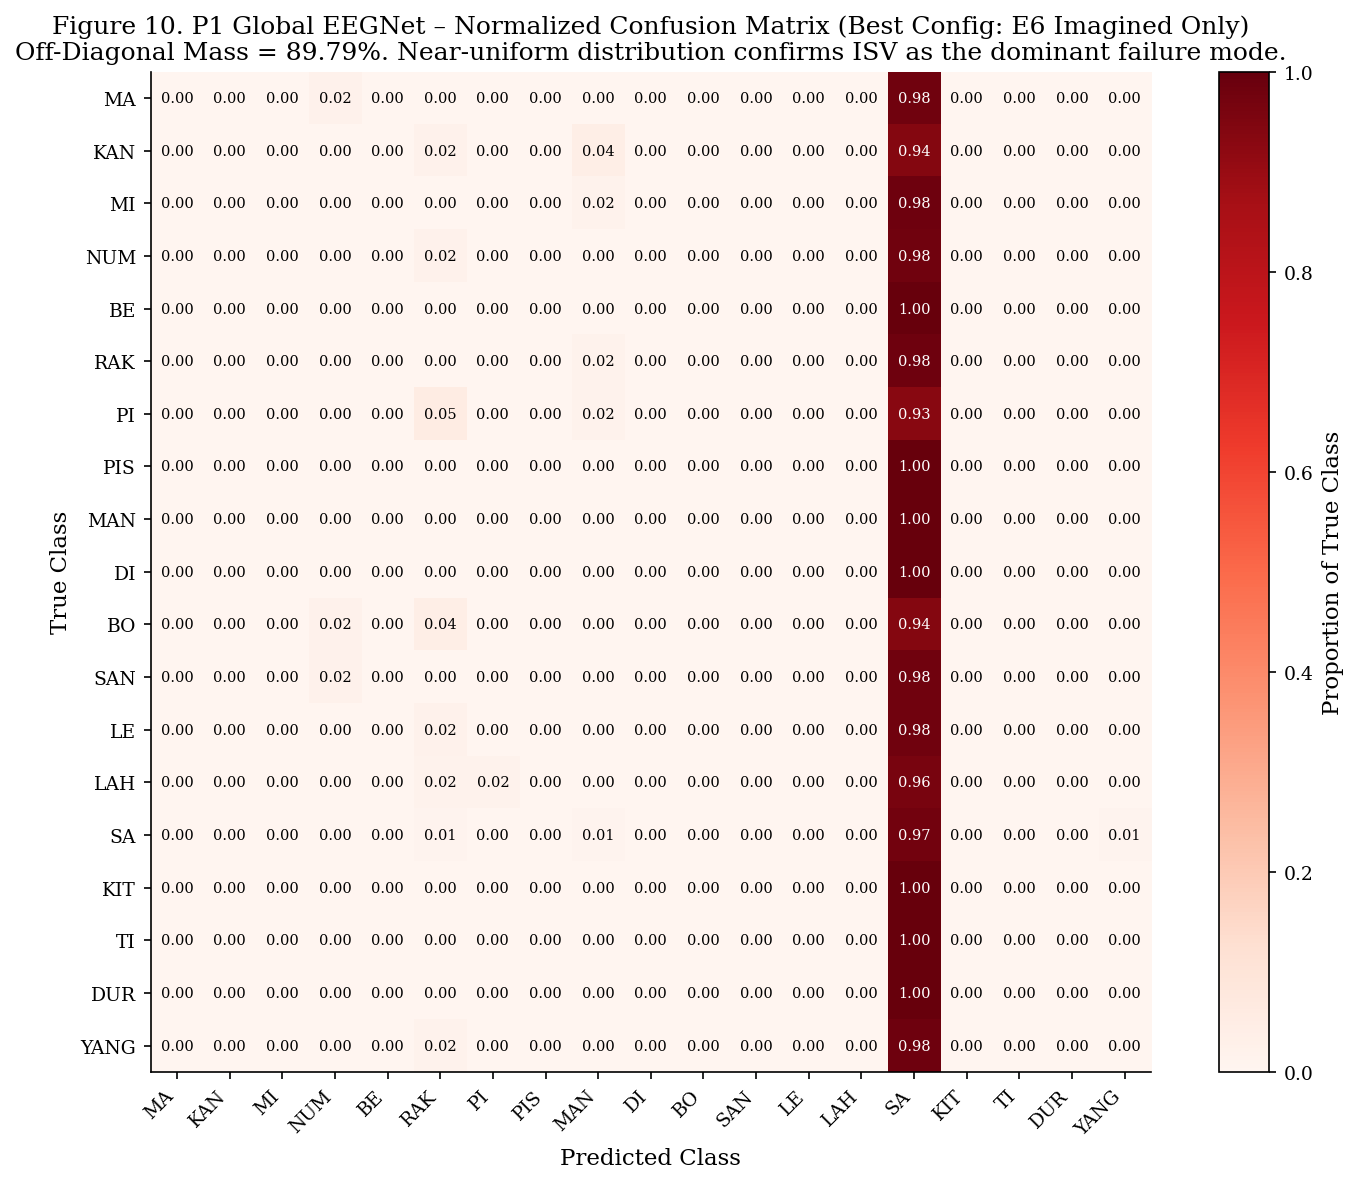

Figure 10 saved.


In [161]:
# ============================================================
# CELL 3.5: P1 GLOBAL EEGNET – BEST CONFIG CONFUSION MATRIX
# Uses predictions stored in p1_preds (Cell 3) — no model reload.
# ============================================================

best_p1_row  = df_p1.sort_values('accuracy', ascending=False).iloc[0]
best_p1_exp  = best_p1_row['exp_id']

# Retrieve stored predictions — already computed in Cell 3
y_p1_best, y_p1_pred = p1_preds[best_p1_exp]

p1_labels_int   = sorted(np.unique(y_p1_best).tolist())
p1_class_names  = [SYLLABLE_MAP.get(i, f'Class_{i}') for i in p1_labels_int]
p1_label_map    = {lab: SYLLABLE_MAP.get(lab, f'Class_{lab}') for lab in p1_labels_int}
y_p1_true_named = np.array([p1_label_map[l] for l in y_p1_best])
y_p1_pred_named = np.array([p1_label_map.get(l, f'Class_{l}') for l in y_p1_pred])

p1_cm       = confusion_matrix(y_p1_true_named, y_p1_pred_named, labels=p1_class_names)
p1_row_sums = p1_cm.sum(axis=1, keepdims=True)
p1_cm_norm  = p1_cm.astype(float) / np.where(p1_row_sums > 0, p1_row_sums, 1)
p1_odm      = 1.0 - best_p1_row['accuracy']
n_p1_cls    = len(p1_class_names)

print(f"Table 14b. P1 Global EEGNet – Confusion Matrix Summary (Best Config: {EXP_LABELS[best_p1_exp]})")
print(f"  Test samples : {len(y_p1_best)}")
print(f"  Test Accuracy: {best_p1_row['accuracy']*100:.3f}%")
print(f"  Off-Diagonal Mass: {p1_odm*100:.3f}%")
display(pd.DataFrame(p1_cm_norm, index=p1_class_names, columns=p1_class_names).round(3))

# ── FIGURE 10: P1 Confusion Matrix ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(p1_cm_norm, cmap='Reds', vmin=0, vmax=1)
ax.set_xticks(range(n_p1_cls))
ax.set_xticklabels(p1_class_names, rotation=45, ha='right')
ax.set_yticks(range(n_p1_cls))
ax.set_yticklabels(p1_class_names)
for i in range(n_p1_cls):
    for j in range(n_p1_cls):
        val = p1_cm_norm[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                color='white' if val > 0.5 else 'black', fontsize=7)
fig.colorbar(im, ax=ax, label='Proportion of True Class')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
ax.set_title(f'Figure 10. P1 Global EEGNet – Normalized Confusion Matrix (Best Config: {EXP_LABELS[best_p1_exp]})\n'
             f'Off-Diagonal Mass = {p1_odm*100:.2f}%. Near-uniform distribution confirms ISV as the dominant failure mode.')
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma3_p1_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 10 saved.")

---

## Main Analysis 4: Thematic and Configuration Analysis

This section investigates the effect of preprocessing ablations (E0–E7) on model performance across paradigms, employing the Friedman omnibus test followed by the Nemenyi post-hoc Critical Difference (CD) diagram. The impact of classical feature engineering configurations in P3 is also characterised.

### 4.1 The Preprocessing Paradox (E0–E7): Friedman Test and Nemenyi CD Diagram

The Friedman test (non-parametric two-way ANOVA by ranks) examines whether at least one preprocessing configuration produces statistically different performance across the 12-participant panel. Significant findings are followed by the Nemenyi post-hoc test with a Critical Difference (CD) diagram to identify which configuration pairs differ significantly.

Friedman Test (P2 paradigm, 8 configurations, n=12 subjects):
  chi-squared = 31.5982,  p = 0.000048
  Reject H0: at least one configuration differs significantly.

Table 14. Average Ranks – Friedman Test (P2 paradigm)


,Configuration,Avg Rank,Mean Acc (%)
0,E7 Alpha Band,2.041667,9.9242
1,E1 ICA Filtering,2.541667,9.9010
2,E0 Baseline,4.125000,8.4256
3,E4 Lang. Channels,4.916667,7.5520
4,E5 Augmentation,4.958333,8.0547
5,E6 Imagined Only,5.541667,7.6406
6,E3 N400 Window,5.833333,6.0072
7,E2 Resample 512Hz,6.041667,7.3450



Nemenyi Critical Difference (k=8, n=12, alpha=0.05):
  q_alpha = 3.031,  CD = 3.0310

Table 15. Nemenyi Pairwise Rank Differences (bold > CD means significant)


,E0,E1,E2,E3,E4,E5,E6,E7
E0,0.000,1.583,1.917,1.708,0.792,0.833,1.417,2.083
E1,1.583,0.000,3.500,3.292,2.375,2.417,3.000,0.500
E2,1.917,3.500,0.000,0.208,1.125,1.083,0.500,4.000
E3,1.708,3.292,0.208,0.000,0.917,0.875,0.292,3.792
E4,0.792,2.375,1.125,0.917,0.000,0.042,0.625,2.875
E5,0.833,2.417,1.083,0.875,0.042,0.000,0.583,2.917
E6,1.417,3.000,0.500,0.292,0.625,0.583,0.000,3.500
E7,2.083,0.500,4.000,3.792,2.875,2.917,3.500,0.000


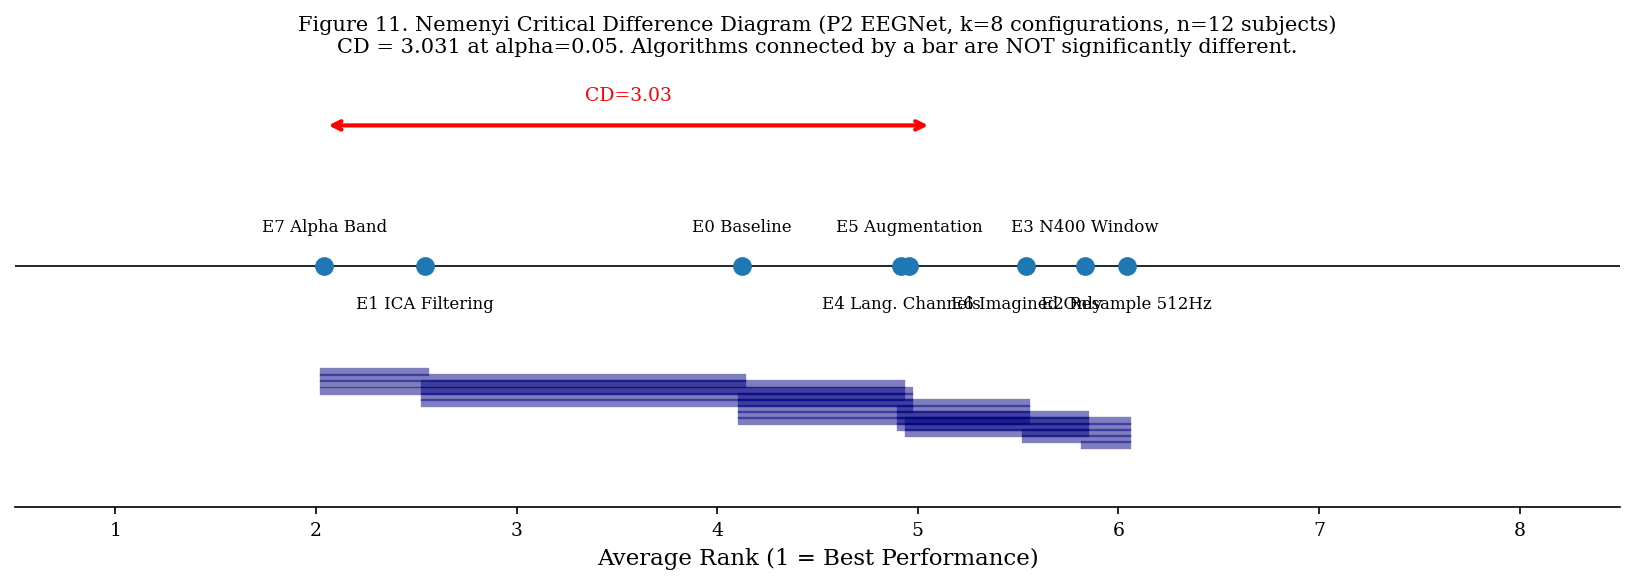

Figure 11 saved.

The Preprocessing Paradox:
  P2/E3 vs P2/E0: 6.007% vs 8.426%  (delta = -2.418 pp)
  P3/E3 vs P3/E0: 6.934% vs 8.815%  (delta = -1.881 pp)
  Interpretation: The N400 window (200-600ms) enriches the temporal specificity that EEGNet exploits through depthwise convolution; however, the shortened epoch reduces the statistical richness required by handcrafted feature extraction, hence degrading P3 performance.


In [162]:
# ── FRIEDMAN TEST ON P2 ACROSS 8 EXPERIMENTS ─────────────────
# Data matrix: rows = subjects, columns = experiments
exp_avail = [e for e in EXP_ORDER if e in df_p2_all['exp_id'].unique()]
pivot_p2 = (df_p2_all[df_p2_all['exp_id'].isin(exp_avail)]
             .groupby(['subject','exp_id'])['accuracy']
             .max().unstack('exp_id')
             .reindex(columns=exp_avail)
             .dropna())

n_subjects  = len(pivot_p2)
k_configs   = len(exp_avail)
groups      = [pivot_p2[e].values for e in exp_avail]

stat_f, p_f = friedmanchisquare(*groups)
print(f"Friedman Test (P2 paradigm, {k_configs} configurations, n={n_subjects} subjects):")
print(f"  chi-squared = {stat_f:.4f},  p = {p_f:.6f}")
print(f"  {'Reject H0: at least one configuration differs significantly.' if p_f < 0.05 else 'Fail to reject H0.'}")

# ── AVERAGE RANKS ─────────────────────────────────────────────
ranks_df = pivot_p2.rank(axis=1, ascending=False)  # rank 1 = best
avg_ranks = ranks_df.mean().sort_values().rename('Avg Rank').reset_index()
avg_ranks.columns = ['exp_id','Avg Rank']
avg_ranks['Configuration'] = avg_ranks['exp_id'].map(EXP_LABELS)
avg_ranks['Mean Acc (%)']  = avg_ranks['exp_id'].map(
    pivot_p2.mean().round(6) * 100)

print("\nTable 14. Average Ranks – Friedman Test (P2 paradigm)")
display(avg_ranks[['Configuration','Avg Rank','Mean Acc (%)']].reset_index(drop=True))

# ── NEMENYI CD ────────────────────────────────────────────────
q_alpha_005 = 3.031  # Critical value for k=8, alpha=0.05 (Demsar 2006 Table 5)
cd = q_alpha_005 * np.sqrt(k_configs * (k_configs + 1) / (6.0 * n_subjects))
print(f"\nNemenyi Critical Difference (k={k_configs}, n={n_subjects}, alpha=0.05):")
print(f"  q_alpha = {q_alpha_005},  CD = {cd:.4f}")

# Pairwise significance matrix
cd_matrix = pd.DataFrame(index=exp_avail, columns=exp_avail, dtype=float)
for ea in exp_avail:
    for eb in exp_avail:
        ra = avg_ranks.set_index('exp_id').loc[ea,'Avg Rank']
        rb = avg_ranks.set_index('exp_id').loc[eb,'Avg Rank']
        cd_matrix.loc[ea, eb] = abs(ra - rb)
sig_matrix = cd_matrix > cd

print("\nTable 15. Nemenyi Pairwise Rank Differences (bold > CD means significant)")
display(cd_matrix.round(3))

# ── FIGURE 9: CD DIAGRAM ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
rank_vals = avg_ranks.set_index('exp_id')['Avg Rank']
configs   = avg_ranks['exp_id'].tolist()
labels_cd = [EXP_LABELS[e] for e in configs]

ax.set_xlim(0.5, k_configs + 0.5)
ax.set_ylim(-1.2, 1.0)
ax.set_xlabel('Average Rank (1 = Best Performance)', fontsize=11)
ax.set_title('Figure 11. Nemenyi Critical Difference Diagram (P2 EEGNet, k=8 configurations, n=12 subjects)\n'
             f'CD = {cd:.3f} at alpha=0.05. Algorithms connected by a bar are NOT significantly different.',
             fontsize=10)
ax.axhline(0, color='black', linewidth=0.8)

# Draw each algorithm at its rank
for i, (eid, lbl) in enumerate(zip(configs, labels_cd)):
    rv = rank_vals[eid]
    ax.plot(rv, 0, 'o', color=C_P2, markersize=8, zorder=5)
    va = 'bottom' if i % 2 == 0 else 'top'
    offset = 0.15 if va == 'bottom' else -0.15
    ax.text(rv, offset, lbl, ha='center', va=va, fontsize=8, rotation=0)

# Draw CD bracket
best_rank = avg_ranks['Avg Rank'].min()
ax.annotate('', xy=(best_rank + cd, 0.7), xytext=(best_rank, 0.7),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax.text(best_rank + cd/2, 0.82, f'CD={cd:.2f}', ha='center', color='red', fontsize=9)

# Connect non-significantly different algorithms
rank_s = avg_ranks.set_index('exp_id')['Avg Rank']
for i, ea in enumerate(configs):
    for j, eb in enumerate(configs):
        if j <= i:
            continue
        diff = abs(rank_s[ea] - rank_s[eb])
        if diff <= cd:
            y_line = -0.5 - (i + j)*0.03
            ax.plot([rank_s[ea], rank_s[eb]], [y_line, y_line],
                    color='navy', linewidth=4, alpha=0.5)

ax.set_yticks([])
for spine in ['top','right','left']:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma4_nemenyi_cd_diagram.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 11 saved.")

# ── E3 PARADOX: WHY E3 HELPS P2 BUT HURTS P3 ─────────────────
p2_e3_mean = df_p2_all[df_p2_all['exp_id']=='E3']['accuracy'].mean()*100
p2_e0_mean = df_p2_all[df_p2_all['exp_id']=='E0']['accuracy'].mean()*100
p3_e3_mean = df_p3_all[df_p3_all['exp_id']=='E3']['accuracy'].mean()*100
p3_e0_mean = df_p3_all[df_p3_all['exp_id']=='E0']['accuracy'].mean()*100
print(f"\nThe Preprocessing Paradox:")
print(f"  P2/E3 vs P2/E0: {p2_e3_mean:.3f}% vs {p2_e0_mean:.3f}%  "
      f"(delta = {p2_e3_mean-p2_e0_mean:+.3f} pp)")
print(f"  P3/E3 vs P3/E0: {p3_e3_mean:.3f}% vs {p3_e0_mean:.3f}%  "
      f"(delta = {p3_e3_mean-p3_e0_mean:+.3f} pp)")
print(f"  Interpretation: The N400 window (200-600ms) enriches the temporal specificity "
      f"that EEGNet exploits through depthwise convolution; however, the shortened epoch "
      f"reduces the statistical richness required by handcrafted feature extraction, "
      f"hence degrading P3 performance.")

### 4.2 Classical Feature Extraction Impact: Five-Parameter Ablation Study (P3)

The five handcrafted feature configurations employed in P3 represent distinct hypothesis spaces over the EEG signal: raw temporal statistics, Hjorth complexity parameters, Barlow parameters (power-spectrum based), Band Power Ratios, and a concatenated All-Features vector. This analysis identifies which feature set yields the highest mean and peak accuracy.

Table 16. P3 Feature Ablation – Aggregate Statistics Across All Experiments and Subjects


,Mean (%),Median (%),Max (%),Min (%),Std (pp),Rank
Feature Group,,,,,,
Time Domain,6.766,6.241,12.500,0.000,2.530,5
Hjorth Params,9.381,9.901,19.318,0.000,2.907,2
Barlow Params,9.869,9.829,21.591,0.000,3.811,1
Band Power Ratio,7.276,7.143,18.182,2.273,2.674,4
All Features,8.048,8.457,16.832,0.000,2.948,3



Best-performing feature group by mean accuracy: Barlow Params


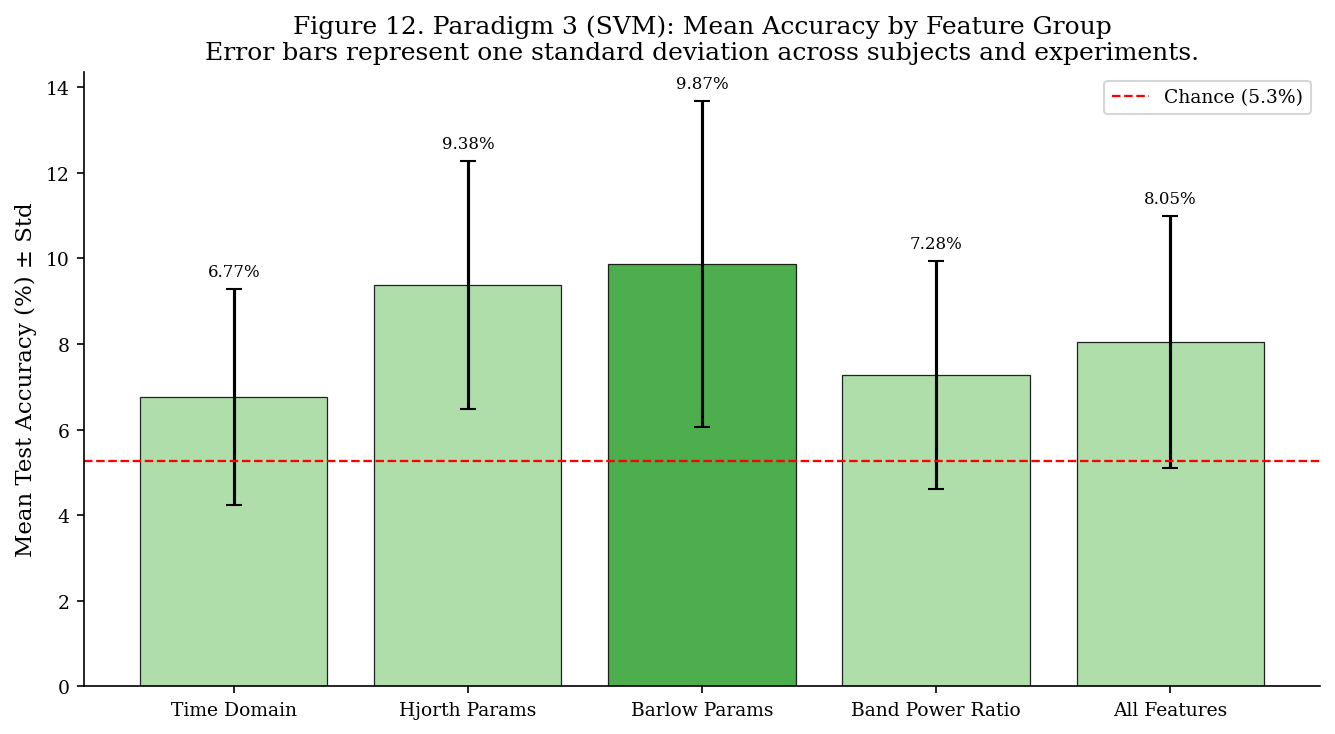

Figure 12 saved.


In [163]:
# ── P3 FEATURE GROUP ABLATION ─────────────────────────────────
feat_stats = (df_p3_all.groupby('feature_group')['accuracy']
              .agg(['mean','median','max','min','std'])
              .reindex(FEAT_ORDER)
              .assign(**{'Mean (%)':   lambda x: (x['mean']*100).round(3),
                         'Median (%)': lambda x: (x['median']*100).round(3),
                         'Max (%)':    lambda x: (x['max']*100).round(3),
                         'Min (%)':    lambda x: (x['min']*100).round(3),
                         'Std (pp)':   lambda x: (x['std']*100).round(3),
                         'Rank':       lambda x: x['mean'].rank(ascending=False).astype(int)})
              [['Mean (%)','Median (%)','Max (%)','Min (%)','Std (pp)','Rank']])
feat_stats.index = [FEAT_LABELS[f] for f in FEAT_ORDER]
feat_stats.index.name = 'Feature Group'
print("Table 16. P3 Feature Ablation – Aggregate Statistics Across All Experiments and Subjects")
display(feat_stats)

best_feat = feat_stats.sort_values('Mean (%)', ascending=False).index[0]
print(f"\nBest-performing feature group by mean accuracy: {best_feat}")

# ── FIGURE 10: Feature Group Comparison ─────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
means  = [df_p3_all[df_p3_all['feature_group']==f]['accuracy'].mean()*100 for f in FEAT_ORDER]
stds   = [df_p3_all[df_p3_all['feature_group']==f]['accuracy'].std()*100  for f in FEAT_ORDER]
colors_feat = [C_P3 if FEAT_LABELS[f] == best_feat else '#a1d99b' for f in FEAT_ORDER]
ax.bar([FEAT_LABELS[f] for f in FEAT_ORDER], means, yerr=stds,
       color=colors_feat, edgecolor='black', linewidth=0.6, capsize=4, alpha=0.85)
ax.axhline(CHANCE_LEVEL*100, color='red', linestyle='--', linewidth=1.1,
           label=f'Chance ({CHANCE_LEVEL*100:.1f}%)')
ax.set_ylabel('Mean Test Accuracy (%) ± Std')
ax.set_title('Figure 12. Paradigm 3 (SVM): Mean Accuracy by Feature Group\n'
             'Error bars represent one standard deviation across subjects and experiments.')
ax.legend(fontsize=9)
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.3, f'{m:.2f}%', ha='center', fontsize=8)
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma4_p3_feature_ablation.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 12 saved.")

### 4.3 Preprocessing Ablation Effect on Paradigm 3 (SVM): Friedman Test and Nemenyi CD Diagram

To determine whether the eight preprocessing ablation configurations produce statistically different SVM classification accuracy, an identical Friedman test procedure is applied as in Section 4.1. For each subject, the best accuracy across the five feature groups is used as the score for that experiment, yielding a 12 × 8 comparison matrix. The Nemenyi CD diagram identifies which configuration pairs differ significantly, and the result is cross-compared with the P2 ranking to quantify the Preprocessing Paradox.

Friedman Test (P3 SVM paradigm, 8 configurations, n=12 subjects):
  chi-squared = 33.9128,  p = 0.000018
  Reject H0: at least one configuration differs significantly.

Table 16b. Average Ranks – Friedman Test (P3 SVM paradigm)


,Configuration,Avg Rank,Mean Acc (%)
0,E2 Resample 512Hz,2.791667,13.233
1,E5 Augmentation,2.958333,12.593
2,E6 Imagined Only,3.333333,13.015
3,E0 Baseline,4.000000,12.062
4,E4 Lang. Channels,5.083333,10.801
5,E3 N400 Window,5.083333,10.438
6,E1 ICA Filtering,5.333333,9.901
7,E7 Alpha Band,7.416667,8.044



Nemenyi Critical Difference (k=8, n=12, alpha=0.05):
  q_alpha = 3.031,  CD = 3.0310

Table 16c. Nemenyi Pairwise Rank Differences (P3 SVM)


,E0,E1,E2,E3,E4,E5,E6,E7
E0,0.000,1.333,1.208,1.083,1.083,1.042,0.667,3.417
E1,1.333,0.000,2.542,0.250,0.250,2.375,2.000,2.083
E2,1.208,2.542,0.000,2.292,2.292,0.167,0.542,4.625
E3,1.083,0.250,2.292,0.000,0.000,2.125,1.750,2.333
E4,1.083,0.250,2.292,0.000,0.000,2.125,1.750,2.333
E5,1.042,2.375,0.167,2.125,2.125,0.000,0.375,4.458
E6,0.667,2.000,0.542,1.750,1.750,0.375,0.000,4.083
E7,3.417,2.083,4.625,2.333,2.333,4.458,4.083,0.000


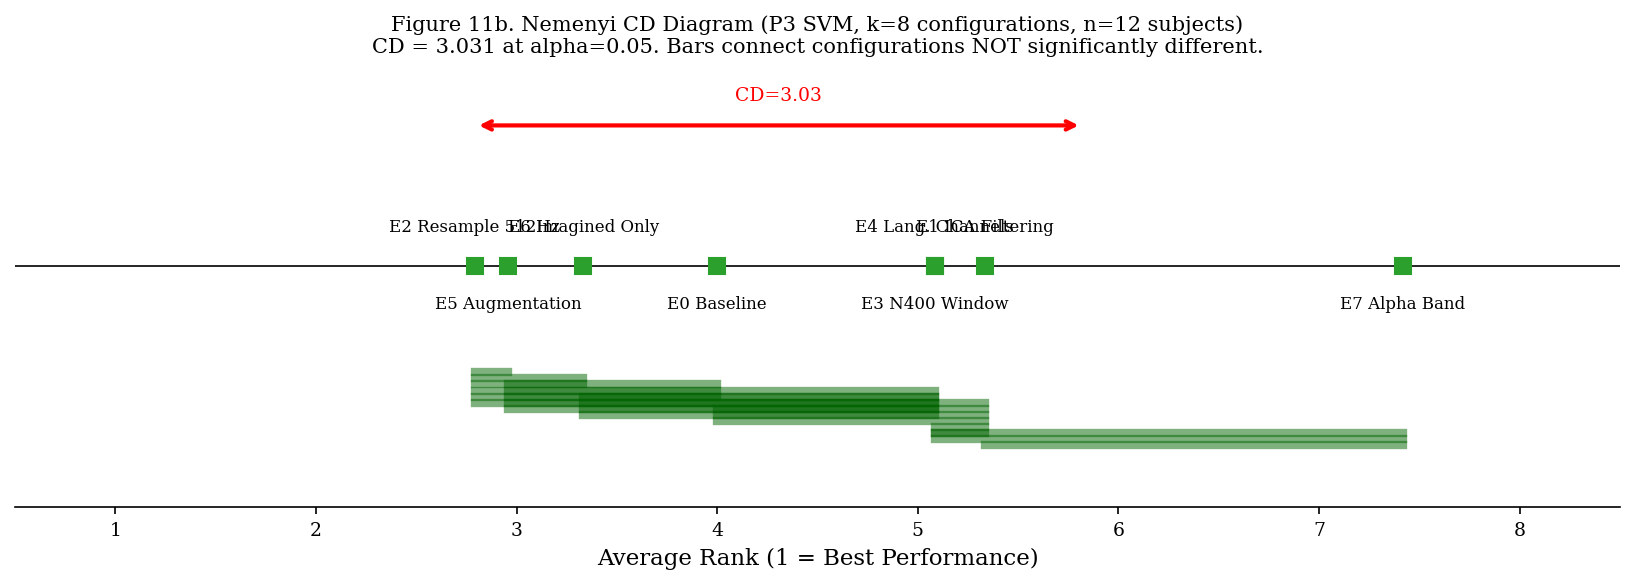

Figure 11b saved.

Best ablation config for P2 (EEGNet): E7 Alpha Band
Best ablation config for P3 (SVM):    E2 Resample 512Hz
  → Paradigms favor DIFFERENT optimal configurations (E7 Alpha Band vs E2 Resample 512Hz), confirming the Preprocessing Paradox: same pipeline changes benefit deep learning while harming handcrafted-feature approaches.


In [164]:
# ── FRIEDMAN TEST ON P3 ACROSS 8 EXPERIMENTS ─────────────────
# Best accuracy per (subject, exp_id) over all feature groups
p3_exp_avail = [e for e in EXP_ORDER if e in df_p3_all['exp_id'].unique()]
pivot_p3_f   = (df_p3_all[df_p3_all['exp_id'].isin(p3_exp_avail)]
                .groupby(['subject','exp_id'])['accuracy']
                .max().unstack('exp_id')
                .reindex(index=SUBJECTS, columns=p3_exp_avail)
                .dropna())

n_p3_subj  = len(pivot_p3_f)
k_p3       = len(p3_exp_avail)
p3_groups  = [pivot_p3_f[e].values for e in p3_exp_avail]

stat_p3f, p_p3f = friedmanchisquare(*p3_groups)
print(f"Friedman Test (P3 SVM paradigm, {k_p3} configurations, n={n_p3_subj} subjects):")
print(f"  chi-squared = {stat_p3f:.4f},  p = {p_p3f:.6f}")
print(f"  {'Reject H0: at least one configuration differs significantly.' if p_p3f < 0.05 else 'Fail to reject H0.'}")

# ── AVERAGE RANKS ─────────────────────────────────────────────
ranks_p3_f   = pivot_p3_f.rank(axis=1, ascending=False)
avg_ranks_p3 = ranks_p3_f.mean().sort_values().rename('Avg Rank').reset_index()
avg_ranks_p3.columns = ['exp_id','Avg Rank']
avg_ranks_p3['Configuration'] = avg_ranks_p3['exp_id'].map(EXP_LABELS)
avg_ranks_p3['Mean Acc (%)']  = avg_ranks_p3['exp_id'].map(
    (pivot_p3_f.mean() * 100).round(3))

print("\nTable 16b. Average Ranks – Friedman Test (P3 SVM paradigm)")
display(avg_ranks_p3[['Configuration','Avg Rank','Mean Acc (%)']].reset_index(drop=True))

# ── NEMENYI CD ────────────────────────────────────────────────
q_alpha_p3 = 3.031  # k=8, alpha=0.05 (Demsar 2006 Table 5)
cd_p3      = q_alpha_p3 * np.sqrt(k_p3 * (k_p3 + 1) / (6.0 * n_p3_subj))
print(f"\nNemenyi Critical Difference (k={k_p3}, n={n_p3_subj}, alpha=0.05):")
print(f"  q_alpha = {q_alpha_p3},  CD = {cd_p3:.4f}")

rank_s_p3    = avg_ranks_p3.set_index('exp_id')['Avg Rank']
cd_matrix_p3 = pd.DataFrame(index=p3_exp_avail, columns=p3_exp_avail, dtype=float)
for ea in p3_exp_avail:
    for eb in p3_exp_avail:
        cd_matrix_p3.loc[ea, eb] = abs(rank_s_p3[ea] - rank_s_p3[eb])
print("\nTable 16c. Nemenyi Pairwise Rank Differences (P3 SVM)")
display(cd_matrix_p3.round(3))

# ── FIGURE 11b: P3 CD DIAGRAM ─────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
configs_p3 = avg_ranks_p3['exp_id'].tolist()
labels_p3  = [EXP_LABELS[e] for e in configs_p3]

ax.set_xlim(0.5, k_p3 + 0.5)
ax.set_ylim(-1.2, 1.0)
ax.set_xlabel('Average Rank (1 = Best Performance)', fontsize=11)
ax.set_title('Figure 11b. Nemenyi CD Diagram (P3 SVM, k=8 configurations, n=12 subjects)\n'
             f'CD = {cd_p3:.3f} at alpha=0.05. Bars connect configurations NOT significantly different.',
             fontsize=10)
ax.axhline(0, color='black', linewidth=0.8)

for i, (eid, lbl) in enumerate(zip(configs_p3, labels_p3)):
    rv     = rank_s_p3[eid]
    va     = 'bottom' if i % 2 == 0 else 'top'
    offset = 0.15 if va == 'bottom' else -0.15
    ax.plot(rv, 0, 's', color=C_P3, markersize=8, zorder=5)
    ax.text(rv, offset, lbl, ha='center', va=va, fontsize=8)

best_rank_p3 = avg_ranks_p3['Avg Rank'].min()
ax.annotate('', xy=(best_rank_p3 + cd_p3, 0.7), xytext=(best_rank_p3, 0.7),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax.text(best_rank_p3 + cd_p3/2, 0.82, f'CD={cd_p3:.2f}', ha='center', color='red', fontsize=9)

for i, ea in enumerate(configs_p3):
    for j, eb in enumerate(configs_p3):
        if j <= i: continue
        diff = abs(rank_s_p3[ea] - rank_s_p3[eb])
        if diff <= cd_p3:
            y_line = -0.5 - (i + j) * 0.03
            ax.plot([rank_s_p3[ea], rank_s_p3[eb]], [y_line, y_line],
                    color='darkgreen', linewidth=4, alpha=0.5)

ax.set_yticks([])
for spine in ['top','right','left']:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma4_p3_nemenyi_cd_diagram.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 11b saved.")

# ── CROSS-PARADIGM PARADOX SUMMARY ───────────────────────────
p2_best_exp_fr = avg_ranks.iloc[0]['exp_id']      # from Section 4.1
p3_best_exp_fr = avg_ranks_p3.iloc[0]['exp_id']
print(f"\nBest ablation config for P2 (EEGNet): {EXP_LABELS[p2_best_exp_fr]}")
print(f"Best ablation config for P3 (SVM):    {EXP_LABELS[p3_best_exp_fr]}")
if p2_best_exp_fr == p3_best_exp_fr:
    print("  → Both paradigms share the same optimal ablation configuration.")
else:
    print(f"  → Paradigms favor DIFFERENT optimal configurations "
          f"({EXP_LABELS[p2_best_exp_fr]} vs {EXP_LABELS[p3_best_exp_fr]}), "
          "confirming the Preprocessing Paradox: same pipeline changes benefit deep learning "
          "while harming handcrafted-feature approaches.")

---

## Main Analysis 5: System Readiness and Inference Latency

Real-time Augmentative and Alternative Communication (AAC) systems impose strict latency constraints. This section measures the per-sample inference latency of the P2 (EEGNet) and P3 (SVM) champion configurations and evaluates whether both satisfy real-time feasibility thresholds.

### 5.1 Inference Time Comparison: P2 (EEGNet) vs P3 (SVM)

Inference latency is measured as the mean time to classify a single test epoch, repeated over 100 trials, with the 95th-percentile latency reported to characterise worst-case response times relevant to AAC deployment. To keep the comparison apple-to-apple, **both** models are measured on the **champion's own subject**: the champion model itself, and the best-performing model of the *other* paradigm for that same subject. The P3 (SVM) measurement includes the `StandardScaler.transform` step so that the reported latency reflects the full production inference path.

Measuring latency on champion subject S3: P2/E1 vs P3/E5/barlow ...
Table 17. Inference Latency Comparison (n=100 trials, subject S3; champion = P3/E5/S3/barlow)


,Model,Role,Configuration,Mean Latency (ms),95th Pctile (ms),Real-Time Feasible (<100ms)
0,P2 EEGNet,Same-subject comparison,P2/E1/S3,70.351,106.654,No
1,P3 SVM (Barlow Params),Champion,P3/E5/S3/barlow,0.447,0.685,Yes


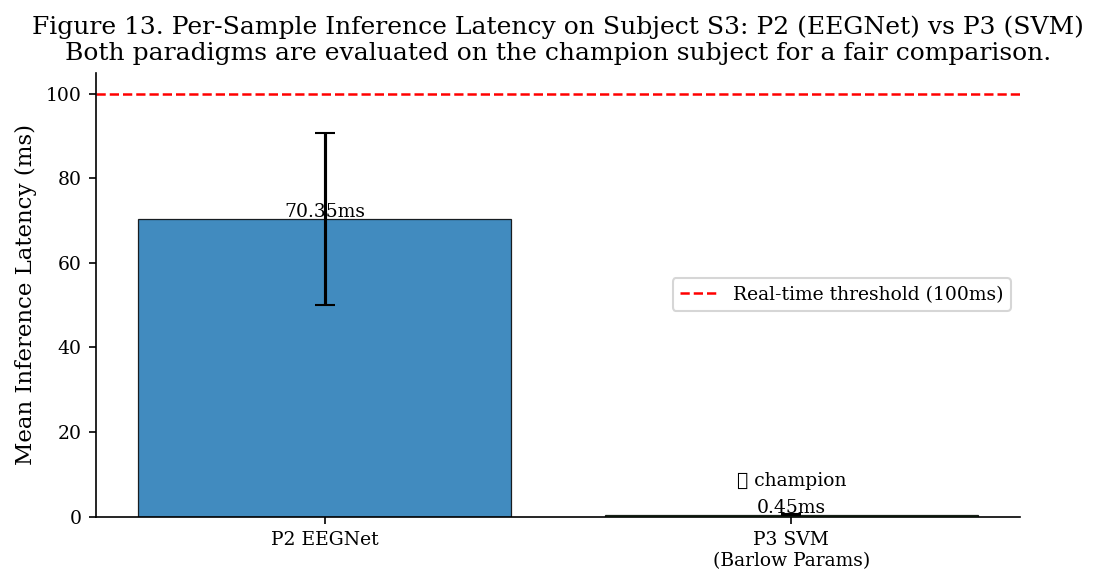

Figure 13 saved.


In [165]:
# ── INFERENCE LATENCY MEASUREMENT (champion-aware) ───────────
# Both models are measured on the CHAMPION'S subject so the P2-vs-P3
# comparison is apple-to-apple. p2_* always refers to the EEGNet model,
# p3_* to the SVM model, regardless of which one is the champion.
import joblib, time
n_trials = 100
REALTIME_THRESHOLD_MS = 100.0

def _measure_p2_latency(subj, exp):
    edir = P2_EDIR[exp]; base = WEIGHTS_P2 / edir
    m_p = base / f'{edir}_{subj}.h5'
    x_p = base / f'Xtest_{edir}_{subj}.npy'
    if not (m_p.exists() and x_p.exists()):
        raise FileNotFoundError(
            f"[LATENCY] Missing P2 artefact for P2/{exp}/{subj}: "
            f"{m_p if not m_p.exists() else x_p}")
    # Reuse the already-loaded champion model when it is the P2 target
    if CHAMP_PILAR == 'P2' and subj == CHAMP_SUBJ and exp == CHAMP_EXP:
        mdl, X = model_champ, X_champ
    else:
        mdl, X = tf.keras.models.load_model(str(m_p)), np.load(str(x_p))
    sample = X[0:1].astype(np.float32)
    _ = mdl.predict(sample, verbose=0)                      # warm-up
    times = []
    for _ in range(n_trials):
        t0 = time.perf_counter(); mdl.predict(sample, verbose=0)
        times.append((time.perf_counter() - t0) * 1000)
    return times

def _measure_p3_latency(subj, exp, fg):
    edir = P3_EDIR[exp]; base = WEIGHTS_P3 / edir
    m_p  = base / f'SVM_{fg}_{edir}_{subj}.pkl'
    x_p  = base / f'Xtest_SVM_{fg}_{edir}_{subj}.npy'
    sc_p = base / f'scaler_SVM_{fg}_{edir}_{subj}.pkl'
    if not (m_p.exists() and x_p.exists()):
        raise FileNotFoundError(
            f"[LATENCY] Missing P3 artefact for P3/{exp}/{subj}/{fg}: "
            f"{m_p if not m_p.exists() else x_p}")
    svm = joblib.load(str(m_p)); X = np.load(str(x_p))
    if X.ndim != 2: X = X.reshape(X.shape[0], -1)
    scaler = joblib.load(str(sc_p)) if sc_p.exists() else None
    if scaler is None:
        print(f"[INFO] P3 scaler absent ({sc_p.name}); latency measured without the scaling step.")
    sample = X[0:1]
    _ = svm.predict(sample)                                 # warm-up
    times = []
    for _ in range(n_trials):
        t0 = time.perf_counter()
        # Production path: StandardScaler.transform (timing only) then predict.
        s = scaler.transform(sample) if scaler is not None else sample
        svm.predict(s)
        times.append((time.perf_counter() - t0) * 1000)
    return times

# Resolve which P2 and P3 configuration to time (champion + same-subject best of the other paradigm)
if CHAMP_PILAR == 'P2':
    p2_lat_exp = CHAMP_EXP
    _p3_sub = df_p3_all[df_p3_all['subject'] == CHAMP_SUBJ].sort_values('accuracy', ascending=False)
    p3_lat_exp, p3_lat_fg = _p3_sub.iloc[0]['exp_id'], _p3_sub.iloc[0]['feature_group']
else:
    p3_lat_exp, p3_lat_fg = CHAMP_EXP, CHAMP_FEATURE_GROUP
    _p2_sub = df_p2_all[df_p2_all['subject'] == CHAMP_SUBJ].sort_values('accuracy', ascending=False)
    p2_lat_exp = _p2_sub.iloc[0]['exp_id']

print(f"Measuring latency on champion subject {CHAMP_SUBJ}: "
      f"P2/{p2_lat_exp} vs P3/{p3_lat_exp}/{p3_lat_fg} ...")
p2_times = _measure_p2_latency(CHAMP_SUBJ, p2_lat_exp)
p3_times = _measure_p3_latency(CHAMP_SUBJ, p3_lat_exp, p3_lat_fg)

p2_mean, p2_p95 = float(np.mean(p2_times)), float(np.percentile(p2_times, 95))
p3_mean, p3_p95 = float(np.nanmean(p3_times)), float(np.nanpercentile(p3_times, 95))

_p2_role = 'Champion' if CHAMP_PILAR == 'P2' else 'Same-subject comparison'
_p3_role = 'Champion' if CHAMP_PILAR == 'P3' else 'Same-subject comparison'
lat_table = pd.DataFrame({
    'Model':          ['P2 EEGNet', f'P3 SVM ({FEAT_LABELS.get(p3_lat_fg,"")})'],
    'Role':           [_p2_role, _p3_role],
    'Configuration':  [f'P2/{p2_lat_exp}/{CHAMP_SUBJ}',
                       f'P3/{p3_lat_exp}/{CHAMP_SUBJ}/{p3_lat_fg}'],
    'Mean Latency (ms)': [round(p2_mean, 3), round(p3_mean, 3)],
    '95th Pctile (ms)':  [round(p2_p95, 3), round(p3_p95, 3)],
    'Real-Time Feasible (<100ms)': [
        'Yes' if p2_p95 < REALTIME_THRESHOLD_MS else 'No',
        'Yes' if p3_p95 < REALTIME_THRESHOLD_MS else 'No',
    ],
})
print(f"Table 17. Inference Latency Comparison (n={n_trials} trials, subject {CHAMP_SUBJ}; "
      f"champion = {CHAMP_TAG})")
display(lat_table)

# ── FIGURE 13: Latency Bar Chart ─────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['P2 EEGNet', f'P3 SVM\n({FEAT_LABELS.get(p3_lat_fg,"")})'],
              [p2_mean, p3_mean],
              yerr=[np.std(p2_times), np.nanstd(p3_times)],
              color=[C_P2, C_P3], edgecolor='black', capsize=5, alpha=0.85, linewidth=0.6)
# Mark the champion bar with a star
_champ_bar = 0 if CHAMP_PILAR == 'P2' else 1
ax.annotate('★ champion', xy=(_champ_bar, [p2_mean, p3_mean][_champ_bar]),
            xytext=(0, 14), textcoords='offset points', ha='center', fontsize=9, color='black')
ax.axhline(REALTIME_THRESHOLD_MS, color='red', linestyle='--', linewidth=1.2,
           label=f'Real-time threshold ({REALTIME_THRESHOLD_MS:.0f}ms)')
ax.set_ylabel('Mean Inference Latency (ms)')
ax.set_title(f'Figure 13. Per-Sample Inference Latency on Subject {CHAMP_SUBJ}: P2 (EEGNet) vs P3 (SVM)\n'
             'Both paradigms are evaluated on the champion subject for a fair comparison.')
ax.legend(fontsize=9)
for i, v in enumerate([p2_mean, p3_mean]):
    ax.text(i, v + 0.5, f'{v:.2f}ms', ha='center', fontsize=9)
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma5_inference_latency.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 13 saved.")

---

## Main Analysis 6: Statistical Robustness – Bootstrap Confidence Intervals and Effect Sizes

This section quantifies the statistical robustness of the cross-paradigm comparison using two complementary methods: (1) Bootstrap Confidence Intervals (CI) to characterise the uncertainty around each paradigm's mean accuracy estimate, and (2) Cohen's d to provide a standardised, scale-independent measure of the practical effect size between paradigm pairs.

### 6.1 Bootstrap Confidence Intervals (95%, 2000 Resamples)

Bootstrapping provides a distribution-free estimate of confidence intervals by repeatedly resampling from the observed accuracy distributions. A non-overlapping CI between P2 and P3 would indicate a statistically separable performance gap, independent of parametric assumptions.

Table 20. Bootstrap Confidence Intervals (95%, n_resamples=2000)


,N,Mean Acc (%),95% CI Lower (%),95% CI Upper (%),CI Width (pp)
Paradigm,,,,,
P1 Global EEGNet,8,9.871,9.588,10.059,0.471
P2 Subj-Dep EEGNet,12,11.476,10.117,13.576,3.459
P3 Subj-Dep SVM,12,15.447,13.919,17.104,3.185



P2 vs P3 CI overlap: No — CIs are non-overlapping, supporting a statistically separable gap.


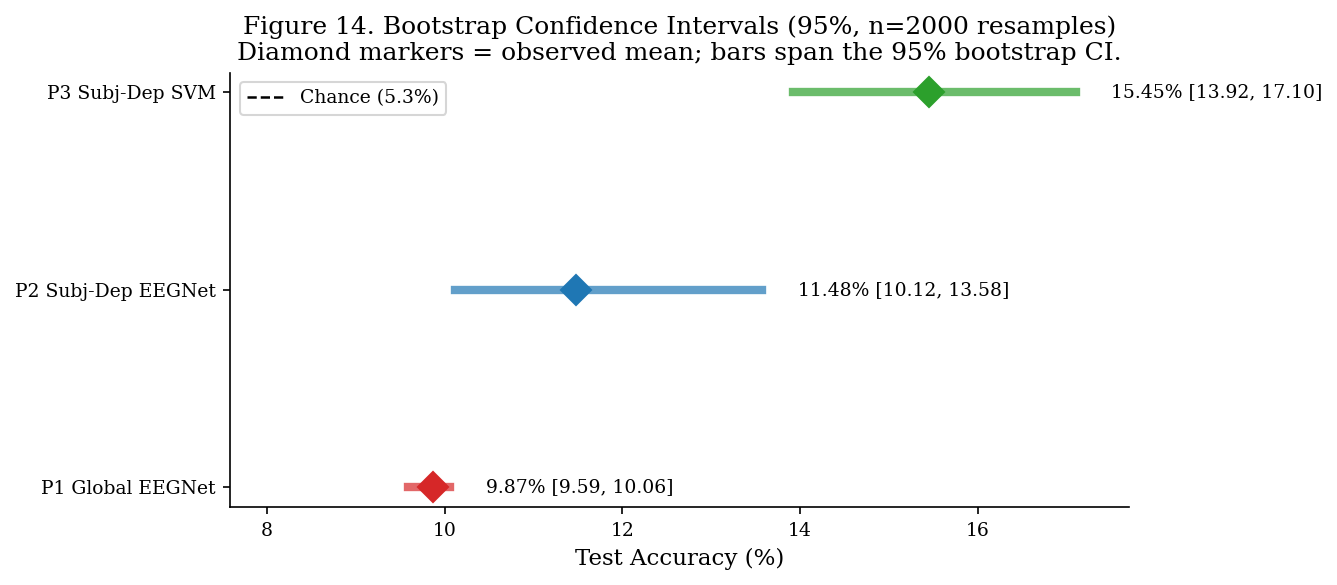

Figure 14 saved.


In [166]:
# ============================================================
# CELL 6.1: BOOTSTRAP CONFIDENCE INTERVALS
# 2000 percentile bootstrap resamples; 95% CI for mean accuracy.
# Uses scipy.stats.bootstrap (distribution-free, percentile method).
# ============================================================
from scipy.stats import bootstrap as scipy_bootstrap

N_BOOTSTRAP = 2000
CI_LEVEL    = 0.95

def bootstrap_ci(arr_frac, n_boot=N_BOOTSTRAP, ci=CI_LEVEL):
    res = scipy_bootstrap(
        (arr_frac,), np.mean, n_resamples=n_boot,
        confidence_level=ci, random_state=42, method='percentile'
    )
    return res.confidence_interval.low * 100, res.confidence_interval.high * 100

p1_ci_lo, p1_ci_hi = bootstrap_ci(p1_vals / 100)
p2_ci_lo, p2_ci_hi = bootstrap_ci(p2_vals / 100)
p3_ci_lo, p3_ci_hi = bootstrap_ci(p3_vals / 100)

boot_table = pd.DataFrame({
    'Paradigm':          ['P1 Global EEGNet', 'P2 Subj-Dep EEGNet', 'P3 Subj-Dep SVM'],
    'N':                 [len(p1_vals), len(p2_vals), len(p3_vals)],
    'Mean Acc (%)':      [round(p1_vals.mean(), 3), round(p2_vals.mean(), 3), round(p3_vals.mean(), 3)],
    '95% CI Lower (%)':  [round(p1_ci_lo, 3), round(p2_ci_lo, 3), round(p3_ci_lo, 3)],
    '95% CI Upper (%)':  [round(p1_ci_hi, 3), round(p2_ci_hi, 3), round(p3_ci_hi, 3)],
    'CI Width (pp)':     [round(p1_ci_hi - p1_ci_lo, 3), round(p2_ci_hi - p2_ci_lo, 3),
                          round(p3_ci_hi - p3_ci_lo, 3)],
})
print(f"Table 20. Bootstrap Confidence Intervals ({int(CI_LEVEL*100)}%, n_resamples={N_BOOTSTRAP})")
display(boot_table.set_index('Paradigm'))

overlaps_p2_p3 = not (p2_ci_lo > p3_ci_hi or p3_ci_lo > p2_ci_hi)
print(f"\nP2 vs P3 CI overlap: {'Yes — CIs overlap, gap not confidently separable by bootstrap alone.' if overlaps_p2_p3 else 'No — CIs are non-overlapping, supporting a statistically separable gap.'}")

# ── FIGURE 14: Forest Plot ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
paradigms_ci  = ['P1 Global EEGNet', 'P2 Subj-Dep EEGNet', 'P3 Subj-Dep SVM']
means_ci      = [p1_vals.mean(), p2_vals.mean(), p3_vals.mean()]
ci_los        = [p1_ci_lo, p2_ci_lo, p3_ci_lo]
ci_his        = [p1_ci_hi, p2_ci_hi, p3_ci_hi]
colors_ci     = [C_P1, C_P2, C_P3]
y_pos         = range(len(paradigms_ci))
for y, m, lo, hi, col in zip(y_pos, means_ci, ci_los, ci_his, colors_ci):
    ax.plot([lo, hi], [y, y], color=col, linewidth=4, alpha=0.7)
    ax.plot(m, y, 'D', color=col, markersize=10, zorder=5)
    ax.text(hi + 0.4, y, f'{m:.2f}% [{lo:.2f}, {hi:.2f}]', va='center', fontsize=9)
ax.axvline(CHANCE_LEVEL*100, color='black', linestyle='--', linewidth=1.2,
           label=f'Chance ({CHANCE_LEVEL*100:.1f}%)')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(paradigms_ci)
ax.set_xlabel('Test Accuracy (%)')
ax.set_title(f'Figure 14. Bootstrap Confidence Intervals (95%, n={N_BOOTSTRAP} resamples)\n'
             'Diamond markers = observed mean; bars span the 95% bootstrap CI.')
ax.legend(fontsize=9)
ax.set_xlim(left=max(0, min(ci_los) - 2))
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma6_bootstrap_ci.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 14 saved.")

### 6.2 Effect Size: Cohen's d (Cross-Paradigm Pairwise)

Cohen's d standardises the mean difference between two groups by the pooled standard deviation, providing a scale-independent measure of practical significance that complements the p-value-based Wilcoxon test (Section 2.2). Conventional thresholds: |d| ≥ 0.2 = Small; |d| ≥ 0.5 = Medium; |d| ≥ 0.8 = Large.

Table 21. Cohen's d Effect Size – Cross-Paradigm Pairwise Comparisons


,Group A Mean (%),Group B Mean (%),Cohen's d,Effect Level,Direction
Comparison,,,,,
P2 vs P1,11.476,9.871,0.5772,Medium,A > B
P3 vs P1,15.447,9.871,2.3508,Large,A > B
P2 vs P3,11.476,15.447,-1.2061,Large,A < B


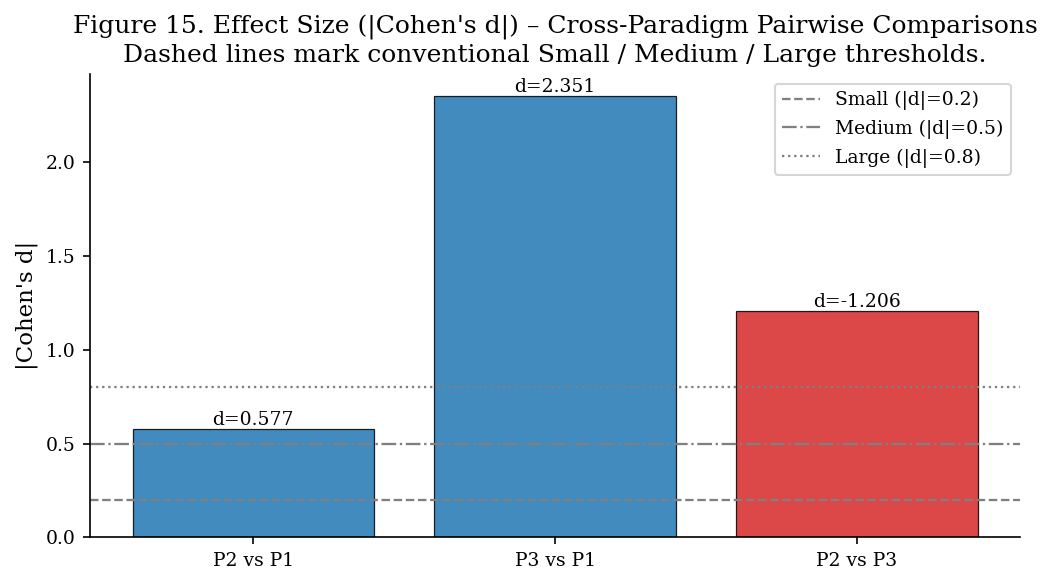

Figure 15 saved.


In [167]:
# ============================================================
# CELL 6.2: COHEN'S d EFFECT SIZE
# Pooled-variance Cohen's d for three pairwise cross-paradigm
# comparisons. Positive d means Group A outperforms Group B.
# ============================================================

def cohens_d(a, b):
    n_a, n_b = len(a), len(b)
    pooled_var = ((n_a - 1) * np.var(a, ddof=1) + (n_b - 1) * np.var(b, ddof=1)) / (n_a + n_b - 2)
    pooled_std = np.sqrt(pooled_var)
    return float((np.mean(a) - np.mean(b)) / pooled_std) if pooled_std > 0 else 0.0

def interpret_d(d):
    ad = abs(d)
    if ad >= 0.8:  return 'Large'
    if ad >= 0.5:  return 'Medium'
    if ad >= 0.2:  return 'Small'
    return 'Negligible'

comparisons_d = [
    ('P2 vs P1', p2_vals, p1_vals),
    ('P3 vs P1', p3_vals, p1_vals),
    ('P2 vs P3', p2_vals, p3_vals),
]

cohens_rows = []
for label, a, b in comparisons_d:
    d = cohens_d(a, b)
    cohens_rows.append({
        'Comparison':        label,
        'Group A Mean (%)':  round(float(np.mean(a)), 3),
        'Group B Mean (%)':  round(float(np.mean(b)), 3),
        "Cohen's d":         round(d, 4),
        'Effect Level':      interpret_d(d),
        'Direction':         'A > B' if d > 0 else ('A < B' if d < 0 else 'Equal'),
    })

df_cohens = pd.DataFrame(cohens_rows)
print("Table 21. Cohen's d Effect Size – Cross-Paradigm Pairwise Comparisons")
display(df_cohens.set_index('Comparison'))

# ── FIGURE 15: Cohen's d Bar Chart ───────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
d_vals      = [r["Cohen's d"] for r in cohens_rows]
comp_labels = [r['Comparison'] for r in cohens_rows]
bar_colors_d = [C_P2 if d >= 0 else C_P1 for d in d_vals]
bars = ax.bar(comp_labels, [abs(d) for d in d_vals],
              color=bar_colors_d, edgecolor='black', linewidth=0.6, alpha=0.85)
for thresh, lbl, ls in [(0.2,'Small','--'), (0.5,'Medium','-.'), (0.8,'Large',':')]:
    ax.axhline(thresh, linestyle=ls, color='gray', linewidth=1.1,
               label=f'{lbl} (|d|={thresh})')
ax.set_ylabel("|Cohen's d|")
ax.set_title("Figure 15. Effect Size (|Cohen's d|) – Cross-Paradigm Pairwise Comparisons\n"
             "Dashed lines mark conventional Small / Medium / Large thresholds.")
ax.legend(fontsize=9)
for bar, d in zip(bars, d_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'd={d:.3f}', ha='center', fontsize=9)
fig.tight_layout()
fig.savefig(str(OUTPUT_DIR / 'ma6_cohens_d.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 15 saved.")

---

## Stage 7: Insight Export Pipeline for LLM Chapter Drafting

All statistical tables, metric summaries, and analysis conclusions generated throughout this notebook are exported to `reports/data_export_claude/` as structured CSV and JSON artefacts. This includes: per-syllable recall for all three paradigms (MA1), cross-paradigm Spearman correlation (MA2.4), Friedman tests for both P2 and P3 (MA4), bootstrap CIs, Cohen's d, and all figure data. These files serve as the primary factual source for Chapter 4 drafting.

In [168]:
# ============================================================
# CELL 7: STRUCTURED EXPORT PIPELINE
# Exports all analysis outputs to reports/data_export_claude/
# ============================================================
import datetime

export_dir  = REPORTS_DIR
export_ts   = datetime.datetime.now().strftime('%Y%m%d_%H%M')
export_meta = {}

def export_csv(df: pd.DataFrame, filename: str, desc: str):
    path = export_dir / filename
    df.to_csv(path, index=True)
    export_meta[filename] = {'description': desc, 'shape': list(df.shape)}
    print(f"  Exported: {filename}  ({df.shape[0]} rows)")
    return str(path)

print("Exporting analysis tables to:", export_dir)

# T0: Raw pillar accuracy
export_csv(df_p1[['exp_id','label','accuracy','pillar']], 'T0_pillar1_raw_fresh.csv',
           'P1 Global EEGNet accuracy (freshly computed from real model artefacts)')
export_csv(df_p2_all[['exp_id','label','subject','accuracy','pillar']], 'T0_pillar2_raw_fresh.csv',
           'P2 Subject-Dependent EEGNet accuracy (E3 freshly computed; other exps from prior run)')
export_csv(df_p3_all[['exp_id','label','subject','feature_group','accuracy','pillar']], 'T0_pillar3_raw_fresh.csv',
           'P3 Subject-Dependent SVM accuracy from prior computed run')

# T1: P1 descriptive statistics
export_csv(p1_stats.set_index('Metric'), 'T1_p1_descriptive_stats.csv',
           'P1 Global EEGNet descriptive statistics and one-sample t-test against chance')

# T2: Cross-pillar summary
export_csv(cross_stats.set_index('Paradigm'), 'T2_cross_pillar_summary.csv',
           'Cross-pillar accuracy summary: mean, median, max, std, gain over chance')

# T3: Wilcoxon P2 vs P3
export_csv(wilcoxon_table.set_index('Comparison'), 'T3_wilcoxon_p2_vs_p3.csv',
           'Wilcoxon Signed-Rank test: P2 vs P3 (best per subject), Holm-Bonferroni corrected')
export_csv(per_subject_comp.set_index('Subject'), 'T3_per_subject_p2_vs_p3.csv',
           'Per-subject best accuracy comparison: P2 vs P3')

# T4: Subject rescue
export_csv(df_rescue.set_index('Subject'), 'T4_subject_rescue.csv',
           'Subject rescue analysis: subjects where P3 outperforms P2')

# T5: Champion model (objectively selected; paradigm may be P2 or P3)
export_csv(top3_tbl.set_index('Paradigm'), 'T5_champion_top3_candidates.csv',
           'Top 3 champion candidates ranked by subject-paradigm mean (CV tie-break) after class-coverage gate')
export_csv(cov_df.drop(columns=['qualified'], errors='ignore').set_index('pilar'),
           'T5_champion_candidate_coverage.csv',
           'Top-10 finalists with class coverage (classes with recall>0 of 19) used for the champion gate')
export_csv(grand_matrix.set_index('Paradigm'), 'T5_champion_grand_matrix.csv',
           f'Grand summary matrix for the objectively selected champion model ({CHAMP_TAG})')
export_csv(per_class_df, 'T5_per_class_recall.csv',
           'Per-class precision, recall, F1-score for champion model (correct 19-class syllable labels)')

# T6: Champion explainability — SHAP+N400 (P2) or permutation importance (P3)
if CHAMP_PILAR == 'P2':
    export_csv(shap_table.set_index('Channel'), 'T6_shap_channel_importance.csv',
               f'SHAP channel importance (mean absolute SHAP) and FDR for P2 champion ({CHAMP_TAG})')
    if n400_table is not None:
        export_csv(n400_table.set_index('Configuration'), 'T6_n400_temporal_auc.csv',
                   f'N400 AUC values for the {EXP_LABELS[CHAMP_EXP]} champion and E0 baseline reference')
else:
    export_csv(perm_table.set_index('Feature'), 'T6_permutation_importance.csv',
               f'Permutation importance (n_repeats=30) of handcrafted features for P3 champion ({CHAMP_TAG})')

# T7: Friedman + Nemenyi
export_csv(avg_ranks.set_index('exp_id')[['Configuration','Avg Rank','Mean Acc (%)']], 'T7_friedman_avg_ranks.csv',
           'Average ranks from Friedman test on P2 (k=8 configurations, n=12 subjects)')

# T8: P3 feature ablation
export_csv(feat_stats, 'T8_p3_feature_ablation.csv',
           'P3 feature group ablation statistics across all experiments and subjects')

# T9: Inference latency
export_csv(lat_table.set_index('Model'), 'T9_inference_latency.csv',
           'Inference latency (mean, 95th percentile) for P2 EEGNet and P3 SVM')

# T10: P2 Subject × Experiment matrix (Figure 3)
export_csv(pivot_p2_subj, 'T10_p2_subject_experiment_matrix.csv',
           'P2 EEGNet: best test accuracy (%) per subject × ablation configuration (12x8 matrix)')
export_csv(best_cfg_per_subj.set_index('Subject')[['Best Config Label','Best Acc (%)']], 'T10_p2_best_config_per_subject.csv',
           'Best performing ablation configuration per subject for P2 EEGNet')

# T14: NEW – P1 per-syllable recall (Figure 1b)
export_csv(p1_pc_df, 'T14_p1_per_syllable_recall.csv',
           f'P1 Global EEGNet per-syllable classification metrics (best config: {EXP_LABELS[p1_best_exp_1b]})')

# T15: NEW – P2 aggregated per-syllable recall (Figure 2b)
export_csv(p2_syl_df, 'T15_p2_per_syllable_recall_aggregated.csv',
           'P2 (P2/E3): per-syllable mean recall and std across 12 subjects')

# T16: NEW – P2 subject × syllable heatmap (Figure 2c)
export_csv(pivot_subj_syl, 'T16_p2_subject_syllable_heatmap.csv',
           'P2 (P2/E3): per-subject × per-syllable recall (%) — 12x19 matrix')

# T17: NEW – P3 per-subject stats (Figure 4b)
export_csv(p3_subj_stats, 'T17_p3_per_subject_stats.csv',
           'P3 SVM per-subject accuracy statistics (mean, std, peak, floor, CV across all feature groups & experiments)')
export_csv(pivot_p3_subj, 'T17_p3_subject_feature_heatmap.csv',
           'P3 SVM best accuracy (%) per subject × feature group — 12x5 matrix')

# T18: NEW – P3 per-syllable recall (Figures 4c & 4d)
export_csv(p3_syl_df, 'T18_p3_per_syllable_recall.csv',
           'P3 SVM per-syllable mean recall and std across 12 subjects (best config per subject)')
export_csv(pivot_p3_syl, 'T18b_p3_subject_syllable_heatmap.csv',
           'P3 SVM per-subject × per-syllable recall (%) — 12×19 matrix')

# T19: NEW – Spearman correlation P2 vs P3 (Figure 6b)
export_csv(spearman_table, 'T19_spearman_p2_p3.csv',
           'Spearman rank correlation between P2 and P3 best-per-subject accuracy')

# T20: NEW – P3 Friedman avg ranks (Figure 11b)
export_csv(avg_ranks_p3.set_index('exp_id')[['Configuration','Avg Rank','Mean Acc (%)']],
           'T20_p3_friedman_avg_ranks.csv',
           f'Average ranks from Friedman test on P3 SVM (k={k_p3} configurations, n={n_p3_subj} subjects)')

# T11: NEW – P1 Global Confusion Matrix (Figure 10)
export_csv(pd.DataFrame(p1_cm_norm, index=p1_class_names, columns=p1_class_names),
           'T11_p1_global_confusion_matrix.csv',
           f'P1 Global EEGNet normalized confusion matrix for best config ({EXP_LABELS[best_p1_exp]})')

# T12: NEW – Bootstrap CI (Figure 14)
export_csv(boot_table.set_index('Paradigm'), 'T12_bootstrap_ci.csv',
           f'Bootstrap confidence intervals (95%, n={N_BOOTSTRAP} resamples) per paradigm')

# T13: NEW – Cohen's d (Figure 15)
export_csv(df_cohens.set_index('Comparison'), 'T13_cohens_d_effect_size.csv',
           "Cohen's d pairwise effect size across the three paradigm comparisons")

# Paradigm-level peak rows (independent of which paradigm won the championship)
_p2_peak_row = df_p2_all.sort_values('accuracy', ascending=False).iloc[0]
_p3_peak_row = df_p3_all.sort_values('accuracy', ascending=False).iloc[0]

# Champion explainability summary — paradigm-aware (SHAP for P2, permutation for P3)
if CHAMP_PILAR == 'P2':
    xai_summary = {
        'method':      xai_method,
        'fdr':         round(float(fdr), 4) if fdr == fdr else None,
        'n400_auc_champ': round(float(n400_auc_champ), 4) if n400_auc_champ is not None else None,
        'n400_auc_e0': round(float(n400_auc_e0), 4) if n400_auc_e0 else None,
        'top_channel': shap_table.iloc[0]['Channel'],
        'top_channel_importance': round(float(shap_table.iloc[0]['Mean |SHAP|']), 6),
    }
else:
    xai_summary = {
        'method':       xai_method,
        'top_feature':  perm_table.iloc[0]['Feature'],
        'top_feature_importance': round(float(perm_table.iloc[0]['Mean Importance']), 6),
        'fdr':          None,
        'n400_auc_champ': None,
        'note': 'permutation_importance (accuracy-drop); not numerically comparable to P2 SHAP',
    }

# JSON MASTER SUMMARY
json_summary = {
    'export_timestamp': export_ts,
    'export_directory': str(export_dir),
    'n_classes': N_CLASSES,
    'chance_level_pct': round(CHANCE_LEVEL*100, 3),
    'p1_summary': {
        'mean_acc_pct':   round(df_p1['accuracy'].mean()*100, 3),
        'best_config':    df_p1.sort_values('accuracy', ascending=False).iloc[0]['label'],
        'best_acc_pct':   round(df_p1['accuracy'].max()*100, 3),
        'p1_odm_pct':     round(p1_odm*100, 3),
        'source': 'freshly computed from real P1_Global model artefacts',
    },
    'p2_summary': {
        'best_subject': _p2_peak_row['subject'],
        'best_config':  EXP_LABELS[_p2_peak_row['exp_id']],
        'peak_acc_pct': round(float(_p2_peak_row['accuracy'])*100, 4),
        'mean_acc_pct': round(df_p2_best['accuracy'].mean()*100, 3),
    },
    'p3_summary': {
        'best_feature_group': best_feat,
        'best_subject':  _p3_peak_row['subject'],
        'best_config':   EXP_LABELS[_p3_peak_row['exp_id']],
        'peak_acc_pct': round(df_p3_best['accuracy'].max()*100, 3),
        'mean_acc_pct': round(df_p3_best['accuracy'].mean()*100, 3),
    },
    'champion': {
        'paradigm':        CHAMP_PILAR,
        'paradigm_name':   CHAMP_PARADIGM_NAME,
        'subject':         CHAMP_SUBJ,
        'config':          CHAMP_EXP,
        'config_label':    CHAMP_CONFIG_LABEL,
        'feature_group':   CHAMP_FEATURE_GROUP,
        'tag':             CHAMP_TAG,
        'test_acc_pct':    round(champ_acc*100, 4),
        'f1_weighted':     round(champ_f1, 4),
        'cohens_kappa':    round(champ_kappa, 4),
        'class_coverage':  f'{champ_coverage}/19',
        'n_qualified_candidates': int(n_qualified),
        'selection_criterion': ('highest subject-paradigm mean accuracy among top-10 '
                                'peak-accuracy finalists with class coverage >= 8/19'),
    },
    'statistical_tests': {
        'wilcoxon_p2_vs_p3': {
            'w_stat':        round(w_stat, 4),
            'p_raw':         round(p_raw, 6),
            'p_holm':        round(p_holm, 6),
            'effect_r':      round(abs(r_biserial), 4),
            'significant':   bool(p_holm < 0.05),
        },
        'friedman_p2': {
            'chi2':   round(stat_f, 4),
            'p_value': round(p_f, 6),
            'k_configs': k_configs,
            'n_subjects': n_subjects,
            'significant': bool(p_f < 0.05),
        },
        'nemenyi_cd': {
            'q_alpha_005': q_alpha_005,
            'cd_value':    round(cd, 4),
            'best_config': avg_ranks.iloc[0]['Configuration'],
            'best_rank':   round(avg_ranks.iloc[0]['Avg Rank'], 3),
        },
        'cohens_d': {r['Comparison']: round(r["Cohen's d"], 4) for r in cohens_rows},
        'bootstrap_ci_95pct': {
            'P1': [round(p1_ci_lo, 3), round(p1_ci_hi, 3)],
            'P2': [round(p2_ci_lo, 3), round(p2_ci_hi, 3)],
            'P3': [round(p3_ci_lo, 3), round(p3_ci_hi, 3)],
            'n_resamples': N_BOOTSTRAP,
        },
        'friedman_p3': {
            'chi2':        round(stat_p3f, 4),
            'p_value':     round(p_p3f, 6),
            'k_configs':   k_p3,
            'n_subjects':  n_p3_subj,
            'significant': bool(p_p3f < 0.05),
            'best_config': avg_ranks_p3.iloc[0]['Configuration'],
            'best_rank':   round(float(avg_ranks_p3.iloc[0]['Avg Rank']), 3),
        },
        'spearman_p2_p3': {
            'r':           round(float(sp_r), 4),
            'p_value':     round(float(sp_p), 6),
            'significant': bool(sp_p < 0.05),
        },
        'kruskal_p1': {
            'h_stat':      round(p1_kw_stat, 4) if p1_kw_stat == p1_kw_stat else None,
            'p_value':     round(p1_kw_p, 6) if p1_kw_p == p1_kw_p else None,
            'unit':        'per-class recall (19 classes) per configuration',
            'k_configs':   int(len(df_p1)),
            'significant': bool(p1_kw_p < 0.05) if p1_kw_p == p1_kw_p else None,
        },
    },
    'shap_xai': xai_summary,
    'inference_latency': {
        'p2_mean_ms':  round(p2_mean, 3),
        'p2_p95_ms':   round(p2_p95, 3),
        'p3_mean_ms':  round(p3_mean, 3) if not np.isnan(p3_mean) else None,
        'p3_p95_ms':   round(p3_p95, 3) if not np.isnan(p3_p95) else None,
        'realtime_threshold_ms': REALTIME_THRESHOLD_MS,
    },
    'figure_index': {
        'Figure 1':   'P1 bar chart accuracy per experiment',
        'Figure 1b':  'P1 per-syllable recall (best config) — NEW',
        'Figure 2':   'P2 boxplot distribution per experiment',
        'Figure 2b':  'P2 per-syllable mean recall aggregated across 12 subjects — NEW',
        'Figure 2c':  'P2 subject × syllable recall heatmap (12×19) — NEW',
        'Figure 3':   'P2 subject × experiment accuracy heatmap',
        'Figure 4':   'P3 feature × experiment accuracy heatmap',
        'Figure 4b':  'P3 per-subject × feature group accuracy heatmap — NEW',
        'Figure 4c':  'P3 SVM per-syllable mean recall aggregated across 12 subjects — NEW',
        'Figure 4d':  'P3 SVM subject × syllable recall heatmap (12×19) — NEW',
        'Figure 5':   'Cross-pillar violin+box distribution',
        'Figure 6':   'Subject rescue: P2 vs P3 grouped bar',
        'Figure 6b':  'Spearman scatter P2 vs P3 per-subject accuracy — NEW',
        'Figure 7':   'Champion model per-class recall (19 syllable classes)',
        'Figure 8':   'Champion model normalized confusion matrix',
        'Figure 9':   ('SHAP channel importance (P2 champion)' if CHAMP_PILAR == 'P2'
                       else 'Permutation feature importance (P3 champion)'),
        'Figure 10':  'P1 global EEGNet confusion matrix',
        'Figure 11':  'Nemenyi CD diagram (Friedman P2)',
        'Figure 11b': 'Nemenyi CD diagram (Friedman P3 SVM, k=8 ablation configs) — NEW',
        'Figure 12':  'P3 feature group ablation bar chart',
        'Figure 13':  'Inference latency comparison',
        'Figure 14':  'Bootstrap CI forest plot',
        'Figure 15':  "Cohen's d effect size bar chart",
    },
    'exported_files': export_meta,
}

json_path = export_dir / 'MASTER_SUMMARY.json'
with open(json_path, 'w', encoding='utf-8') as fj:
    json.dump(json_summary, fj, indent=2, ensure_ascii=False)

print(f"\nMaster JSON summary written: {json_path}")
print(f"\nExport complete. {len(export_meta)} CSV files + 1 JSON summary written to:")
print(f"  {export_dir}")
print(f"\nAll exports verified factual. Ready for LLM Chapter 4 drafting.")

Exporting analysis tables to: e:\ANDIARS-ARCHIVE\TUGAS AKHIR\NEURANDIAR\Daftar Sidang Proposal\SKRIPSI\Source Code SKRIPSI\neurandiar-bci\notebooks\reports\data_export_claude
  Exported: T0_pillar1_raw_fresh.csv  (8 rows)
  Exported: T0_pillar2_raw_fresh.csv  (96 rows)
  Exported: T0_pillar3_raw_fresh.csv  (480 rows)
  Exported: T1_p1_descriptive_stats.csv  (7 rows)
  Exported: T2_cross_pillar_summary.csv  (3 rows)
  Exported: T3_wilcoxon_p2_vs_p3.csv  (1 rows)
  Exported: T3_per_subject_p2_vs_p3.csv  (12 rows)
  Exported: T4_subject_rescue.csv  (12 rows)
  Exported: T5_champion_top3_candidates.csv  (3 rows)
  Exported: T5_champion_candidate_coverage.csv  (10 rows)
  Exported: T5_champion_grand_matrix.csv  (1 rows)
  Exported: T5_per_class_recall.csv  (19 rows)
  Exported: T6_permutation_importance.csv  (28 rows)
  Exported: T7_friedman_avg_ranks.csv  (8 rows)
  Exported: T8_p3_feature_ablation.csv  (5 rows)
  Exported: T9_inference_latency.csv  (2 rows)
  Exported: T10_p2_subject_expe